In [791]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pmdarima as pm
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
import random

from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler

# Rinkinių sujungimas

In [792]:
sentinel_data = pd.read_csv("Sentinel_5p_data.csv")
sentinel_data.head()

,Unnamed: 0,time,absorbing_aerosol_index,cloud_fraction,cloud_top_pressure,cloud_top_height,cloud_base_pressure,cloud_base_height,cloud_optical_depth,NO2_column_number_density,tropospheric_NO2_column_number_density,stratospheric_NO2_column_number_density,NO2_slant_column_number_density,tropopause_pressure,O3_column_number_density,O3_effective_temperature,CO_column_number_density,H2O_column_number_density
0,0,2018-07-04 00:00:00+03:00,-0.621235,NaN,NaN,NaN,NaN,NaN,NaN,0.000077,NaN,0.000062,0.000203,19219.670,NaN,NaN,NaN,NaN
1,1,2018-07-05 00:00:00+03:00,-0.659180,NaN,NaN,NaN,NaN,NaN,NaN,0.000072,0.000011,0.000065,0.000146,19219.450,NaN,NaN,0.027964,1824.4277
2,2,2018-07-06 00:00:00+03:00,-1.010234,NaN,NaN,NaN,NaN,NaN,NaN,0.000079,0.000010,0.000067,0.000198,19218.373,NaN,NaN,0.029050,1257.0642
3,3,2018-07-07 00:00:00+03:00,-1.175477,NaN,NaN,NaN,NaN,NaN,NaN,0.000083,0.000017,0.000069,0.000194,19223.537,NaN,NaN,0.028928,1455.8580
4,4,2018-07-08 00:00:00+03:00,-1.260407,NaN,NaN,NaN,NaN,NaN,NaN,0.000077,0.000006,0.000073,0.000199,19230.297,NaN,NaN,0.028053,1655.6798


In [793]:
sentinel_data = sentinel_data.drop(columns=['Unnamed: 0'])

sentinel_data['time'] = pd.to_datetime(sentinel_data['time'], errors='coerce', utc=True)

sentinel_data['time'] = sentinel_data['time'].dt.tz_convert(None).dt.normalize()

sentinel_data = sentinel_data.set_index('time').sort_index()
sentinel_data.head(10)

,absorbing_aerosol_index,cloud_fraction,cloud_top_pressure,cloud_top_height,cloud_base_pressure,cloud_base_height,cloud_optical_depth,NO2_column_number_density,tropospheric_NO2_column_number_density,stratospheric_NO2_column_number_density,NO2_slant_column_number_density,tropopause_pressure,O3_column_number_density,O3_effective_temperature,CO_column_number_density,H2O_column_number_density
time,,,,,,,,,,,,,,,,
2018-06-27,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000088,0.000021,0.000066,0.000174,16689.959,NaN,NaN,NaN,NaN
2018-06-28,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000082,0.000012,0.000066,0.000199,16677.684,NaN,NaN,NaN,NaN
2018-06-29,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000078,0.000007,0.000063,0.000156,19222.316,NaN,NaN,NaN,NaN
2018-06-30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000075,NaN,0.000063,0.000191,19223.482,NaN,NaN,NaN,NaN
2018-07-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000075,NaN,0.000062,0.000193,22057.926,NaN,NaN,NaN,NaN
2018-07-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000079,0.000009,0.000066,0.000196,22067.760,NaN,NaN,NaN,NaN
2018-07-03,-0.621235,NaN,NaN,NaN,NaN,NaN,NaN,0.000077,NaN,0.000062,0.000203,19219.670,NaN,NaN,NaN,NaN
2018-07-04,-0.659180,NaN,NaN,NaN,NaN,NaN,NaN,0.000072,0.000011,0.000065,0.000146,19219.450,NaN,NaN,0.027964,1824.4277
2018-07-05,-1.010234,NaN,NaN,NaN,NaN,NaN,NaN,0.000079,0.000010,0.000067,0.000198,19218.373,NaN,NaN,0.029050,1257.0642


In [794]:
sentinel_data_klaipeda = pd.read_csv("Sentinel_5p_data_klaipeda.csv")

sentinel_data_klaipeda= sentinel_data_klaipeda.drop(columns=['Unnamed: 0'])
sentinel_data_klaipeda['time'] = pd.to_datetime(sentinel_data_klaipeda['time'], errors='coerce', utc=True)
sentinel_data_klaipeda['time'] = sentinel_data_klaipeda['time'].dt.tz_convert(None).dt.normalize()

sentinel_data_klaipeda = sentinel_data_klaipeda.set_index('time').sort_index()
sentinel_data_klaipeda = sentinel_data_klaipeda.add_suffix('_klaipeda')
sentinel_data_klaipeda.head()

,absorbing_aerosol_index_klaipeda,CO_column_number_density_klaipeda,H2O_column_number_density_klaipeda,cloud_fraction_klaipeda,cloud_top_pressure_klaipeda,cloud_top_height_klaipeda,cloud_base_pressure_klaipeda,cloud_base_height_klaipeda,cloud_optical_depth_klaipeda,tropospheric_HCHO_column_number_density_klaipeda,...,tropospheric_NO2_column_number_density_klaipeda,stratospheric_NO2_column_number_density_klaipeda,NO2_slant_column_number_density_klaipeda,tropopause_pressure_klaipeda,O3_column_number_density_klaipeda,O3_effective_temperature_klaipeda,SO2_column_number_density_klaipeda,SO2_column_number_density_amf_klaipeda,SO2_slant_column_number_density_klaipeda,SO2_column_number_density_15km_klaipeda
time,,,,,,,,,,,,,,,,,,,,,
2018-06-27,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.000023,0.000068,0.000175,16711.440,NaN,NaN,NaN,NaN,NaN,NaN
2018-06-28,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.000016,0.000067,0.000168,16702.105,NaN,NaN,NaN,NaN,NaN,NaN
2018-06-29,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.000013,0.000072,0.000221,20714.883,NaN,NaN,NaN,NaN,NaN,NaN
2018-06-30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,0.000065,0.000191,19274.297,NaN,NaN,NaN,NaN,NaN,NaN
2018-07-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,0.000061,0.000183,19262.838,NaN,NaN,NaN,NaN,NaN,NaN


In [795]:
sentinel_data_ryga = pd.read_csv("Sentinel_5p_data_ryga.csv")

sentinel_data_ryga= sentinel_data_ryga.drop(columns=['Unnamed: 0'])
sentinel_data_ryga['time'] = pd.to_datetime(sentinel_data_ryga['time'], errors='coerce', utc=True)
sentinel_data_ryga['time'] = sentinel_data_ryga['time'].dt.tz_convert(None).dt.normalize()

sentinel_data_ryga = sentinel_data_ryga.set_index('time').sort_index()
sentinel_data_ryga = sentinel_data_ryga.add_suffix('_ryga')
sentinel_data_ryga.head()

,absorbing_aerosol_index_ryga,CO_column_number_density_ryga,H2O_column_number_density_ryga,cloud_fraction_ryga,cloud_top_pressure_ryga,cloud_top_height_ryga,cloud_base_pressure_ryga,cloud_base_height_ryga,cloud_optical_depth_ryga,tropospheric_HCHO_column_number_density_ryga,...,tropospheric_NO2_column_number_density_ryga,stratospheric_NO2_column_number_density_ryga,NO2_slant_column_number_density_ryga,tropopause_pressure_ryga,O3_column_number_density_ryga,O3_effective_temperature_ryga,SO2_column_number_density_ryga,SO2_column_number_density_amf_ryga,SO2_slant_column_number_density_ryga,SO2_column_number_density_15km_ryga
time,,,,,,,,,,,,,,,,,,,,,
2018-06-27,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.000043,0.000068,0.000209,16713.800,NaN,NaN,NaN,NaN,NaN,NaN
2018-06-28,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.000015,0.000067,0.000207,19267.695,NaN,NaN,NaN,NaN,NaN,NaN
2018-06-29,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.000025,0.000072,0.000239,19845.188,NaN,NaN,NaN,NaN,NaN,NaN
2018-06-30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,0.000066,0.000202,19273.818,NaN,NaN,NaN,NaN,NaN,NaN
2018-07-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,0.000064,0.000193,20659.250,NaN,NaN,NaN,NaN,NaN,NaN


In [796]:
meteo_data = pd.read_csv("Vilnius_meteo_data_final_2018_2026.csv")
meteo_data.head()

,observationTime,airTemperature,seaLevelPressure,relativeHumidity,xgb_precipitation,xgb_cloudCover,feelsLikeTemperature_fixed,windSpeed_fixed,windGust_fixed,windDirection_fixed
0,2018-07-01,11.295833,1010.637500,72.791667,9.1,89.375000,10.933333,3.762500,13.9,356.0
1,2018-07-02,10.866667,1006.662500,94.000000,11.9,91.500000,10.429167,2.516667,7.0,327.0
2,2018-07-03,13.387500,1008.454167,90.041667,10.0,89.375000,13.387500,2.537500,8.3,271.0
3,2018-07-04,13.591667,1009.237500,88.291667,13.9,88.333333,13.591667,2.358333,8.7,288.0
4,2018-07-05,16.291667,1008.079167,70.208333,0.0,66.000000,16.291667,1.283333,6.1,293.0


In [797]:
meteo_data['observationTime'] = pd.to_datetime(meteo_data['observationTime'])
meteo_data['observationTime'] = meteo_data['observationTime'].dt.normalize()
meteo_data = meteo_data.set_index('observationTime')

In [798]:
cams_data = pd.read_csv("CAMS_data.csv")
cams_data.head()

,Unnamed: 0,time,dust,sia,pm2p5,pans,nmvoc,nh3,pm10
0,0,2018-01-01 00:00:00+02:00,0.027574,3.349921,6.089184,0.407313,2.398289,0.016827,7.808134
1,1,2018-01-02 00:00:00+02:00,0.027978,3.154068,6.762302,0.671220,2.569455,0.063430,9.598956
2,2,2018-01-03 00:00:00+02:00,0.028735,3.811160,5.880989,0.701758,4.656805,0.011970,7.649660
3,3,2018-01-04 00:00:00+02:00,0.004460,4.234188,7.021877,0.677830,5.965854,0.008702,10.568492
4,4,2018-01-05 00:00:00+02:00,0.001764,3.885617,7.876541,0.630805,4.946000,0.023550,13.354506


In [799]:
cams_data = cams_data.drop(columns=['Unnamed: 0'])
cams_data['time'] = pd.to_datetime(cams_data['time'], errors='coerce', utc=True)
cams_data['time'] = cams_data['time'].dt.tz_localize(None).dt.normalize()

cams_data = cams_data.set_index('time')

In [800]:
metop_data = pd.read_csv("../ACSAF/METOP_B_data_Vilnius.csv")
metop_data.head()

,date,BrO,BrO_Error,H2O,H2O_Error,HCHO,HCHO_Error,NO2,NO2Tropo,NO2Tropo_Error,NO2_Error,O3,O3_Error,SO2,SO2_Error
0,2017-01-01,4.353546e+13,9.867955e+12,NaN,NaN,NaN,NaN,1.237005e+15,NaN,NaN,1.543620e+14,304.604390,1.757060,1.056771,3.256420
1,2017-01-02,5.833210e+13,1.117548e+13,NaN,NaN,NaN,NaN,9.244586e+14,-3.286626e+14,1.452435e+15,1.758028e+14,379.464435,1.867822,3.533038,2.935008
2,2017-01-03,5.219061e+13,1.494110e+13,4.332480,28.181491,NaN,NaN,9.831324e+14,NaN,NaN,2.387014e+14,387.543800,1.672608,3.009880,3.890327
3,2017-01-04,3.930048e+13,1.111460e+13,6.211267,33.852913,NaN,NaN,1.290154e+15,NaN,NaN,1.829068e+14,384.132125,2.049642,-0.610197,6.720032
4,2017-01-05,5.243436e+13,9.972223e+12,4.101402,27.298674,NaN,NaN,1.605957e+15,NaN,NaN,1.585830e+14,397.216796,2.102742,13.926733,8.178496


In [801]:
metop_data['date'] = pd.to_datetime(metop_data['date'], errors='coerce', utc=True)
metop_data['date'] = metop_data['date'].dt.tz_localize(None).dt.normalize()

metop_data = metop_data.set_index('date')

In [802]:
combined_data = meteo_data.join(sentinel_data, how='left')
combined_data = combined_data.join(cams_data, how='left')
combined_data = combined_data.join(metop_data, how='left')
combined_data = combined_data.join(sentinel_data_klaipeda, how='left')
combined_data = combined_data.join(sentinel_data_ryga, how='left')

combined_data.tail()

,airTemperature,seaLevelPressure,relativeHumidity,xgb_precipitation,xgb_cloudCover,feelsLikeTemperature_fixed,windSpeed_fixed,windGust_fixed,windDirection_fixed,absorbing_aerosol_index,...,tropospheric_NO2_column_number_density_ryga,stratospheric_NO2_column_number_density_ryga,NO2_slant_column_number_density_ryga,tropopause_pressure_ryga,O3_column_number_density_ryga,O3_effective_temperature_ryga,SO2_column_number_density_ryga,SO2_column_number_density_amf_ryga,SO2_slant_column_number_density_ryga,SO2_column_number_density_15km_ryga
observationTime,,,,,,,,,,,,,,,,,,,,,
2026-01-27,-2.200000,1005.416667,95.625000,3.8,100.000000,-4.162500,1.600000,4.6,70.0,-0.386410,...,0.000027,0.000031,0.000224,19398.450,0.191235,224.46594,NaN,NaN,NaN,NaN
2026-01-28,-5.012500,1002.875000,91.916667,6.0,100.000000,-8.941667,2.495833,7.5,33.0,-0.301222,...,0.000042,0.000030,0.000253,22164.625,0.163251,226.52072,NaN,NaN,NaN,NaN
2026-01-29,-9.604167,1009.787500,87.000000,0.0,81.291667,-14.795833,2.812500,8.3,35.0,-0.406181,...,0.000043,0.000031,0.000238,19294.350,0.200411,226.95917,NaN,NaN,NaN,NaN
2026-01-30,-13.600000,1019.316667,78.833333,0.0,0.541667,-18.804167,2.354167,8.7,42.0,-0.434437,...,0.000024,0.000029,0.000226,19307.096,0.193551,228.29813,NaN,NaN,NaN,NaN
2026-01-31,-15.366667,1025.933333,76.666667,0.0,0.000000,-19.350000,1.720833,4.7,30.0,-0.868755,...,0.000034,0.000033,0.000228,19312.547,0.178348,230.08385,NaN,NaN,NaN,NaN


# Bendro rinkinio apžvalga

In [803]:
def check_data_boundaries(df):
    boundaries = []
    
    for col in df.columns:
        first_idx = df[col].first_valid_index()
        last_idx = df[col].last_valid_index()
        
        count_not_na = df[col].count()
        
        boundaries.append({
            'Stulpelis': col,
            'Pirma ne NA': first_idx,
            'Paskutinė ne NA': last_idx,
            'Viso taškų': count_not_na
        })
    
    boundary_df = pd.DataFrame(boundaries)
    return boundary_df

In [804]:
info_table = check_data_boundaries(combined_data)
print(info_table.to_string(index=False))

                                                     Stulpelis Pirma ne NA Paskutinė ne NA  Viso taškų
                                                airTemperature  2018-07-01      2026-01-31        2772
                                              seaLevelPressure  2018-07-01      2026-01-31        2772
                                              relativeHumidity  2018-07-01      2026-01-31        2772
                                             xgb_precipitation  2018-07-01      2026-01-31        2772
                                                xgb_cloudCover  2018-07-01      2026-01-31        2772
                                    feelsLikeTemperature_fixed  2018-07-01      2026-01-31        2772
                                               windSpeed_fixed  2018-07-01      2026-01-31        2772
                                                windGust_fixed  2018-07-01      2026-01-31        2772
                                           windDirection_fixed  2018-07-0

In [805]:
cut_combined_data = combined_data.loc['2018-07-01':'2026-01-31'].copy()

In [820]:
missing_percent = cut_combined_data.isnull().mean() * 100
print(missing_percent.to_string())

airTemperature                                                     0.000000
seaLevelPressure                                                   0.000000
relativeHumidity                                                   0.000000
xgb_precipitation                                                  0.000000
xgb_cloudCover                                                     0.000000
feelsLikeTemperature_fixed                                         0.000000
windSpeed_fixed                                                    0.000000
windGust_fixed                                                     0.000000
windDirection_fixed                                                0.000000
absorbing_aerosol_index                                            0.901876
cloud_fraction                                                     7.178932
cloud_top_pressure                                                10.966811
cloud_top_height                                                  11.002886
cloud_base_p

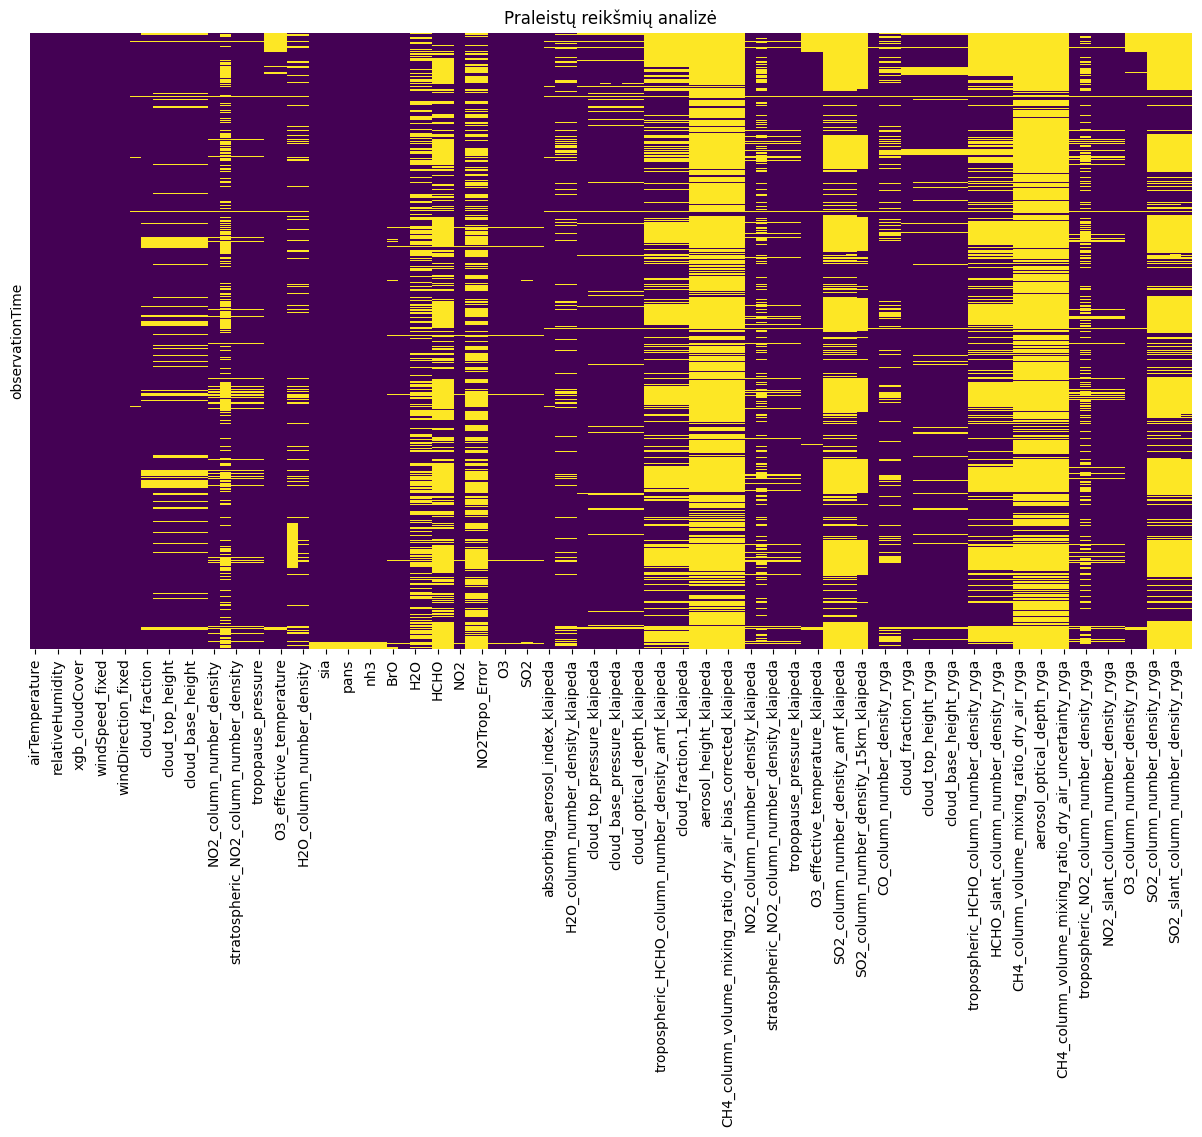

In [807]:
plt.figure(figsize=(15, 8))
sns.heatmap(cut_combined_data.isnull(), yticklabels=False, cbar=False, cmap='viridis')
plt.title('Praleistų reikšmių analizė')
plt.show()

In [818]:
max_gap = {}

for col in cut_combined_data.columns:
    first_idx = cut_combined_data[col].first_valid_index()
    
    if first_idx is not None:
        subset = cut_combined_data.loc[first_idx:, col]
        
        is_nan = subset.isnull()
        groups = (is_nan != is_nan.shift()).cumsum()
        gap_sizes = is_nan.groupby(groups).sum()
    
        max_gap[col] = gap_sizes.max()
    else:
        max_gap[col] = None

max_gap

{'airTemperature': np.int64(0),
 'seaLevelPressure': np.int64(0),
 'relativeHumidity': np.int64(0),
 'xgb_precipitation': np.int64(0),
 'xgb_cloudCover': np.int64(0),
 'feelsLikeTemperature_fixed': np.int64(0),
 'windSpeed_fixed': np.int64(0),
 'windGust_fixed': np.int64(0),
 'windDirection_fixed': np.int64(0),
 'absorbing_aerosol_index': np.int64(2),
 'cloud_fraction': np.int64(32),
 'cloud_top_pressure': np.int64(32),
 'cloud_top_height': np.int64(32),
 'cloud_base_pressure': np.int64(32),
 'cloud_base_height': np.int64(32),
 'cloud_optical_depth': np.int64(32),
 'NO2_column_number_density': np.int64(4),
 'tropospheric_NO2_column_number_density': np.int64(50),
 'stratospheric_NO2_column_number_density': np.int64(4),
 'NO2_slant_column_number_density': np.int64(4),
 'tropopause_pressure': np.int64(4),
 'O3_column_number_density': np.int64(5),
 'O3_effective_temperature': np.int64(5),
 'CO_column_number_density': np.int64(201),
 'H2O_column_number_density': np.int64(5),
 'dust': np.int

In [822]:
data = cut_combined_data.drop(columns=['tropospheric_NO2_column_number_density',
                                                    'H2O', 'H2O_Error', 'HCHO',
                                                    'HCHO_Error', 'NO2Tropo', 'NO2Tropo_Error',
                                                    'SO2_Error', 'SO2',
                                                    'tropospheric_NO2_column_number_density_klaipeda',
                                                    'tropospheric_NO2_column_number_density_ryga',
                                                    'tropospheric_HCHO_column_number_density_klaipeda',
                                                    'tropospheric_HCHO_column_number_density_amf_klaipeda',
                                                    'HCHO_slant_column_number_density_klaipeda',
                                                    'cloud_fraction.1_klaipeda',
                                                    'CH4_column_volume_mixing_ratio_dry_air_klaipeda',
                                                    'aerosol_height_klaipeda',
                                                    'aerosol_optical_depth_klaipeda',
                                                    'CH4_column_volume_mixing_ratio_dry_air_bias_corrected_klaipeda',
                                                    'CH4_column_volume_mixing_ratio_dry_air_uncertainty_klaipeda',
                                                    'tropospheric_NO2_column_number_density_klaipeda',
                                                    'SO2_column_number_density_klaipeda',
                                                    'SO2_column_number_density_amf_klaipeda',
                                                    'SO2_slant_column_number_density_klaipeda',
                                                    'SO2_column_number_density_15km_klaipeda',
                                                    'tropospheric_HCHO_column_number_density_ryga',
                                                    'tropospheric_HCHO_column_number_density_amf_ryga',
                                                    'HCHO_slant_column_number_density_ryga',
                                                    'cloud_fraction.1_ryga',
                                                    'CH4_column_volume_mixing_ratio_dry_air_ryga',
                                                    'aerosol_height_ryga',
                                                    'aerosol_optical_depth_ryga',
                                                    'CH4_column_volume_mixing_ratio_dry_air_bias_corrected_ryga',
                                                    'CH4_column_volume_mixing_ratio_dry_air_uncertainty_ryga',
                                                    'tropospheric_NO2_column_number_density_ryga',
                                                    'SO2_column_number_density_ryga',
                                                    'SO2_column_number_density_amf_ryga',
                                                    'SO2_slant_column_number_density_ryga',
                                                    'SO2_column_number_density_15km_ryga',
                                                    'CO_column_number_density', 
                                                    'CO_column_number_density_klaipeda',
                                                    'cloud_fraction_klaipeda',
                                                    'cloud_top_pressure_klaipeda',
                                                    'cloud_top_height_klaipeda',
                                                    'cloud_base_pressure_klaipeda',
                                                    'cloud_base_height_klaipeda',
                                                    'cloud_optical_depth_klaipeda',
                                                    'O3_column_number_density_klaipeda',
                                                    'O3_effective_temperature_klaipeda',
                                                    'CO_column_number_density_ryga',
                                                    'cloud_fraction_ryga',
                                                    'cloud_top_pressure_ryga',
                                                    'cloud_top_height_ryga',
                                                    'cloud_base_pressure_ryga',
                                                    'cloud_base_height_ryga',
                                                    'cloud_optical_depth_ryga',
                                                    'O3_column_number_density_ryga',
                                                    'O3_effective_temperature_ryga',
                                                    ])


# data = cut_combined_data.drop(columns=['tropospheric_NO2_column_number_density',
#                                                     'H2O', 'H2O_Error', 'HCHO',
#                                                     'HCHO_Error', 'NO2Tropo', 'NO2Tropo_Error',
#                                                     'SO2_Error',
#                                                     'tropospheric_NO2_column_number_density_klaipeda',
#                                                     'tropospheric_NO2_column_number_density_ryga',
#                                                     'tropospheric_HCHO_column_number_density_klaipeda',
#                                                     'tropospheric_HCHO_column_number_density_amf_klaipeda',
#                                                     'HCHO_slant_column_number_density_klaipeda',
#                                                     'cloud_fraction.1_klaipeda',
#                                                     'CH4_column_volume_mixing_ratio_dry_air_klaipeda',
#                                                     'aerosol_height_klaipeda',
#                                                     'aerosol_optical_depth_klaipeda',
#                                                     'CH4_column_volume_mixing_ratio_dry_air_bias_corrected_klaipeda',
#                                                     'CH4_column_volume_mixing_ratio_dry_air_uncertainty_klaipeda',
#                                                     'tropospheric_NO2_column_number_density_klaipeda',
#                                                     'SO2_column_number_density_klaipeda',
#                                                     'SO2_column_number_density_amf_klaipeda',
#                                                     'SO2_slant_column_number_density_klaipeda',
#                                                     'SO2_column_number_density_15km_klaipeda',
#                                                     'tropospheric_HCHO_column_number_density_ryga',
#                                                     'tropospheric_HCHO_column_number_density_amf_ryga',
#                                                     'HCHO_slant_column_number_density_ryga',
#                                                     'cloud_fraction.1_ryga',
#                                                     'CH4_column_volume_mixing_ratio_dry_air_ryga',
#                                                     'aerosol_height_ryga',
#                                                     'aerosol_optical_depth_ryga',
#                                                     'CH4_column_volume_mixing_ratio_dry_air_bias_corrected_ryga',
#                                                     'CH4_column_volume_mixing_ratio_dry_air_uncertainty_ryga',
#                                                     'tropospheric_NO2_column_number_density_ryga',
#                                                     'SO2_column_number_density_ryga',
#                                                     'SO2_column_number_density_amf_ryga',
#                                                     'SO2_slant_column_number_density_ryga',
#                                                     'SO2_column_number_density_15km_ryga'])

In [826]:
(data < 0).sum()

for col in ['NO2_column_number_density', 'BrO', 'NO2_column_number_density_klaipeda', 'NO2_column_number_density_ryga']:
    data.loc[data[col] < 0, col] = np.nan

--- Poros, kurių koreliacija > 0.9 ---
cloud_base_height <---> cloud_top_height: 0.9970
feelsLikeTemperature_fixed <---> airTemperature: 0.9954
cloud_base_pressure <---> cloud_top_pressure: 0.9936
stratospheric_NO2_column_number_density_ryga <---> stratospheric_NO2_column_number_density_klaipeda: 0.9913
stratospheric_NO2_column_number_density_ryga <---> stratospheric_NO2_column_number_density: 0.9892
stratospheric_NO2_column_number_density_klaipeda <---> stratospheric_NO2_column_number_density: 0.9856
cloud_base_pressure <---> cloud_top_height: 0.9852
cloud_base_height <---> cloud_base_pressure: 0.9831
cloud_top_height <---> cloud_top_pressure: 0.9791
cloud_base_height <---> cloud_top_pressure: 0.9688
stratospheric_NO2_column_number_density_klaipeda <---> O3_effective_temperature: 0.9296
stratospheric_NO2_column_number_density_ryga <---> O3_effective_temperature: 0.9290
O3_effective_temperature <---> stratospheric_NO2_column_number_density: 0.9289
stratospheric_NO2_column_number_densit

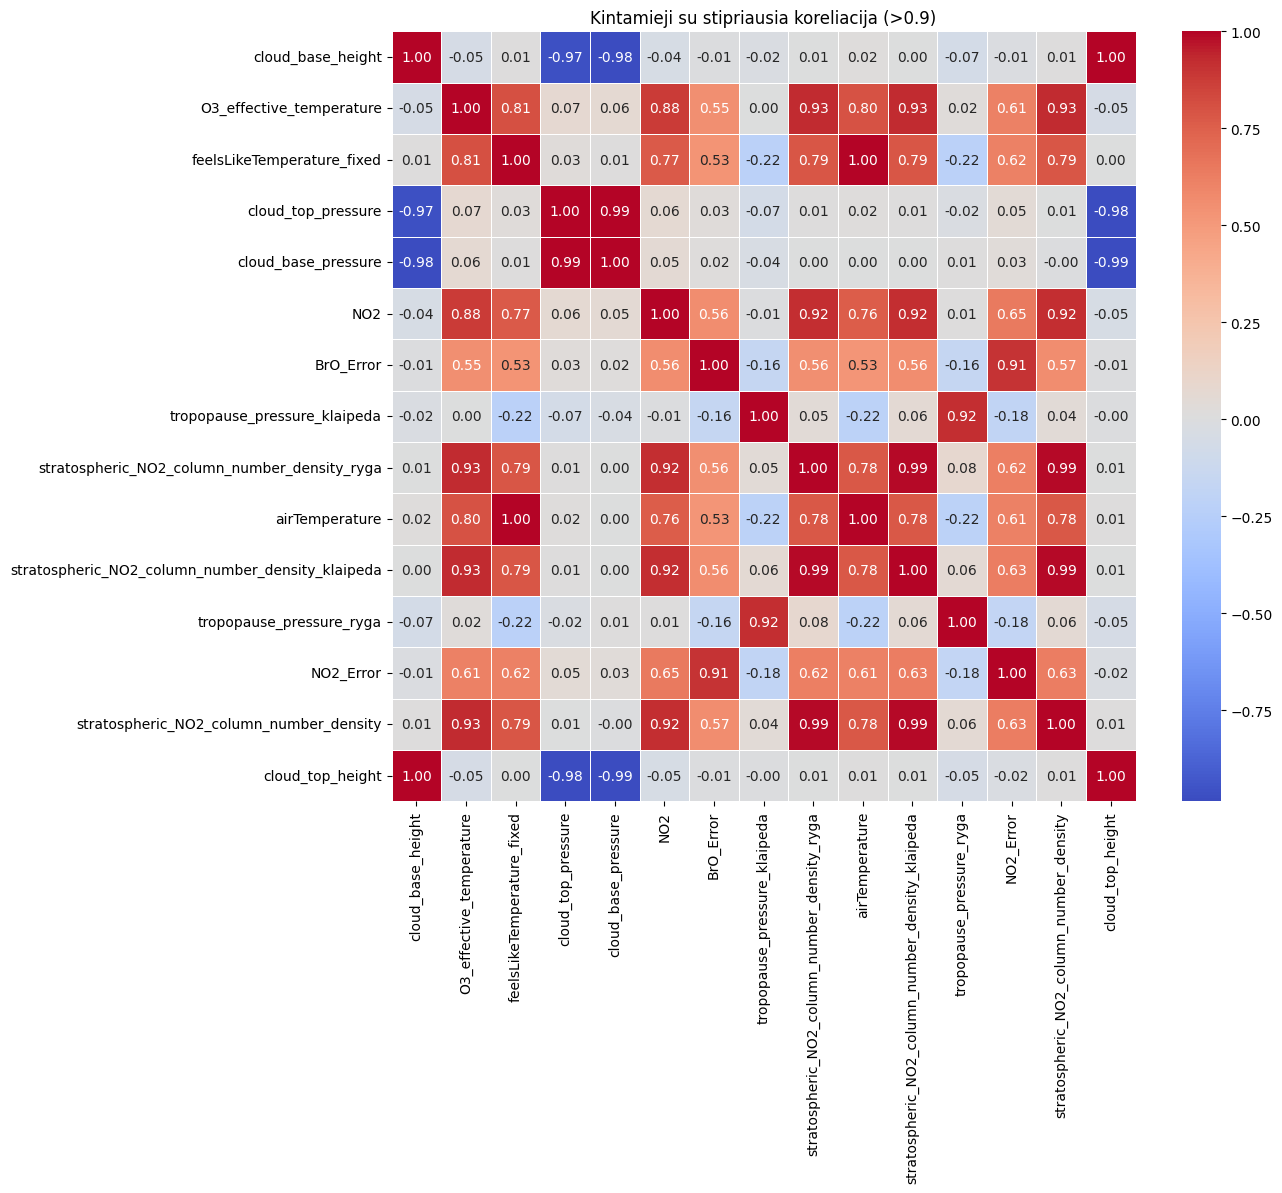

In [828]:
corr_matrix = data.corr().abs()

upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
correlations = upper.unstack().dropna().sort_values(ascending=False)

threshold = 0.9
high_corr = correlations[correlations > threshold]

print(f"--- Poros, kurių koreliacija > {threshold} ---")
if not high_corr.empty:
    for (col1, col2), val in high_corr.items():
        print(f"{col1} <---> {col2}: {val:.4f}")
else:
    print("Tokių porų nerasta.")

high_corr_cols = list(set([col for pair in high_corr.index for col in pair]))

if high_corr_cols:
    plt.figure(figsize=(12, 10))
    sns.heatmap(data[high_corr_cols].corr(), 
                annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
    plt.title(f"Kintamieji su stipriausia koreliacija (>{threshold})")
    plt.show()

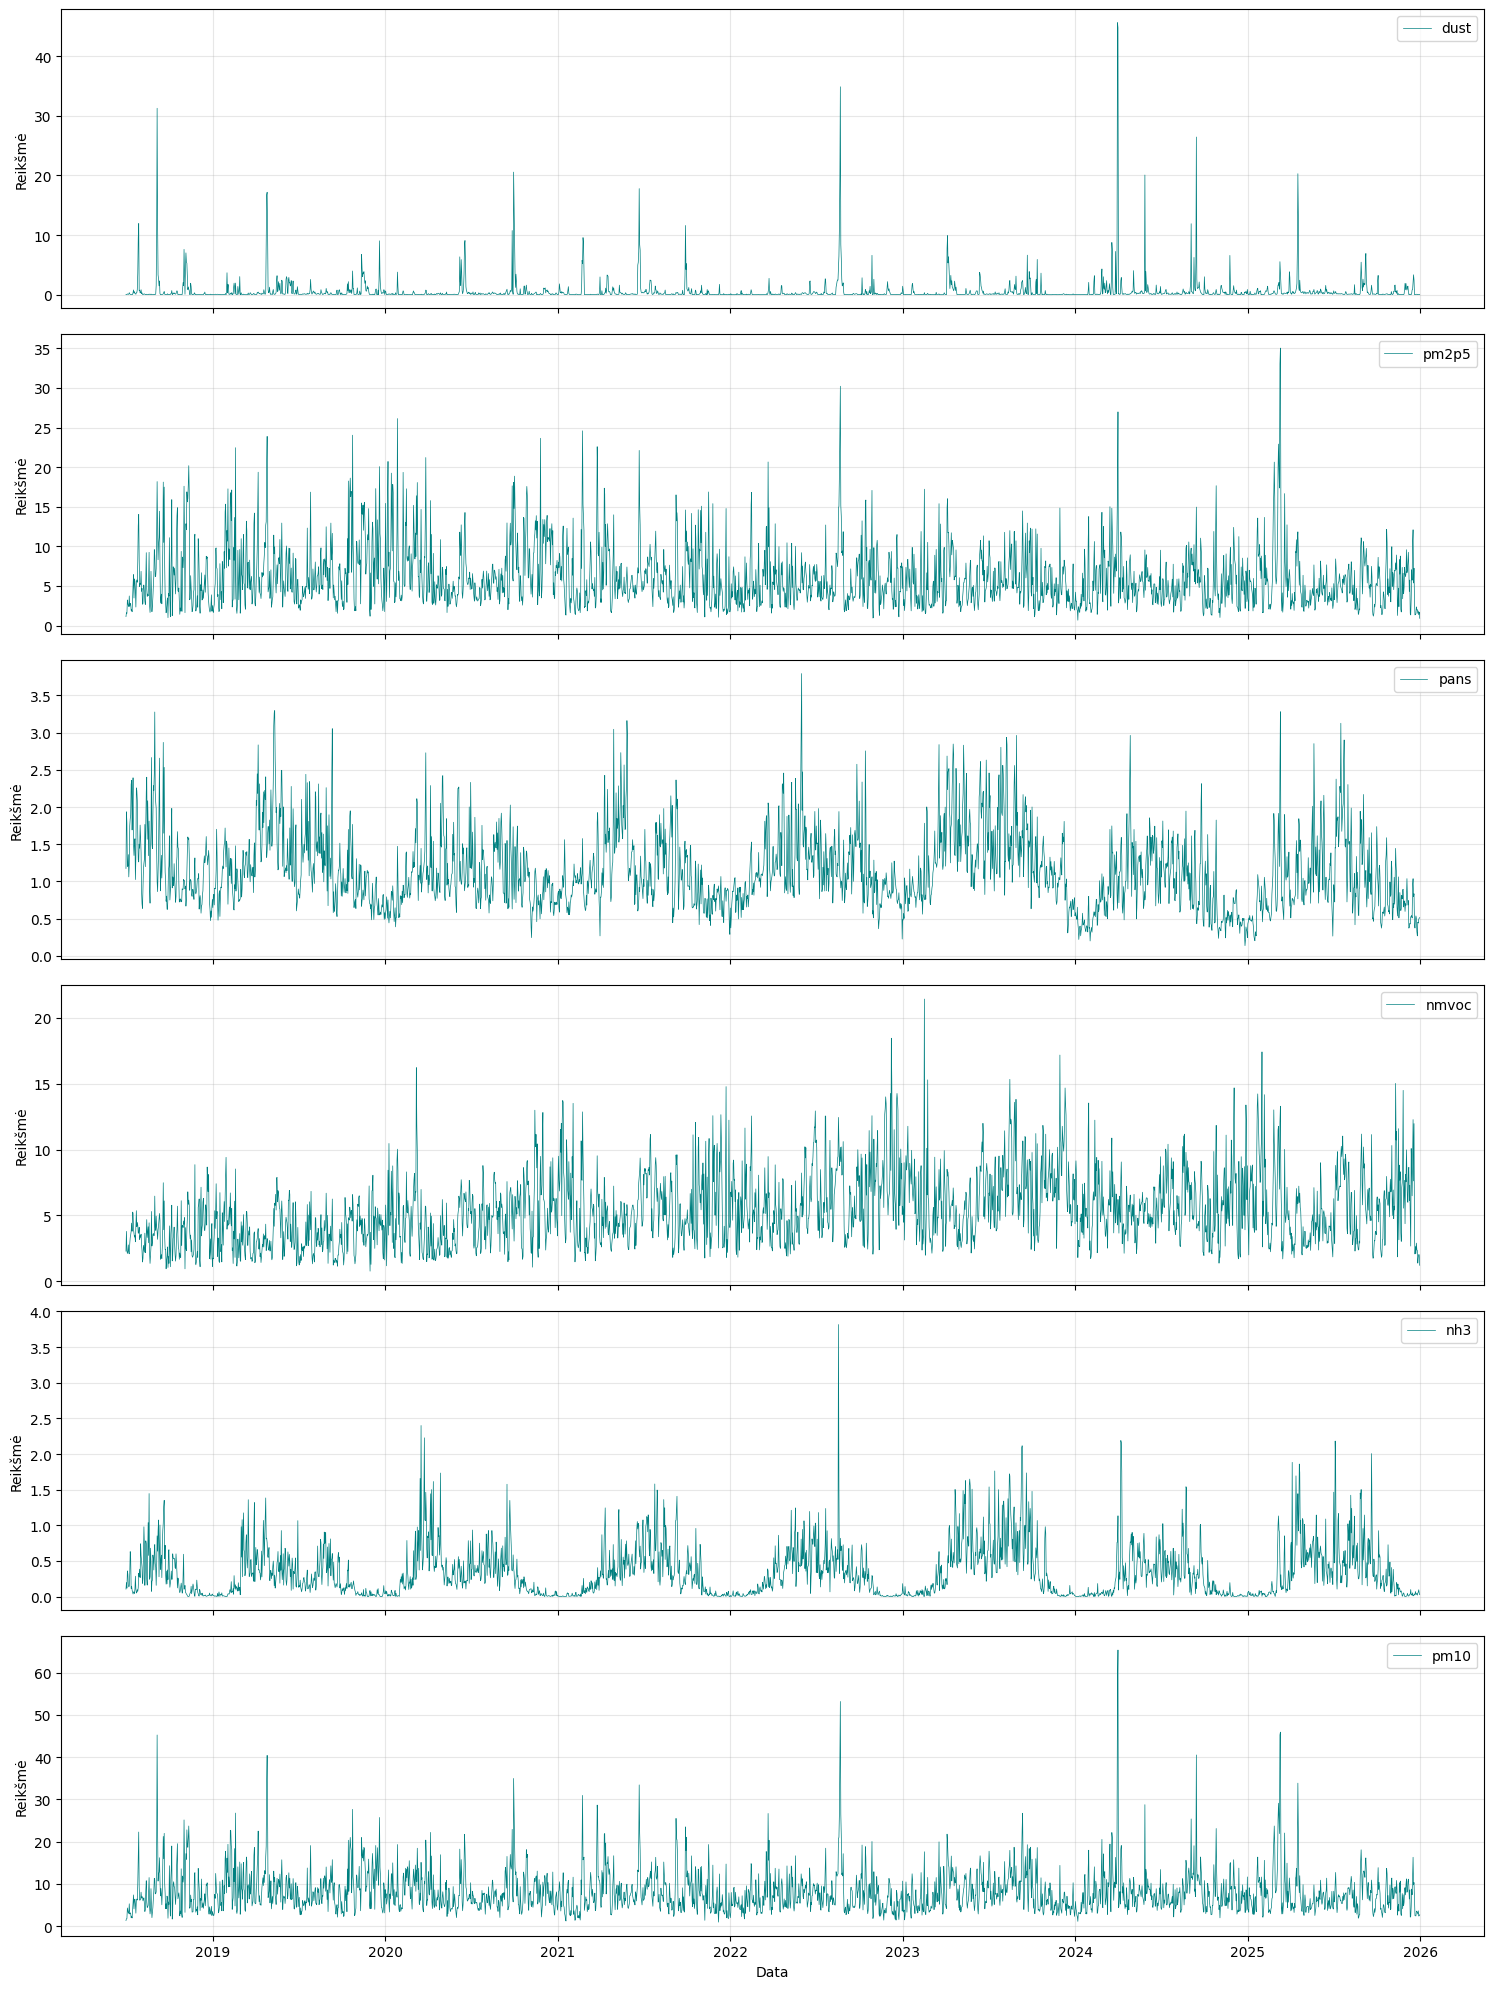

In [829]:
cols_to_show = ['dust', 'pm2p5', 'pans', 'nmvoc', 'nh3', 'pm10']

fig, axes = plt.subplots(len(cols_to_show), 1, figsize=(15, 20), sharex=True)

for i, col in enumerate(cols_to_show):
    axes[i].plot(data.index, data[col], label=col, color='teal', linewidth=0.5)
    axes[i].set_ylabel('Reikšmė')
    axes[i].legend(loc='upper right')
    axes[i].grid(True, alpha=0.3)

plt.xlabel('Data')
plt.tight_layout()
plt.show()

In [830]:
def plot_imputation_results(data_orig, data_filled, variable, method_name="Modelis", start_date=None, end_date=None):
    miss_idx = data_orig[data_orig[variable].isna()].index
    
    if start_date: start_date = pd.to_datetime(start_date)
    if end_date: end_date = pd.to_datetime(end_date)

    if start_date and end_date:
        orig_plot = data_orig.loc[start_date:end_date]
        filled_plot = data_filled.loc[start_date:end_date]
        current_miss_idx = [i for i in miss_idx if start_date <= i <= end_date]
    else:
        orig_plot = data_orig
        filled_plot = data_filled
        current_miss_idx = miss_idx

    plt.figure(figsize=(15, 6))

    plt.plot(filled_plot.index, filled_plot[variable], 
             label=f'{method_name} užpildyta seka', color='orange', linestyle='--', linewidth=1)

    plt.plot(orig_plot.index, orig_plot[variable], 
             label='Originalūs duomenys', color='blue', linewidth=1)
    
    if len(current_miss_idx) > 0:
        plt.scatter(current_miss_idx, filled_plot.loc[current_miss_idx, variable], 
                    color='red', s=15, label=f'{method_name} prognozė', zorder=5)

    plt.title(f'Kintamojo "{variable}" užpildymas ({method_name})')
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

In [831]:
def simple_impute(df, target_col, window=14):
    series = df[target_col].copy()
    
    rolling_mean = series.rolling(window=window, min_periods=1, center=True).mean()
    series = series.fillna(rolling_mean)
    
    series = series.interpolate(method='linear')
    series = series.ffill().bfill()
    
    return series

In [832]:
simple_impute_data = data.copy()

cols_to_fix = [col for col in simple_impute_data.columns if simple_impute_data[col].isna().any()]

for col in cols_to_fix:
    simple_impute_data[col] = simple_impute(simple_impute_data, col)

print("Užpildymas baigtas!")

Užpildymas baigtas!


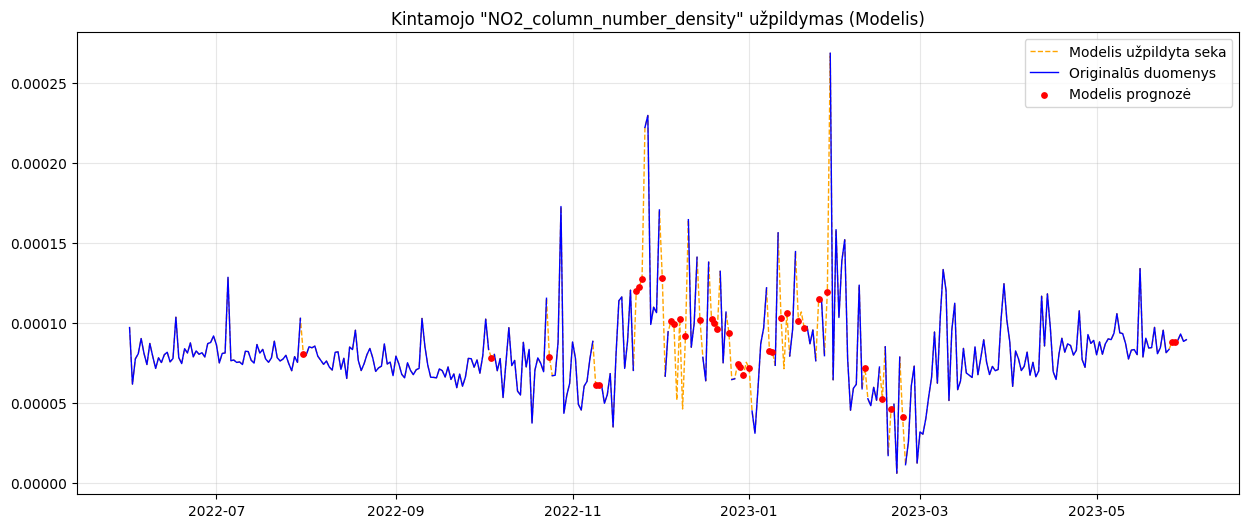

In [833]:
plot_imputation_results(
    data_orig=data, 
    data_filled=simple_impute_data, 
    variable='NO2_column_number_density',
    start_date='2022-06-01',
    end_date='2023-06-01'
)

# Testavimas

In [834]:
data['day_of_year'] = data.index.dayofyear

In [835]:
def block_bootstrapping_testdata(data_column, data_skip = 0.2, p_remove = 0.1, block_size = 12):
    data_array = np.array(data_column, dtype=float).copy()
    N = len(data_array)

    start_from = int(N * data_skip)

    total_to_remove = int((N - start_from) * p_remove)
    blocks_count =  total_to_remove // block_size

    for _ in range(blocks_count):
        start_idx = random.randint(start_from, max(start_from, N - block_size))
        data_array[start_idx : start_idx + block_size] = np.nan
    
    return data_array

In [876]:
random.seed(2026)
np.random.seed(2026)

df_corrupted = data.copy()
masks = {}

for col in df_corrupted.columns:
    if df_corrupted[col].dtype in [np.float64, np.int64]:
        original_col_data = df_corrupted[col].values
        corrupted_col = block_bootstrapping_testdata(original_col_data, data_skip = 0.05,  p_remove=0.1, block_size=30)
        
        masks[col] = np.isnan(corrupted_col) & ~np.isnan(original_col_data)
        df_corrupted[col] = corrupted_col

## MICE + MLP 

In [877]:
print("Pradedamas MICE + MLP užpildymas...")

scaler = StandardScaler()
scaled_data = scaler.fit_transform(df_corrupted)

mlp_reg = MLPRegressor(
    hidden_layer_sizes=(64, 64, 32), 
    activation='relu', 
    solver='adam',
    alpha=0.001,
    max_iter=500, 
    learning_rate_init=0.001,
    early_stopping=True,
    random_state=2026
)

imputer = IterativeImputer(
    estimator=mlp_reg, 
    max_iter=5,
    random_state=2026,
    imputation_order='descending',
    verbose=2
)

imputed_data_scaled = imputer.fit_transform(scaled_data)
imputed_data_unscaled = scaler.inverse_transform(imputed_data_scaled)
imputed_df = pd.DataFrame(
    imputed_data_unscaled, 
    columns=data.columns, 
    index=data.index
)

Pradedamas MICE + MLP užpildymas...
[IterativeImputer] Completing matrix with shape (2772, 49)
[IterativeImputer] Ending imputation round 1/5, elapsed time 235.89
[IterativeImputer] Change: 24.14543889971022, scaled tolerance: 0.0243212166818693 
[IterativeImputer] Ending imputation round 2/5, elapsed time 465.92
[IterativeImputer] Change: 10.09999060213988, scaled tolerance: 0.0243212166818693 
[IterativeImputer] Ending imputation round 3/5, elapsed time 713.28
[IterativeImputer] Change: 6.987375272946107, scaled tolerance: 0.0243212166818693 
[IterativeImputer] Ending imputation round 4/5, elapsed time 942.41
[IterativeImputer] Change: 7.431500017054474, scaled tolerance: 0.0243212166818693 
[IterativeImputer] Ending imputation round 5/5, elapsed time 1161.41
[IterativeImputer] Change: 7.868241551977871, scaled tolerance: 0.0243212166818693 


c:\Users\rugil\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\impute\_iterative.py:895: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


In [878]:
target_columns = ['absorbing_aerosol_index',
                  'NO2_column_number_density',
                  'stratospheric_NO2_column_number_density',
                  'NO2_slant_column_number_density',
                  'tropopause_pressure',
                  'H2O_column_number_density',
                  'BrO', 'BrO_Error',
                  'NO2', 'NO2_Error',
                  'O3', 'O3_Error']

print("\n--- TESTAVIMO REZULTATAI ---")
metrics_list = []

for col in masks.keys():
    if col in target_columns and masks[col].any():
        y_true = data.loc[masks[col], col]
        y_pred = imputed_df.loc[masks[col], col]
        
        rmse = np.sqrt(mean_squared_error(y_true, y_pred))
        mae = mean_absolute_error(y_true, y_pred)
        r2 = r2_score(y_true, y_pred)
        
        metrics_list.append({
            'Stulpelis': col,
            'R2 Score': round(r2, 4)
        })

results_table = pd.DataFrame(metrics_list)

if not results_table.empty:
    summary_data = [
        {
            'Stulpelis': 'VIDURKIS',
            'R2 Score': round(results_table['R2 Score'].mean(), 4)
        },
        {
            'Stulpelis': 'MEDIANA',
            'R2 Score': round(results_table['R2 Score'].median(), 4)
        }
    ]
    results_table = pd.concat([results_table, pd.DataFrame(summary_data)], ignore_index=True)

print(results_table.to_string(index=False))



--- TESTAVIMO REZULTATAI ---
                              Stulpelis  R2 Score
                absorbing_aerosol_index    0.6836
              NO2_column_number_density    0.4633
stratospheric_NO2_column_number_density    0.9688
        NO2_slant_column_number_density    0.6574
                    tropopause_pressure    0.7556
              H2O_column_number_density    0.7543
                                    BrO    0.3426
                              BrO_Error    0.7612
                                    NO2    0.8995
                              NO2_Error    0.8613
                                     O3    0.7357
                               O3_Error    0.4391
                               VIDURKIS    0.6935
                                MEDIANA    0.7450


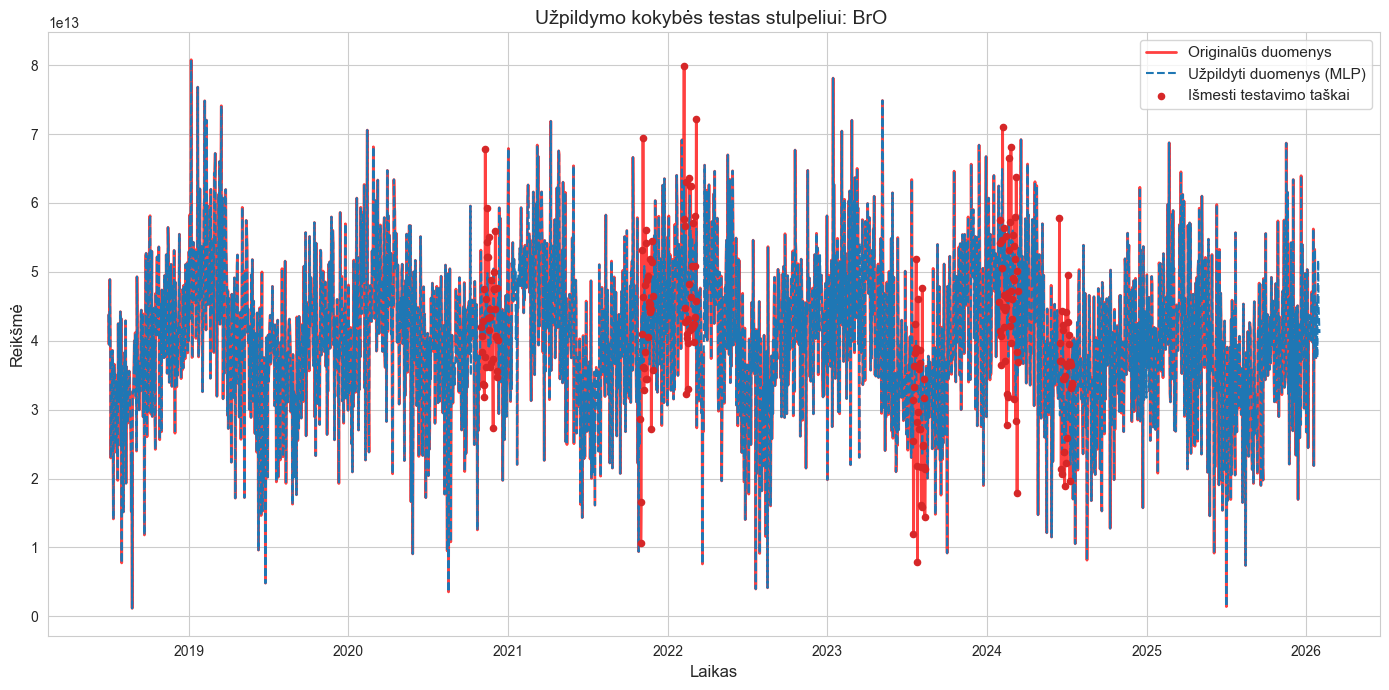

In [879]:
def plot_test_imputation(df_original, df_imputed, mask, col_name, start_date=None, end_date=None, title_suffix=""):
    """
    Nubraižo originalias, užpildytas ir testavimo metu išmestas reikšmes.
    Tikisi, kad DataFrame turi laiko indeksą.
    """
    plot_orig = df_original[col_name].copy()
    plot_imputed = df_imputed[col_name].copy()
    
    test_points = plot_orig.copy()
    test_points[~mask] = np.nan
    
    if start_date and end_date:
        plot_orig = plot_orig.loc[start_date:end_date]
        plot_imputed = plot_imputed.loc[start_date:end_date]
        test_points = test_points.loc[start_date:end_date]

    plt.figure(figsize=(14, 7))
    sns.set_style("whitegrid")

    plt.plot(plot_orig.index, plot_orig, label='Originalūs duomenys', color='red', alpha = 0.75, linewidth=2)

    plt.plot(plot_imputed.index, plot_imputed, label='Užpildyti duomenys (MLP)', color='#1f77b4', linestyle='--', linewidth=1.5)

    if not test_points.isna().all():
        plt.scatter(test_points.index, test_points, color='#d62728', label='Išmesti testavimo taškai', s=20, zorder=5)

    plt.title(f'Užpildymo kokybės testas stulpeliui: {col_name} {title_suffix}', fontsize=14)
    plt.ylabel('Reikšmė', fontsize=12)
    plt.xlabel('Laikas', fontsize=12)
    plt.legend(loc='best', fontsize=11)
    
    plt.tight_layout()
    plt.show()


column_to_plot = 'BrO'
mask_for_plot = masks[column_to_plot]

plot_test_imputation(data, imputed_df, mask_for_plot, column_to_plot)


## Bazinis modelis

In [880]:
simple_test_results = []
simple_imputed_df = pd.DataFrame(index=data.index)

print("Pradedamas paprastas užpildymas testavimui...")

for col in data.columns:
    simple_imputed_series = simple_impute(df_corrupted, col)
    simple_imputed_df[col] = simple_imputed_series
    
    if col in target_columns and col in masks and masks[col].any():
        y_true = data.loc[masks[col], col]
        y_pred = simple_imputed_series.loc[masks[col]]
        
        rmse = np.sqrt(mean_squared_error(y_true, y_pred))
        mae = mean_absolute_error(y_true, y_pred)
        r2 = r2_score(y_true, y_pred)
        
        simple_test_results.append({
            'Stulpelis': col,
            'R2 Score': round(r2, 4)
        })

simple_results_table = pd.DataFrame(simple_test_results)


if not simple_results_table.empty:
    avg_row = pd.DataFrame([{
        'Stulpelis': 'VIDURKIS (Simple)',
        'R2 Score': round(simple_results_table['R2 Score'].mean(), 4)
    }])

    summary_data = [
        {
            'Stulpelis': 'VIDURKIS',
            'R2 Score': round(simple_results_table['R2 Score'].mean(), 4)
        },
        {
            'Stulpelis': 'MEDIANA',
            'R2 Score': round(simple_results_table['R2 Score'].median(), 4)
        }
    ]
    simple_results_table = pd.concat([simple_results_table, pd.DataFrame(summary_data)], ignore_index=True)

print("\n--- SIMPLE IMPUTE REZULTATAI ---")
print(simple_results_table.to_string(index=False))

Pradedamas paprastas užpildymas testavimui...

--- SIMPLE IMPUTE REZULTATAI ---
                              Stulpelis  R2 Score
                absorbing_aerosol_index    0.4590
              NO2_column_number_density   -0.4307
stratospheric_NO2_column_number_density    0.8943
        NO2_slant_column_number_density   -0.2250
                    tropopause_pressure   -0.6343
              H2O_column_number_density    0.2394
                                    BrO   -0.1309
                              BrO_Error    0.1696
                                    NO2    0.8664
                              NO2_Error    0.1745
                                     O3    0.3330
                               O3_Error    0.5308
                               VIDURKIS    0.1872
                                MEDIANA    0.2070


## MICE + RF

In [881]:
print("Pradedamas MICE + Random Forest užpildymas...")

scaler_rf = StandardScaler()
rf_data_scaled = scaler_rf.fit_transform(df_corrupted)

rf_reg = RandomForestRegressor(
    n_estimators=50,
    # max_features='sqrt',
    max_depth=15,
    n_jobs=-1, 
    random_state=2026
)

imputer_rf = IterativeImputer(
    estimator=rf_reg, 
    max_iter=5, 
    initial_strategy='median',
    imputation_order='ascending',
    random_state=2026,
    verbose=2
)

imputed_data_rf = imputer_rf.fit_transform(rf_data_scaled)

imputed_data_rf = scaler_rf.inverse_transform(imputed_data_rf)
imputed_df_rf = pd.DataFrame(
    imputed_data_rf, 
    columns=data.columns, 
    index=data.index
)


Pradedamas MICE + Random Forest užpildymas...
[IterativeImputer] Completing matrix with shape (2772, 49)
[IterativeImputer] Ending imputation round 1/5, elapsed time 45.45
[IterativeImputer] Change: 18.15539980810127, scaled tolerance: 0.0243212166818693 
[IterativeImputer] Ending imputation round 2/5, elapsed time 91.60
[IterativeImputer] Change: 4.776611502515199, scaled tolerance: 0.0243212166818693 
[IterativeImputer] Ending imputation round 3/5, elapsed time 137.86
[IterativeImputer] Change: 5.552859193185485, scaled tolerance: 0.0243212166818693 
[IterativeImputer] Ending imputation round 4/5, elapsed time 187.31
[IterativeImputer] Change: 3.9939467181646147, scaled tolerance: 0.0243212166818693 
[IterativeImputer] Ending imputation round 5/5, elapsed time 241.10
[IterativeImputer] Change: 3.9172326190727413, scaled tolerance: 0.0243212166818693 


c:\Users\rugil\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\impute\_iterative.py:895: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


In [882]:
rf_metrics_list = []

for col in masks.keys():
    if col in target_columns and masks[col].any():
        y_true = data.loc[masks[col], col]
        y_pred = imputed_df_rf.loc[masks[col], col]
        
        rmse = np.sqrt(mean_squared_error(y_true, y_pred))
        mae = mean_absolute_error(y_true, y_pred)
        r2 = r2_score(y_true, y_pred)
        
        rf_metrics_list.append({
            'Stulpelis': col,
            'R2 Score': round(r2, 4)
        })

results_table_rf = pd.DataFrame(rf_metrics_list)
if not results_table_rf.empty:
    summary_data = [
        {
            'Stulpelis': 'VIDURKIS',
            'R2 Score': round(results_table_rf['R2 Score'].mean(), 4)
        },
        {
            'Stulpelis': 'MEDIANA',
            'R2 Score': round(results_table_rf['R2 Score'].median(), 4)
        }
    ]
    results_table_rf = pd.concat([results_table_rf, pd.DataFrame(summary_data)], ignore_index=True)

print("\n--- RANDOM FOREST REZULTATAI ---")
print(results_table_rf.to_string(index=False))


--- RANDOM FOREST REZULTATAI ---
                              Stulpelis  R2 Score
                absorbing_aerosol_index    0.7481
              NO2_column_number_density    0.3996
stratospheric_NO2_column_number_density    0.9817
        NO2_slant_column_number_density    0.6057
                    tropopause_pressure    0.7533
              H2O_column_number_density    0.8208
                                    BrO    0.3199
                              BrO_Error    0.7770
                                    NO2    0.9254
                              NO2_Error    0.8616
                                     O3    0.7410
                               O3_Error    0.6483
                               VIDURKIS    0.7152
                                MEDIANA    0.7507


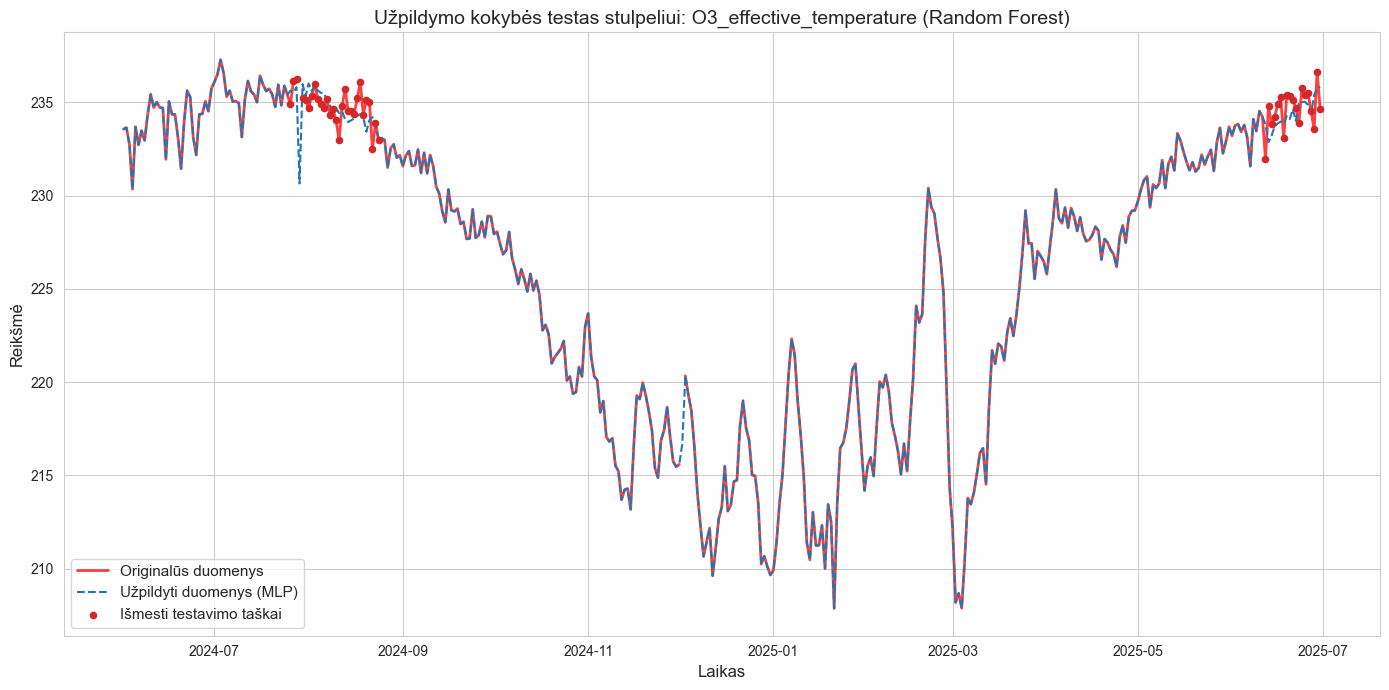

In [883]:
plot_test_imputation(
    df_original=data, 
    df_imputed=imputed_df_rf, 
    mask=masks['O3_effective_temperature'], 
    col_name='O3_effective_temperature', 
    start_date='2024-06-01', 
    end_date='2025-06-30',
    title_suffix="(Random Forest)"
)

## Klasikinis MICE

In [884]:
print("Pradedamas numatytasis MICE užpildymas...")

scaler = StandardScaler()
scaled_corrupted = scaler.fit_transform(df_corrupted)

default_imputer = IterativeImputer(
    max_iter=10, 
    random_state=2026, 
    verbose=0
)

imputed_data_raw = default_imputer.fit_transform(scaled_corrupted)

imputed_df_default = pd.DataFrame(
    scaler.inverse_transform(imputed_data_raw), 
    columns=data.columns, 
    index=data.index
)

Pradedamas numatytasis MICE užpildymas...


c:\Users\rugil\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\impute\_iterative.py:895: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


In [885]:
metrics_list = []

for col in masks.keys():
    if col in target_columns and masks[col].any():
        y_true = data.loc[masks[col], col]
        y_pred = imputed_df_default.loc[masks[col], col]
        
        rmse = np.sqrt(mean_squared_error(y_true, y_pred))
        mae = mean_absolute_error(y_true, y_pred)
        r2 = r2_score(y_true, y_pred)
        
        metrics_list.append({
            'Stulpelis': col,
            'R2 Score': round(r2, 4)
        })

results_table = pd.DataFrame(metrics_list)

if not results_table.empty:
    summary_data = [
        {
            'Stulpelis': 'VIDURKIS',
            'R2 Score': round(results_table['R2 Score'].mean(), 4)
        },
        {
            'Stulpelis': 'MEDIANA',
            'R2 Score': round(results_table['R2 Score'].median(), 4)
        }
    ]

    results_table = pd.concat([results_table, pd.DataFrame(summary_data)], ignore_index=True)

print("\n--- NUMATYTOJO MICE REZULTATAI ---")
print(results_table.to_string(index=False))


--- NUMATYTOJO MICE REZULTATAI ---
                              Stulpelis  R2 Score
                absorbing_aerosol_index    0.7215
              NO2_column_number_density    0.4454
stratospheric_NO2_column_number_density    0.9812
        NO2_slant_column_number_density    0.6664
                    tropopause_pressure    0.7896
              H2O_column_number_density    0.7982
                                    BrO    0.3546
                              BrO_Error    0.7549
                                    NO2    0.9133
                              NO2_Error    0.8220
                                     O3    0.7554
                               O3_Error    0.3617
                               VIDURKIS    0.6970
                                MEDIANA    0.7552


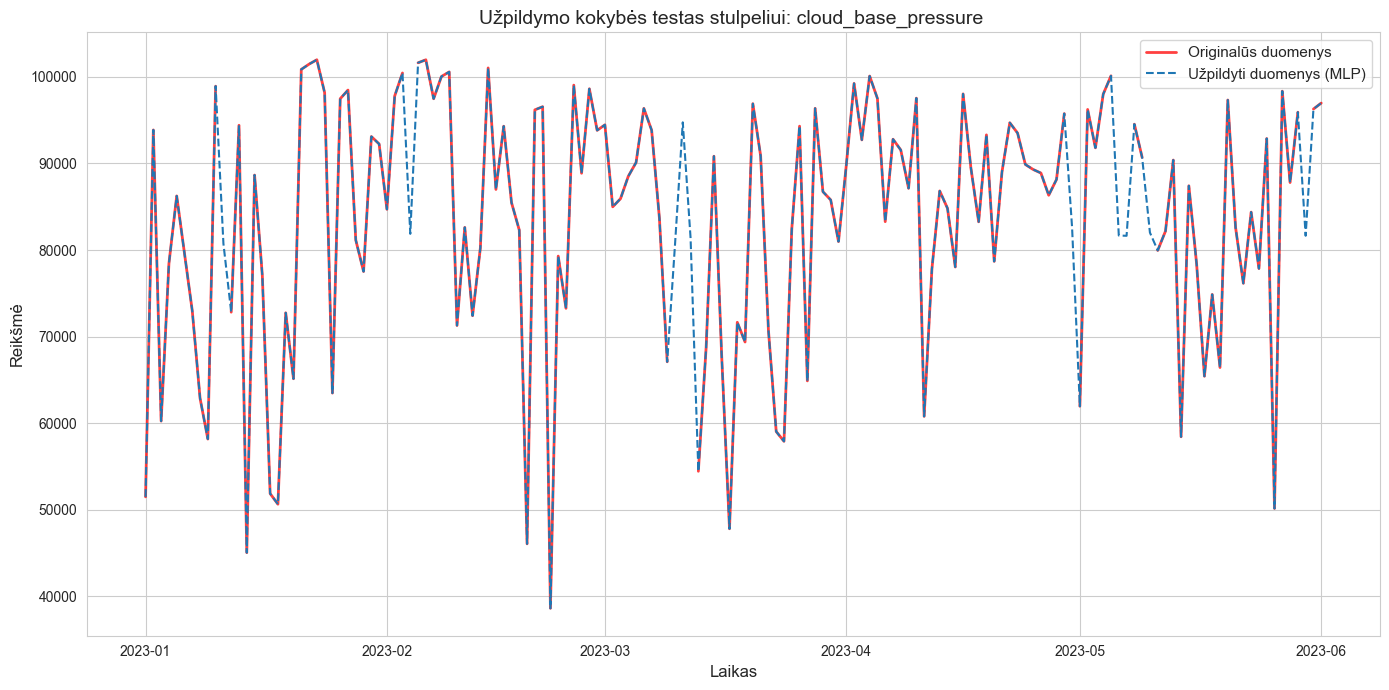

In [886]:
plot_test_imputation(data, 
                     imputed_df_default, 
                     masks['cloud_base_pressure'], 
                     'cloud_base_pressure',
                     start_date='2023-01-01',
                     end_date='2023-06-01')

## Palyginimas

In [887]:
width_inch = 17 / 2.54
height_inch = width_inch * 0.5

def plot_all_methods_comparison(df_original, methods_dict, mask, col_name, start_date=None, end_date=None):
    """
    Nubraižo originalius duomenis ir visų metodų prognozes viename grafike.
    Pritaikyta situacijai, kai mask yra NumPy masyvas.
    """
    if isinstance(mask, np.ndarray):
        mask = pd.Series(mask, index=df_original.index)

    plt.figure(figsize=(width_inch, height_inch))

    if start_date and end_date:
        start_ts = pd.to_datetime(start_date)
        end_ts = pd.to_datetime(end_date)
        
        mask_time = (df_original.index >= start_ts) & (df_original.index <= end_ts)
        plot_df_orig = df_original.loc[mask_time]
        plot_mask = mask.loc[mask_time]
    else:
        plot_df_orig = df_original
        plot_mask = mask

    is_mask = plot_mask.values
    diff = np.diff(is_mask.astype(int), prepend=0, append=0)
    starts = np.where(diff == 1)[0]
    ends = np.where(diff == -1)[0]

    for i in range(len(starts)):
        start_idx = plot_df_orig.index[starts[i]]
        end_idx = plot_df_orig.index[min(ends[i], len(plot_df_orig)-1)]
        
        plt.axvspan(start_idx, end_idx, color='gray', alpha=0.2, label='Dirbtinis blokas' if i == 0 else "")

    plt.plot(plot_df_orig.index, plot_df_orig[col_name], 
             label='Originalūs duomenys', color='red', linewidth=0.7)


    test_points = plot_df_orig[col_name].copy()
    test_points[~plot_mask] = np.nan
    
    if not test_points.isna().all():
        plt.scatter(test_points.index, test_points, color='red', 
                    label='Išmesti taškai', s=3)

    colors = ['#ff7f0e', "#1ca0ff", '#2ca02c', "#e02ef4"]
    for (name, df_imp), color in zip(methods_dict.items(), colors):
        plot_data = df_imp.loc[plot_df_orig.index, col_name]
        plt.plot(plot_df_orig.index, plot_data, label=f'{name}', 
                 color=color, linestyle='--', linewidth=0.7)

    # plt.suptitle(f'Metodų palyginimas {col_name}', fontsize=11)
    plt.ylabel('Reikšmė', fontsize=8)
    plt.xlabel('Laikas', fontsize=8)
    plt.tick_params(axis='both', which='major', labelsize=8)
    plt.legend(fontsize=6, labelspacing=0.4, handletextpad=0.6)
    plt.tight_layout()
    plt.grid(True, alpha=0.3)


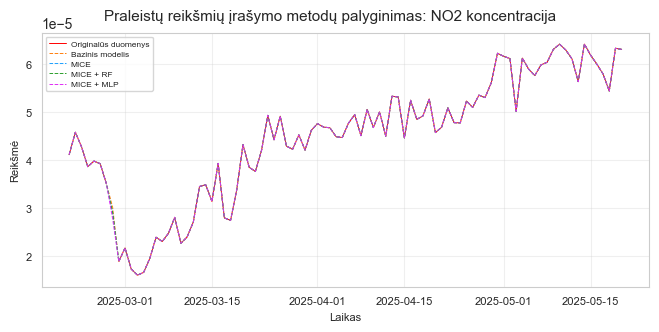

In [892]:
all_methods = {
    'Bazinis modelis': simple_imputed_df,
    'MICE': imputed_df_default,
    'MICE + RF': imputed_df_rf,
    'MICE + MLP': imputed_df,
}

column_to_plot = 'stratospheric_NO2_column_number_density' 

plot_all_methods_comparison(
    data, 
    all_methods, 
    masks[column_to_plot], 
    column_to_plot, 
    start_date='2025-02-20',
    end_date='2025-05-20'
)

plt.suptitle('Praleistų reikšmių įrašymo metodų palyginimas: NO2 koncentracija', fontsize=11)
plt.savefig('metodu_palyginimas.png', dpi=300, bbox_inches='tight')
plt.show()



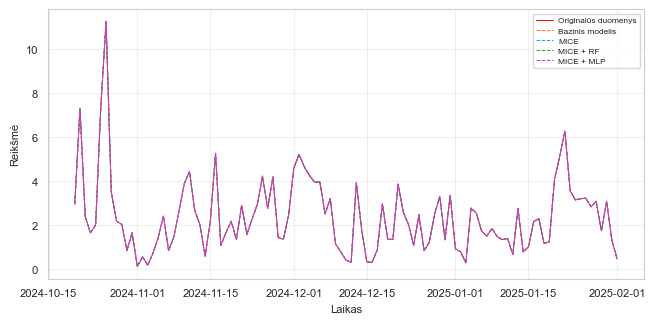

In [889]:
column_to_plot = 'sia' 

plot_all_methods_comparison(
    data, 
    all_methods, 
    masks[column_to_plot], 
    column_to_plot, 
    start_date='2024-10-20',
    end_date='2025-02-01'
)

# Galutinis įrašymas

In [893]:
scaler_rf = StandardScaler()
rf_data_scaled = scaler_rf.fit_transform(data)

rf_reg = RandomForestRegressor(
    n_estimators=50,
    max_depth=15, 
    n_jobs=-1,
    random_state=2026
)

imputer_rf = IterativeImputer(
    estimator=rf_reg, 
    max_iter=5,
    initial_strategy='median',
    imputation_order='ascending',
    random_state=2026,
    verbose=2
)


imputed_data= imputer_rf.fit_transform(rf_data_scaled)

imputed_data_final = scaler_rf.inverse_transform(imputed_data)
filled_data = pd.DataFrame(
    imputed_data_final, 
    columns=df_corrupted.columns, 
    index=df_corrupted.index
)


# print("Pradedamas numatytasis MICE užpildymas...")

# scaler = StandardScaler()
# scaled_corrupted = scaler.fit_transform(data)

# default_imputer = IterativeImputer(
#     max_iter=10, 
#     random_state=2026, 
#     verbose=0
# )

# imputed_data = default_imputer.fit_transform(scaled_corrupted)

# filled_data = pd.DataFrame(
#     scaler.inverse_transform(imputed_data), 
#     columns=data.columns, 
#     index=data.index
# )

[IterativeImputer] Completing matrix with shape (2772, 49)
[IterativeImputer] Ending imputation round 1/5, elapsed time 51.57
[IterativeImputer] Change: 15.201239699938716, scaled tolerance: 0.024120095655993525 
[IterativeImputer] Ending imputation round 2/5, elapsed time 102.71
[IterativeImputer] Change: 7.1397905740829, scaled tolerance: 0.024120095655993525 
[IterativeImputer] Ending imputation round 3/5, elapsed time 154.22
[IterativeImputer] Change: 5.237401806136889, scaled tolerance: 0.024120095655993525 
[IterativeImputer] Ending imputation round 4/5, elapsed time 206.54
[IterativeImputer] Change: 3.989727939675105, scaled tolerance: 0.024120095655993525 
[IterativeImputer] Ending imputation round 5/5, elapsed time 260.78
[IterativeImputer] Change: 3.2065333327729544, scaled tolerance: 0.024120095655993525 


c:\Users\rugil\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\impute\_iterative.py:895: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


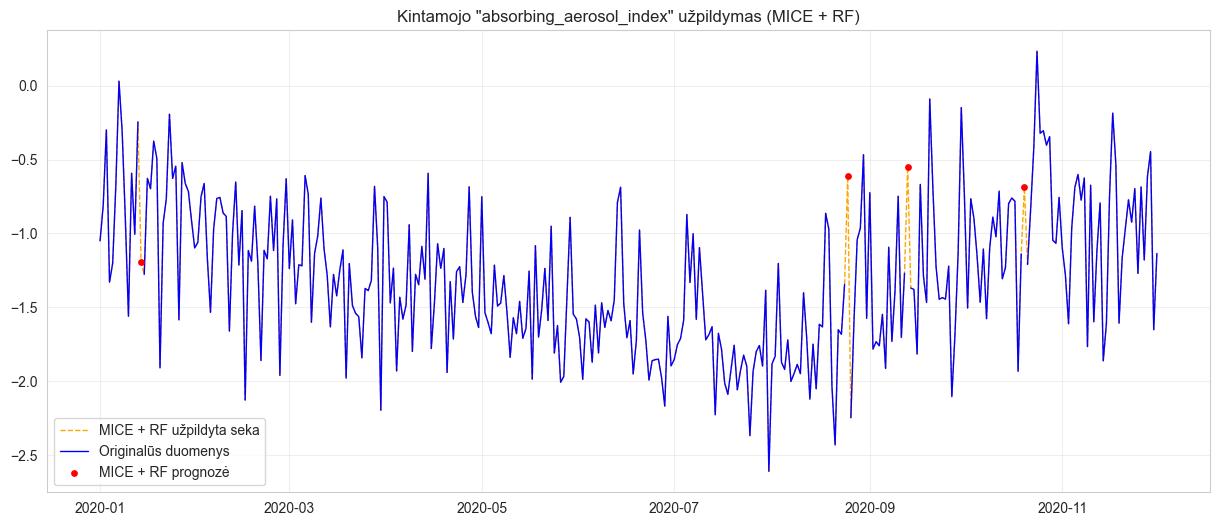

In [894]:
plot_imputation_results(data, 
                        filled_data, 
                        'absorbing_aerosol_index' , 
                        method_name="MICE + RF", 
                        start_date='2020-01-01', 
                        end_date='2020-12-01'
                        )

Galutinis rinkinys

In [899]:
data_to_forecast = data[['dust', 'sia', 'pm2p5', 'pans', 'nmvoc', 'nh3', 'pm10']]


In [900]:
data_for_forecast = filled_data[[
    'seaLevelPressure',
    'relativeHumidity',
    'xgb_precipitation',
    'xgb_cloudCover',
    'feelsLikeTemperature_fixed',
    'windSpeed_fixed',
    'windGust_fixed',
    'windDirection_fixed',
    'absorbing_aerosol_index', 
    'NO2_column_number_density', 
    'stratospheric_NO2_column_number_density',
    'NO2_slant_column_number_density',
    'tropopause_pressure',
    'H2O_column_number_density',
    'BrO',
    'NO2',
    'O3',
    ]]

In [897]:
data_for_forecasting = data_for_forecast.join(data_to_forecast)
data_for_forecasting

,seaLevelPressure,relativeHumidity,xgb_precipitation,xgb_cloudCover,feelsLikeTemperature_fixed,windSpeed_fixed,windGust_fixed,windDirection_fixed,absorbing_aerosol_index,NO2_column_number_density,...,BrO,NO2,O3,dust,sia,pm2p5,pans,nmvoc,nh3,pm10
observationTime,,,,,,,,,,,,,,,,,,,,,
2018-07-01,1010.637500,72.791667,9.100000e+00,89.375000,10.933333,3.762500,13.9,356.0,-0.959856,0.000075,...,4.376100e+13,3.627587e+15,332.670633,0.011452,0.412340,1.127883,1.174715,2.292138,0.105974,1.338105
2018-07-02,1006.662500,94.000000,1.190000e+01,91.500000,10.429167,2.516667,7.0,327.0,-0.807306,0.000079,...,3.946727e+13,3.795988e+15,339.679410,0.011515,0.946260,1.609913,1.935448,3.792921,0.198428,1.752331
2018-07-03,1008.454167,90.041667,1.000000e+01,89.375000,13.387500,2.537500,8.3,271.0,-0.621235,0.000077,...,4.465846e+13,4.526218e+15,361.533268,0.044194,0.676988,1.534471,1.787800,2.332084,0.118859,1.789138
2018-07-04,1009.237500,88.291667,1.390000e+01,88.333333,13.591667,2.358333,8.7,288.0,-0.659180,0.000072,...,4.888972e+13,4.149200e+15,343.308865,0.128728,0.833161,3.229130,1.201320,2.113538,0.361157,4.323638
2018-07-05,1008.079167,70.208333,2.220446e-16,66.000000,16.291667,1.283333,6.1,293.0,-1.010234,0.000079,...,4.093649e+13,3.959891e+15,311.500626,0.097650,0.737482,2.768797,1.206750,2.267631,0.316533,3.718909
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-01-27,1005.416667,95.625000,3.800000e+00,100.000000,-4.162500,1.600000,4.6,70.0,-0.386410,0.000079,...,4.662175e+13,1.580704e+15,395.745543,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-01-28,1002.875000,91.916667,6.000000e+00,100.000000,-8.941667,2.495833,7.5,33.0,-0.301222,0.000113,...,5.205729e+13,2.127232e+15,450.404488,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-01-29,1009.787500,87.000000,2.220446e-16,81.291667,-14.795833,2.812500,8.3,35.0,-0.406181,0.000060,...,4.394930e+13,1.917223e+15,353.699717,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# Prognozavimas

## Gradient Boosting Regressor

In [521]:
data_for_forecasting['day_of_year'] = data_for_forecasting.index.dayofyear
data_for_forecasting['month'] = data_for_forecasting.index.month

In [511]:
forecasting = data_for_forecasting.copy()

test_cutoff = '2025-12-01'
others = ['dust', 'sia', 'pm2p5', 'pans', 'nmvoc', 'nh3', 'pm10']
target = 'dust'

forecasting['dust_lag_30'] = forecasting['dust'].shift(30)
# # forecasting['pm10_weekly_trend'] = forecasting['pm10'].shift(30).rolling(window=7).mean()
# forecasting.dropna(inplace=True)

# for col in others:
#     forecasting[f'{col}_lag_30'] = forecasting[col].shift(30)
forecasting.dropna(inplace=True)

train_data = forecasting[forecasting.index < test_cutoff]
test_data = forecasting[(forecasting.index >= test_cutoff) &
                                 (forecasting[target].notna())]

In [512]:
cols_to_drop = [target] + others

X_train = train_data.drop(columns=cols_to_drop)
y_train = train_data[target]

X_test = test_data.drop(columns=cols_to_drop)
y_test = test_data[target]

In [513]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import TimeSeriesSplit
tscv = TimeSeriesSplit(n_splits=3)

param_dist = {
    'n_estimators': [100, 300, 500, 1000],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'max_depth': [3, 4, 5, 6],
    'min_samples_split': [2, 5, 10],
    'subsample': [0.7, 0.8, 0.9, 1.0]
}

gbr = GradientBoostingRegressor(random_state=2026)

random_search = RandomizedSearchCV(
    estimator=gbr, 
    param_distributions=param_dist, 
    n_iter=20, 
    cv=tscv , 
    scoring='r2', 
    verbose=1, 
    n_jobs=-1
)

random_search.fit(X_train, y_train)

print(f"Geriausi parametrai: {random_search.best_params_}")


Fitting 3 folds for each of 20 candidates, totalling 60 fits
Geriausi parametrai: {'subsample': 0.9, 'n_estimators': 1000, 'min_samples_split': 10, 'max_depth': 3, 'learning_rate': 0.01}


In [514]:
best_model = random_search.best_estimator_
y_pred = best_model.predict(X_test)

In [515]:
y_pred = best_model.predict(X_test)
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"--- Modelio rezultatai---")
print(f"R2 koeficientas: {r2:.4f}")
print(f"RMSE paklaida: {rmse:.4f}")

--- Modelio rezultatai---
R2 koeficientas: -0.8799
RMSE paklaida: 1.1605


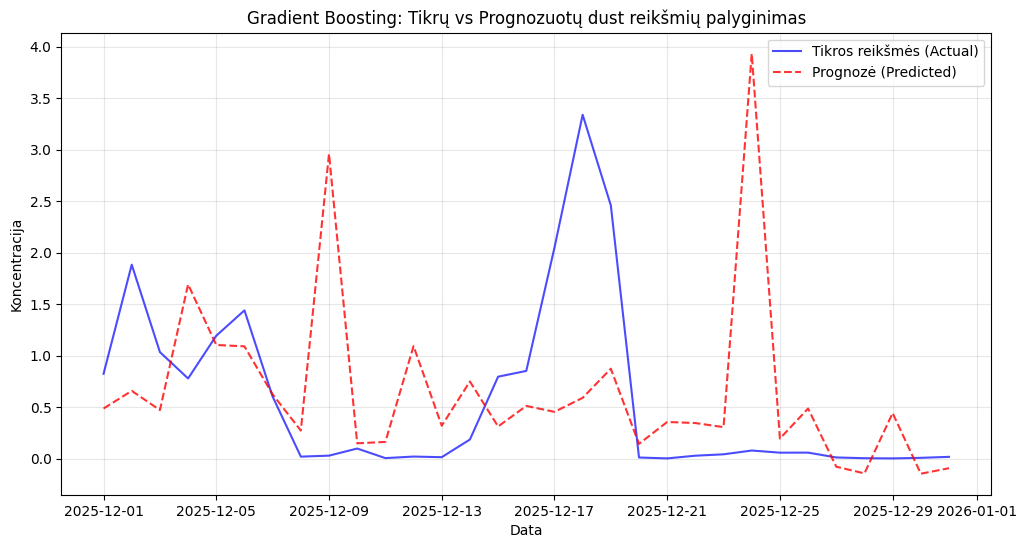

In [516]:
plt.figure(figsize=(12, 6))
plt.plot(test_data.index, y_test.values, label='Tikros reikšmės (Actual)', color='blue', alpha=0.7)
plt.plot(test_data.index, y_pred, label='Prognozė (Predicted)', color='red', linestyle='--', alpha=0.8)

plt.title(f'Gradient Boosting: Tikrų vs Prognozuotų {target} reikšmių palyginimas')
plt.xlabel('Data')
plt.ylabel('Koncentracija')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Random forest regressor

In [570]:
forecasting = data_for_forecasting.copy()

test_cutoff = '2025-12-01'
others = ['dust', 'sia', 'pm2p5', 'pans', 'nmvoc', 'nh3', 'pm10']
target = 'dust'

# forecasting['dust_lag_1'] = forecasting['dust'].shift(1)
forecasting['dust_lag_31'] = forecasting['dust'].shift(30)
# forecasting['nh3_weekly_trend'] = forecasting['nh3'].shift(30).rolling(window=7).mean()
forecasting.dropna(inplace=True)

train_data = forecasting[forecasting.index < test_cutoff]
test_data = forecasting[(forecasting.index >= test_cutoff) &
                                 (forecasting[target].notna())]

In [571]:
cols_to_drop = [target] + others

X_train = train_data.drop(columns=cols_to_drop)
y_train = train_data[target]

X_test = test_data.drop(columns=cols_to_drop)
y_test = test_data[target]

In [572]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import TimeSeriesSplit
tscv = TimeSeriesSplit(n_splits=3)

param_grid = {
    'n_estimators': [100, 200, 500],
    'max_depth': [None, 10, 20, 30],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', None]
}

rf_random = RandomizedSearchCV(
    estimator=RandomForestRegressor(),
    param_distributions=param_grid,
    n_iter=10,
    cv=tscv,
    random_state=42,
    n_jobs=-1
)

rf_random.fit(X_train, y_train)
best_model = rf_random.best_params_
print(f"Geriausi parametrai: {best_model}")

Geriausi parametrai: {'n_estimators': 500, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'max_depth': 20}


In [573]:
model = rf_random.best_estimator_

In [574]:
y_pred = model.predict(X_test)
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"--- Modelio rezultatai ---")
print(f"R2 koeficientas: {r2:.4f}")
print(f"RMSE paklaida: {rmse:.4f}")

--- Modelio rezultatai ---
R2 koeficientas: 0.1165
RMSE paklaida: 0.7956


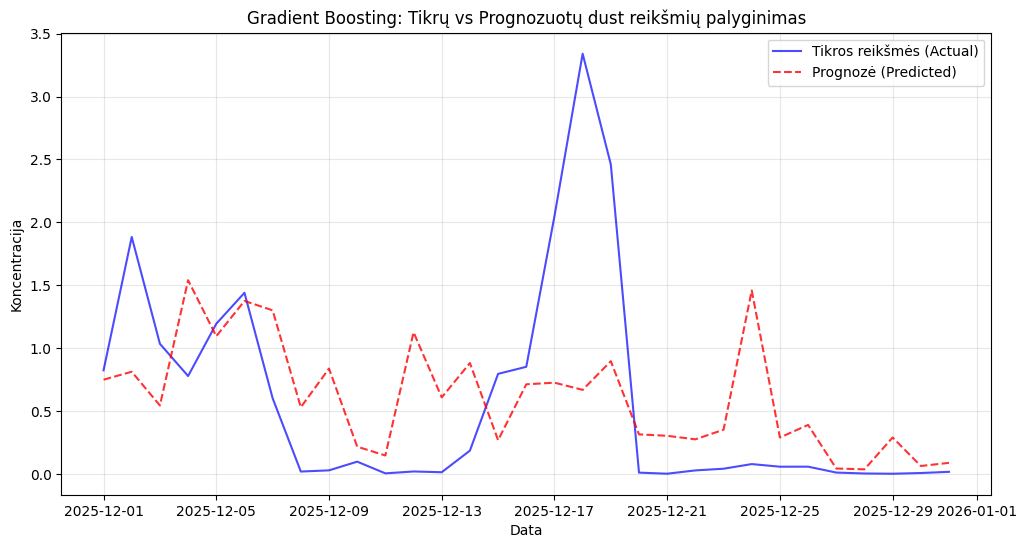

In [575]:
plt.figure(figsize=(12, 6))
plt.plot(test_data.index, y_test.values, label='Tikros reikšmės (Actual)', color='blue', alpha=0.7)
plt.plot(test_data.index, y_pred, label='Prognozė (Predicted)', color='red', linestyle='--', alpha=0.8)

plt.title(f'Gradient Boosting: Tikrų vs Prognozuotų {target} reikšmių palyginimas')
plt.xlabel('Data')
plt.ylabel('Koncentracija')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Bazinis modelis

## PM10

In [995]:
pm10 = pd.DataFrame(data_for_forecasting['pm10'].dropna())
pm10

,pm10
observationTime,
2018-07-01,1.338105
2018-07-02,1.752331
2018-07-03,1.789138
2018-07-04,4.323638
2018-07-05,3.718909
...,...
2025-12-27,2.881006
2025-12-28,3.642734
2025-12-29,2.402864


In [996]:
pm10_train = pm10.iloc[:-30]
pm10_test = pm10.iloc[-30:]

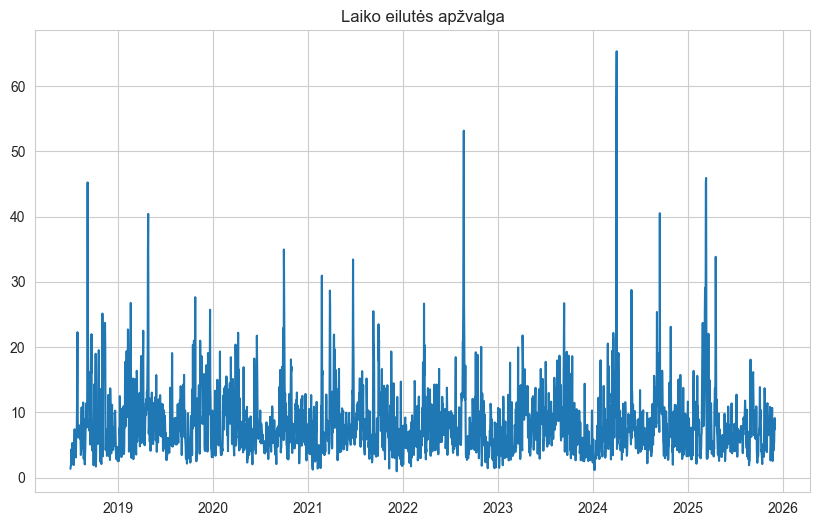

ADF Statistika: -15.343581359844148
p-reikšmė: 3.8023119674327223e-28


In [997]:
from statsmodels.tsa.stattools import adfuller

plt.figure(figsize=(10, 6))
plt.plot(pm10_train)
plt.title('Laiko eilutės apžvalga')
plt.show()

# ADF Testas
result = adfuller(pm10_train)
print(f'ADF Statistika: {result[0]}')
print(f'p-reikšmė: {result[1]}')

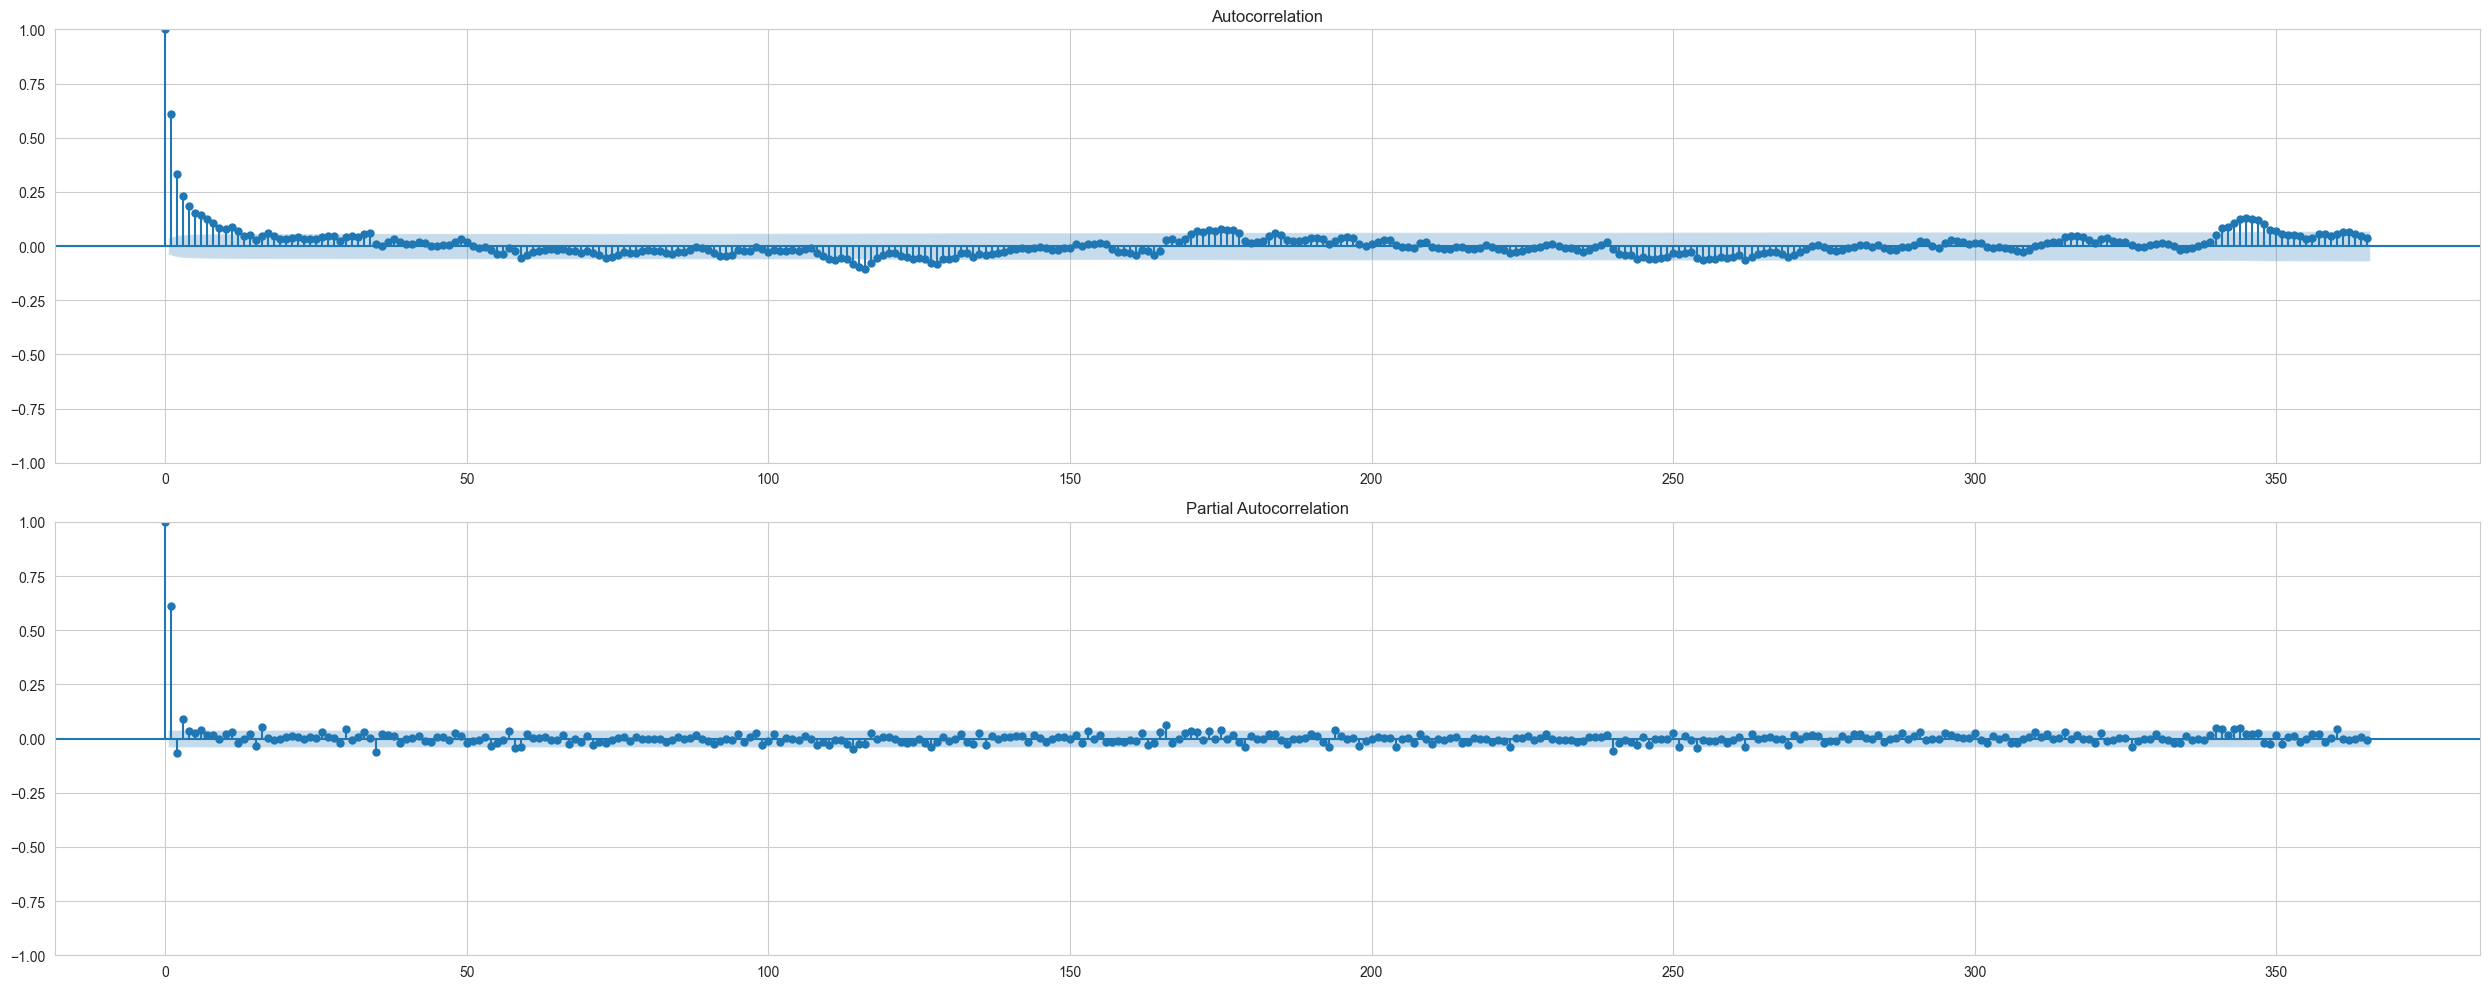

In [998]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(25, 10))
plot_acf(pm10_train, lags=365, ax=ax1)
plot_pacf(pm10_train, lags=365, ax=ax2)
plt.tight_layout()
plt.show()

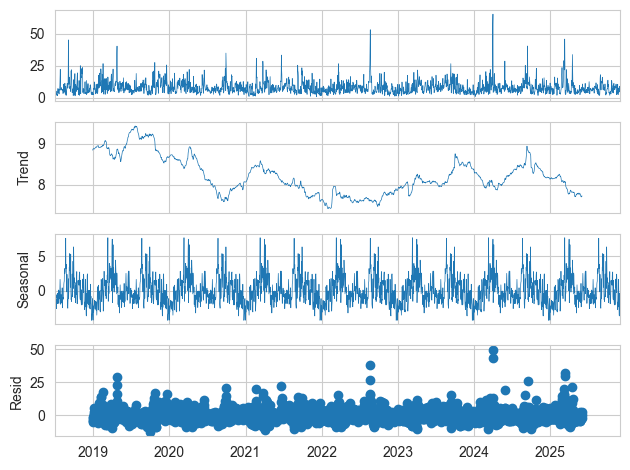

In [999]:
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.pyplot as plt

decomposition = seasonal_decompose(pm10_train, model='additive', period=365)

fig = decomposition.plot()

for ax in fig.axes:
    for line in ax.get_lines():
        line.set_linewidth(0.5)

plt.show()

In [1000]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(pm10_train)
print("ADF Statistic:", result[0])
print("p-value:", result[1])
for key, value in result[4].items():
    print(f'Critical Value ({key}): {value}')

ADF Statistic: -15.343581359844148
p-value: 3.8023119674327223e-28
Critical Value (1%): -3.43276978425183
Critical Value (5%): -2.862609083446103
Critical Value (10%): -2.5673391084832975


eilute stacionari

C:\Users\rugil\AppData\Local\Temp\ipykernel_31892\563462367.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  pm10_train['pm10_Seasonal_Diff'] = pm10_train['pm10'] - pm10_train['pm10'].shift(365)


ADF Statistic after Differencing: -20.8179
p-value after Seasonal Differencing: 0.0


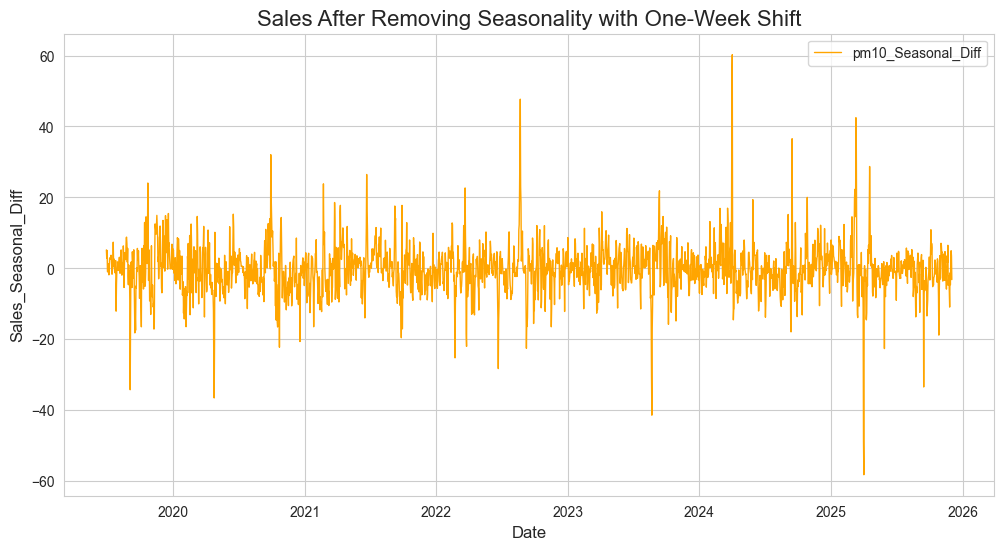

In [1003]:
#Seasonal Differencing for seaonality removal
pm10_train['pm10_Seasonal_Diff'] = pm10_train['pm10'] - pm10_train['pm10'].shift(365) 

result_diff_seasonal = adfuller(pm10_train['pm10_Seasonal_Diff'].dropna())
print("ADF Statistic after Differencing:", result_diff_seasonal[0].round(4))
print("p-value after Seasonal Differencing:", result_diff_seasonal[1])


plt.figure(figsize=(12, 6))
plt.plot(pm10_train.index, pm10_train['pm10_Seasonal_Diff'], label='pm10_Seasonal_Diff', linewidth=1, color='orange')
plt.title('Sales After Removing Seasonality with One-Week Shift', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Sales_Seasonal_Diff', fontsize=12)
plt.grid(True)
plt.legend()
plt.show()

In [1004]:
from pmdarima import auto_arima

model = auto_arima(pm10_train['pm10_Seasonal_Diff'].dropna(), 
                   stepwise=True, 
                   suppress_warnings=True, 
                   error_action="ignore", 
                   trace=True)

print(model.summary())

Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0] intercept   : AIC=14766.317, Time=2.37 sec
 ARIMA(0,0,0)(0,0,0)[0] intercept   : AIC=15756.192, Time=0.09 sec
 ARIMA(1,0,0)(0,0,0)[0] intercept   : AIC=14800.292, Time=0.23 sec
 ARIMA(0,0,1)(0,0,0)[0] intercept   : AIC=14910.902, Time=0.57 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=15755.705, Time=0.05 sec
 ARIMA(1,0,2)(0,0,0)[0] intercept   : AIC=14766.996, Time=0.97 sec
 ARIMA(2,0,1)(0,0,0)[0] intercept   : AIC=14767.877, Time=1.30 sec
 ARIMA(3,0,2)(0,0,0)[0] intercept   : AIC=inf, Time=4.67 sec
 ARIMA(2,0,3)(0,0,0)[0] intercept   : AIC=14768.226, Time=2.31 sec
 ARIMA(1,0,1)(0,0,0)[0] intercept   : AIC=14767.242, Time=0.61 sec
 ARIMA(1,0,3)(0,0,0)[0] intercept   : AIC=14766.826, Time=1.64 sec
 ARIMA(3,0,1)(0,0,0)[0] intercept   : AIC=14767.236, Time=2.89 sec
 ARIMA(3,0,3)(0,0,0)[0] intercept   : AIC=14767.469, Time=4.87 sec
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=14764.704, Time=0.95 sec
 ARIMA(1,0,2)(0,0,0)[0]  

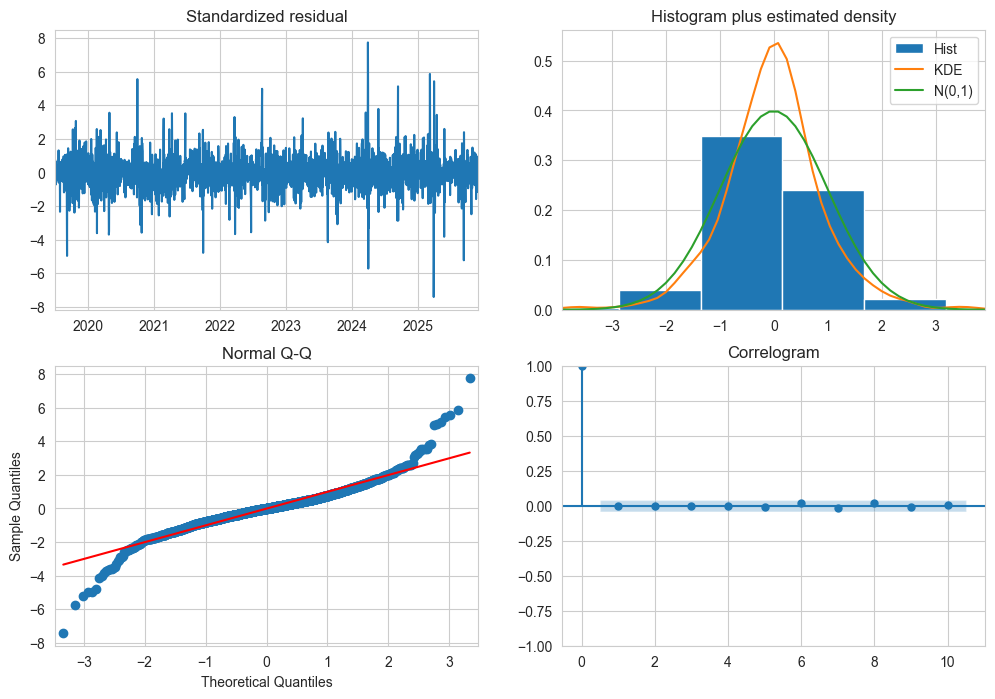

In [1006]:
model.plot_diagnostics(figsize=(12, 8))
plt.show()

In [1009]:
n = len(pm10_test)

# forecastingam diff erdveje
forecast_diff, conf_int = model.predict(n_periods=n, return_conf_int=True)

# atstatom tai ka pasalinom (y_t - y_{t-365}) + y_{t-365} = y_t
# base = pm10_train['pm10'].shift(366).iloc[-n:].values
base = pm10['pm10'].iloc[-365 - n : -365].values
forecast_real = forecast_diff + base

forecast_series = pd.Series(forecast_real, index=pm10_test.index)
conf_int_real = conf_int + base.reshape(-1, 1)

In [1010]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

y_true = pm10_test['pm10']
y_pred = forecast_series

mse = mean_squared_error(y_true, y_pred)
mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_true, y_pred)

print(f"MSE: {mse:.2f}")
print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²: {r2:.4f}")

MSE: 23.50
MAE: 3.83
RMSE: 4.85
R²: -0.6376


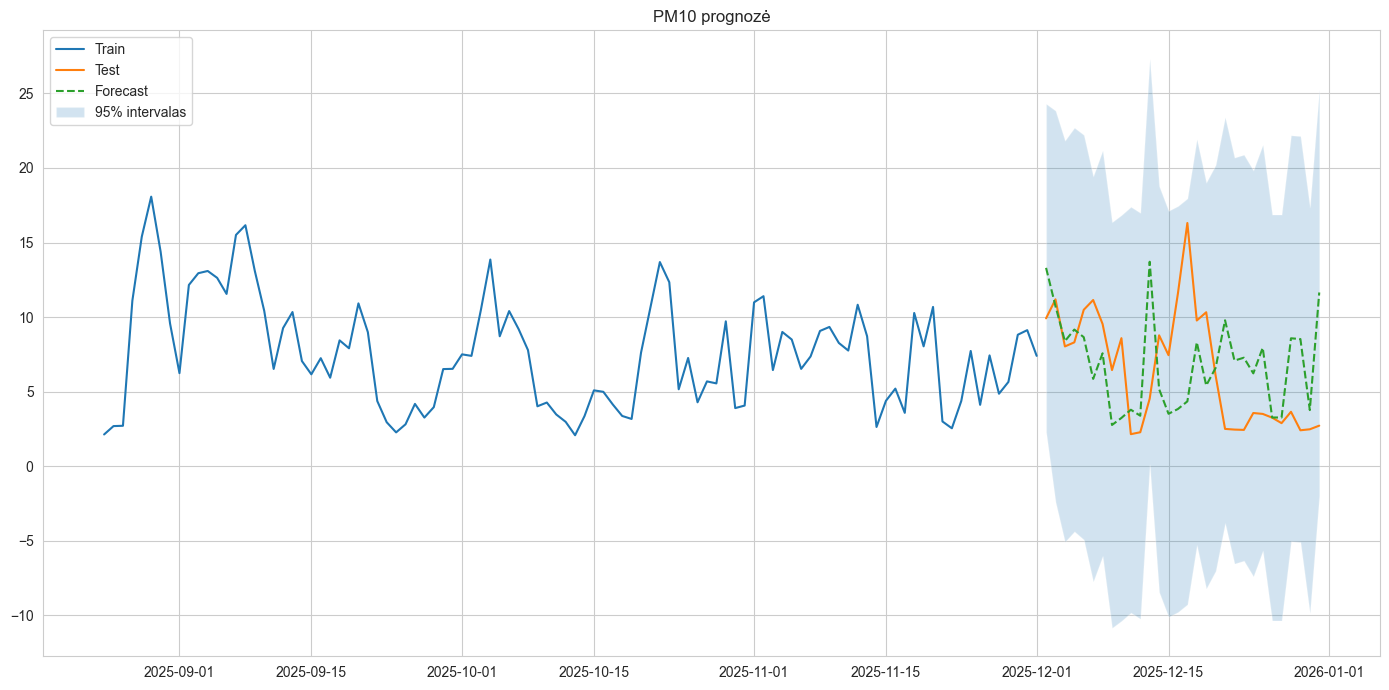

In [1011]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 7))

plt.plot(pm10_train.tail(100).index, pm10_train.tail(100)['pm10'], label='Train')
plt.plot(pm10_test.index, pm10_test['pm10'], label='Test')
plt.plot(forecast_series.index, forecast_series, linestyle='--', label='Forecast')

plt.fill_between(pm10_test.index,
                 conf_int_real[:, 0],
                 conf_int_real[:, 1],
                 alpha=0.2,
                 label='95% intervalas')

plt.title('PM10 prognozė')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## NH3

In [1012]:
nh3 = pd.DataFrame(data_for_forecasting['nh3'].dropna())
nh3_train = nh3.iloc[:-30]
nh3_test = nh3.iloc[-30:]

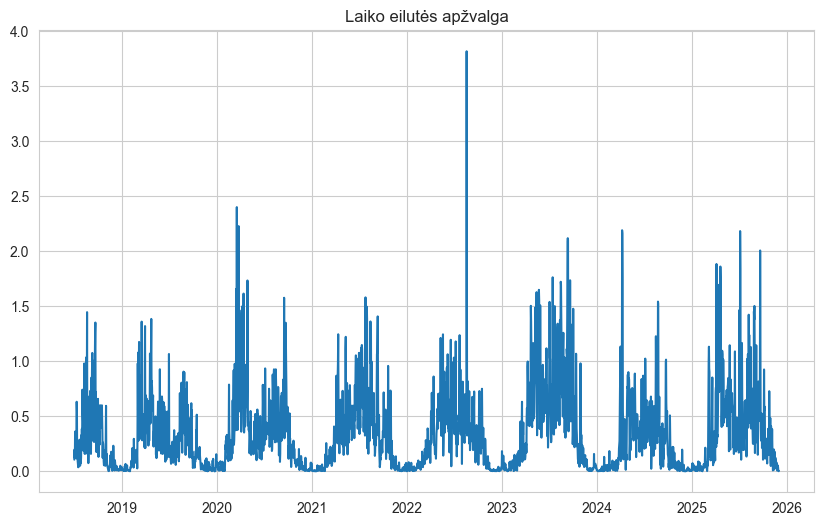

ADF Statistika: -4.292852142863221
p-reikšmė: 0.0004570446630870589


In [1013]:
from statsmodels.tsa.stattools import adfuller

plt.figure(figsize=(10, 6))
plt.plot(nh3_train)
plt.title('Laiko eilutės apžvalga')
plt.show()

# ADF Testas
result = adfuller(nh3_train)
print(f'ADF Statistika: {result[0]}')
print(f'p-reikšmė: {result[1]}')

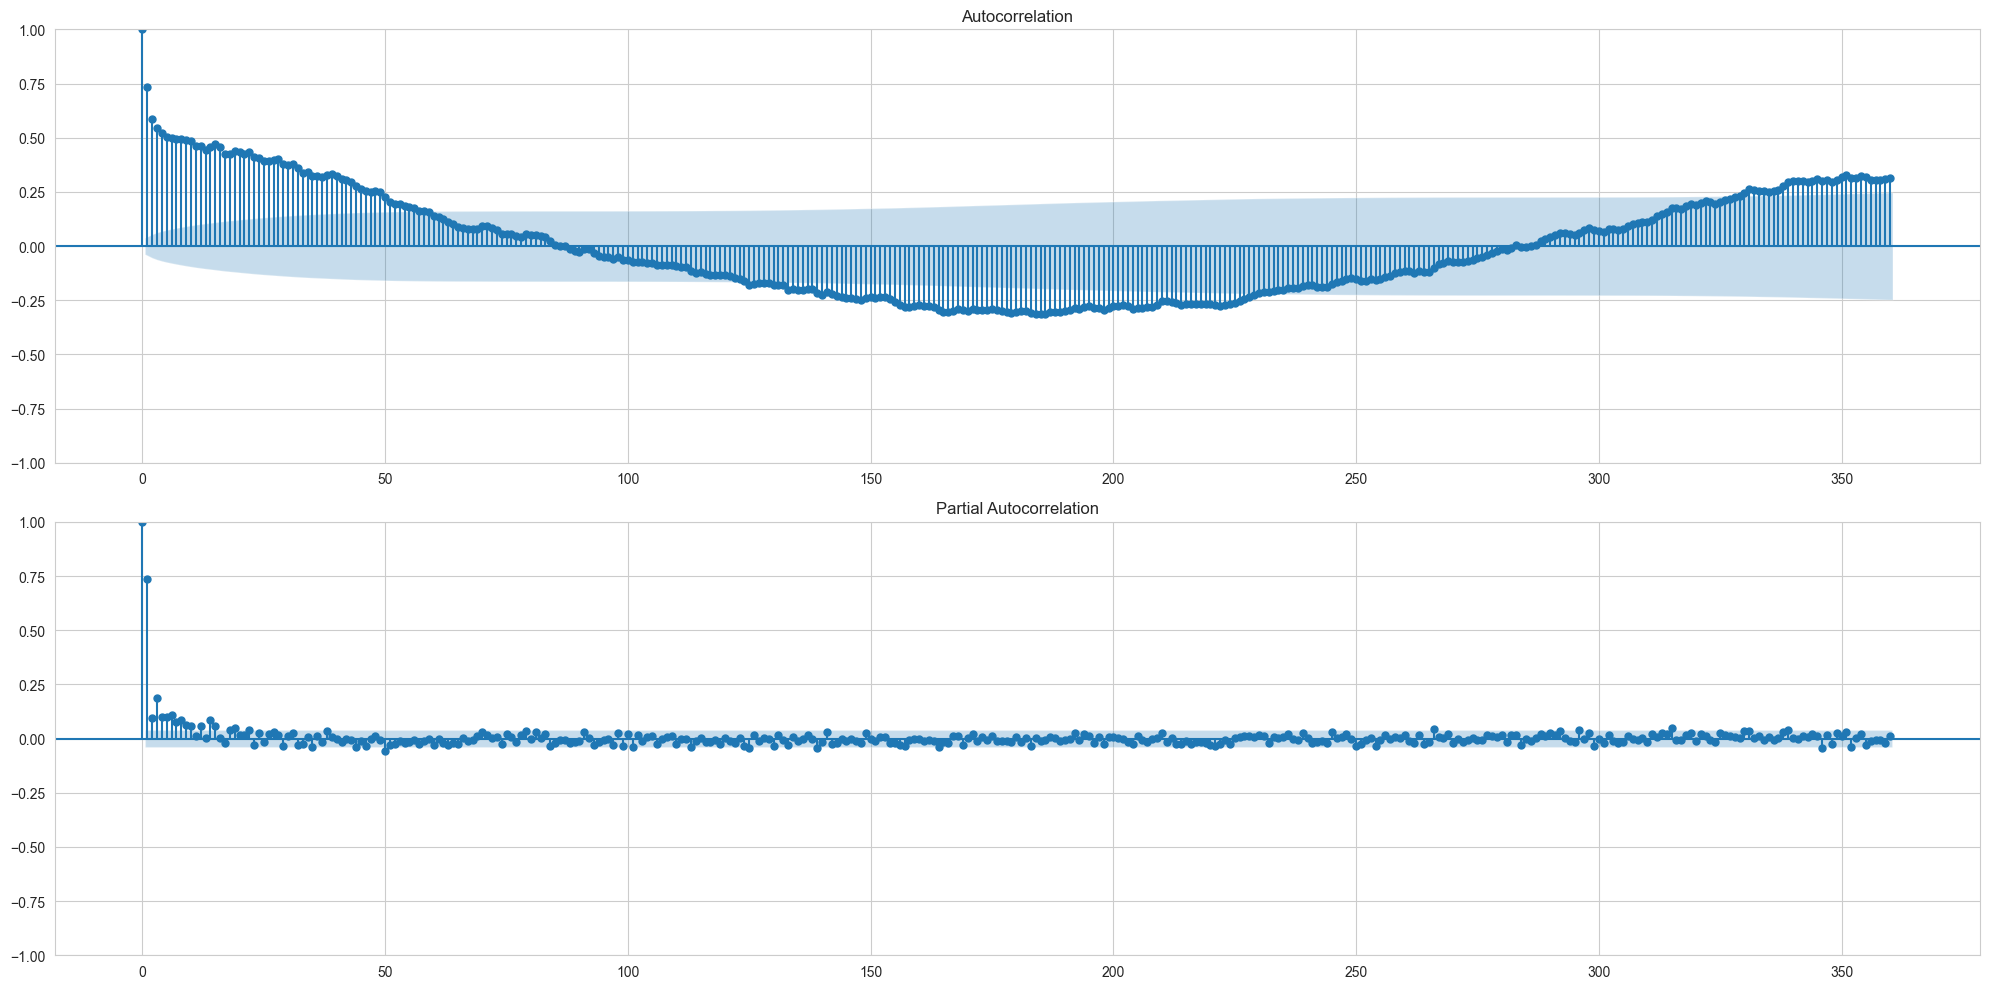

In [1014]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(20, 10))
plot_acf(nh3_train, lags=365, ax=ax1)
plot_pacf(nh3_train, lags=365, ax=ax2)
plt.tight_layout()
plt.show()

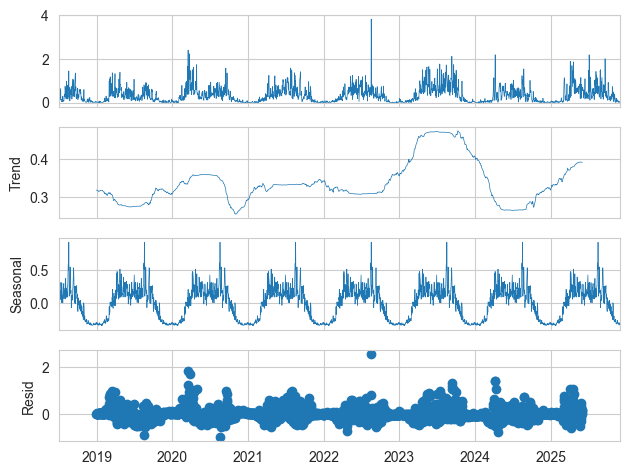

In [1015]:
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.pyplot as plt

decomposition = seasonal_decompose(nh3_train, model='additive', period=365)

fig = decomposition.plot()

for ax in fig.axes:
    for line in ax.get_lines():
        line.set_linewidth(0.5)

plt.show()

In [1016]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(nh3_train)
print("ADF Statistic:", result[0])
print("p-value:", result[1])
for key, value in result[4].items():
    print(f'Critical Value ({key}): {value}')

ADF Statistic: -4.292852142863221
p-value: 0.0004570446630870589
Critical Value (1%): -3.432785102598709
Critical Value (5%): -2.8626158484711364
Critical Value (10%): -2.5673427101989885


C:\Users\rugil\AppData\Local\Temp\ipykernel_31892\3559728161.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  nh3_train['nh3_Seasonal_Diff'] = nh3_train['nh3'] - nh3_train['nh3'].shift(365)


ADF Statistic after Differencing: -5.0594
p-value after Seasonal Differencing: 0.0


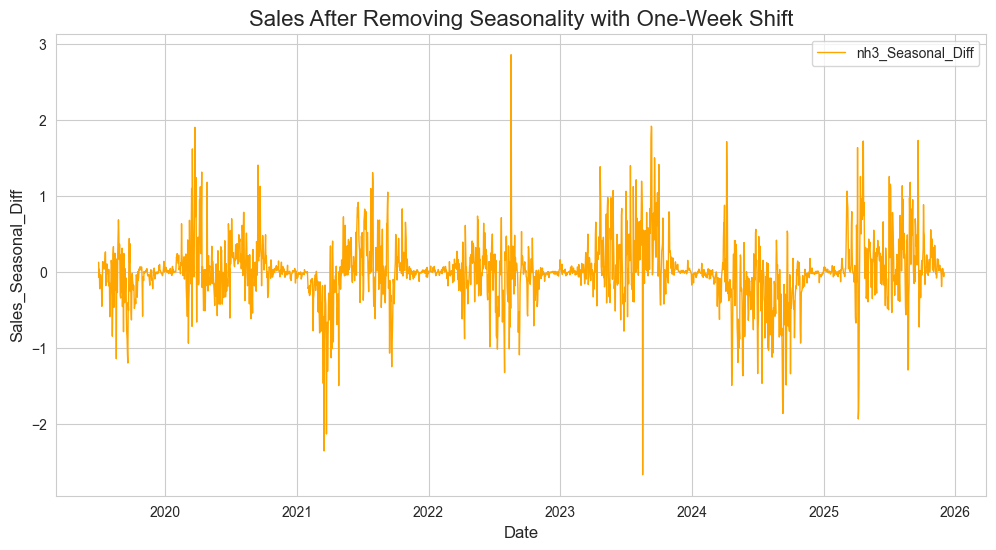

In [1017]:
nh3_train['nh3_Seasonal_Diff'] = nh3_train['nh3'] - nh3_train['nh3'].shift(365) 

result_diff_seasonal = adfuller(nh3_train['nh3_Seasonal_Diff'].dropna())
print("ADF Statistic after Differencing:", result_diff_seasonal[0].round(4))
print("p-value after Seasonal Differencing:", result_diff_seasonal[1].round(4))


plt.figure(figsize=(12, 6))
plt.plot(nh3_train.index, nh3_train['nh3_Seasonal_Diff'], label='nh3_Seasonal_Diff', linewidth=1, color='orange')
plt.title('Sales After Removing Seasonality with One-Week Shift', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Sales_Seasonal_Diff', fontsize=12)
plt.grid(True)
plt.legend()
plt.show()

In [1018]:
from pmdarima import auto_arima

model = auto_arima(nh3_train['nh3_Seasonal_Diff'].dropna(), 
                   stepwise=True, 
                   suppress_warnings=True, 
                   error_action="ignore", 
                   trace=True)

print(model.summary())

Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0] intercept   : AIC=1355.195, Time=4.52 sec
 ARIMA(0,0,0)(0,0,0)[0] intercept   : AIC=2431.115, Time=0.38 sec
 ARIMA(1,0,0)(0,0,0)[0] intercept   : AIC=1431.664, Time=0.38 sec
 ARIMA(0,0,1)(0,0,0)[0] intercept   : AIC=1671.057, Time=0.53 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=2430.989, Time=0.19 sec
 ARIMA(1,0,2)(0,0,0)[0] intercept   : AIC=1395.195, Time=1.71 sec
 ARIMA(2,0,1)(0,0,0)[0] intercept   : AIC=1435.660, Time=1.00 sec
 ARIMA(3,0,2)(0,0,0)[0] intercept   : AIC=1362.078, Time=4.75 sec
 ARIMA(2,0,3)(0,0,0)[0] intercept   : AIC=1360.445, Time=2.39 sec
 ARIMA(1,0,1)(0,0,0)[0] intercept   : AIC=1431.603, Time=0.78 sec
 ARIMA(1,0,3)(0,0,0)[0] intercept   : AIC=1368.521, Time=3.20 sec
 ARIMA(3,0,1)(0,0,0)[0] intercept   : AIC=1355.533, Time=3.16 sec
 ARIMA(3,0,3)(0,0,0)[0] intercept   : AIC=1358.700, Time=5.98 sec
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=1353.254, Time=1.16 sec
 ARIMA(1,0,2)(0,0,0)[0]          

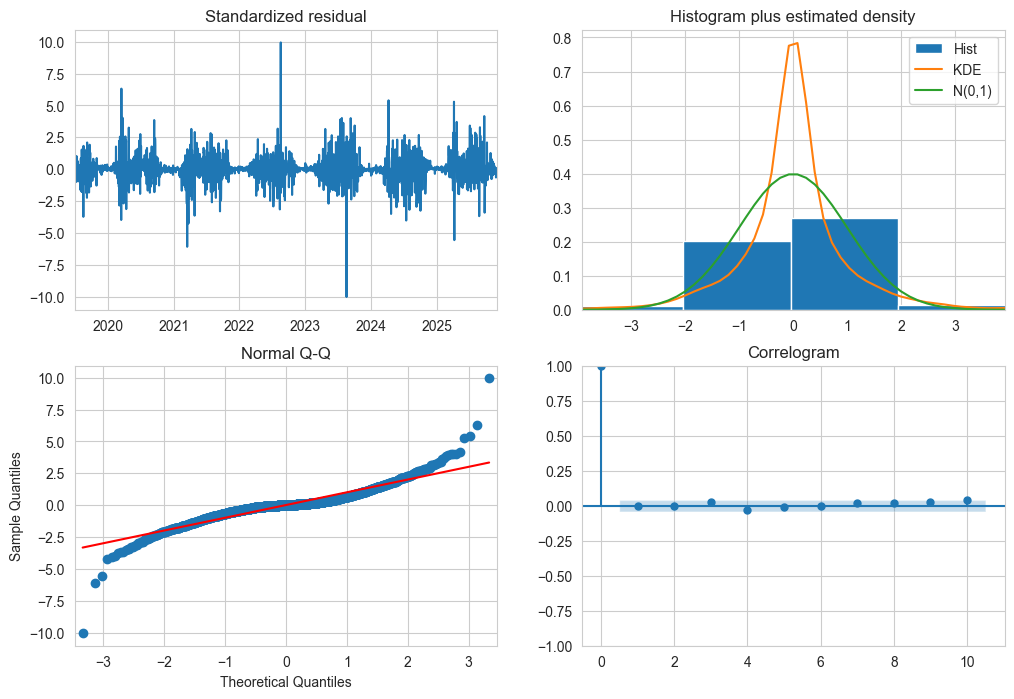

In [1019]:
model.plot_diagnostics(figsize=(12, 8))
plt.show()

In [1020]:
n = len(nh3_test)

# forecastingam diff erdveje
forecast_diff, conf_int = model.predict(n_periods=n, return_conf_int=True)

# atstatom tai ka pasalinom (y_t - y_{t-365}) + y_{t-365} = y_t
# base = nh3_train['nh3'].shift(365).iloc[-n:].values
base = nh3['nh3'].iloc[-365 - n : -365].values
forecast_real = forecast_diff + base

forecast_series = pd.Series(forecast_real, index=nh3_test.index)
conf_int_real = conf_int + base.reshape(-1, 1)

In [1021]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

y_true = nh3_test['nh3']
y_pred = forecast_series

mse = mean_squared_error(y_true, y_pred)
mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_true, y_pred)

print(f"MSE: {mse:.2f}")
print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²: {r2:.4f}")

MSE: 0.00
MAE: 0.02
RMSE: 0.03
R²: -0.2590


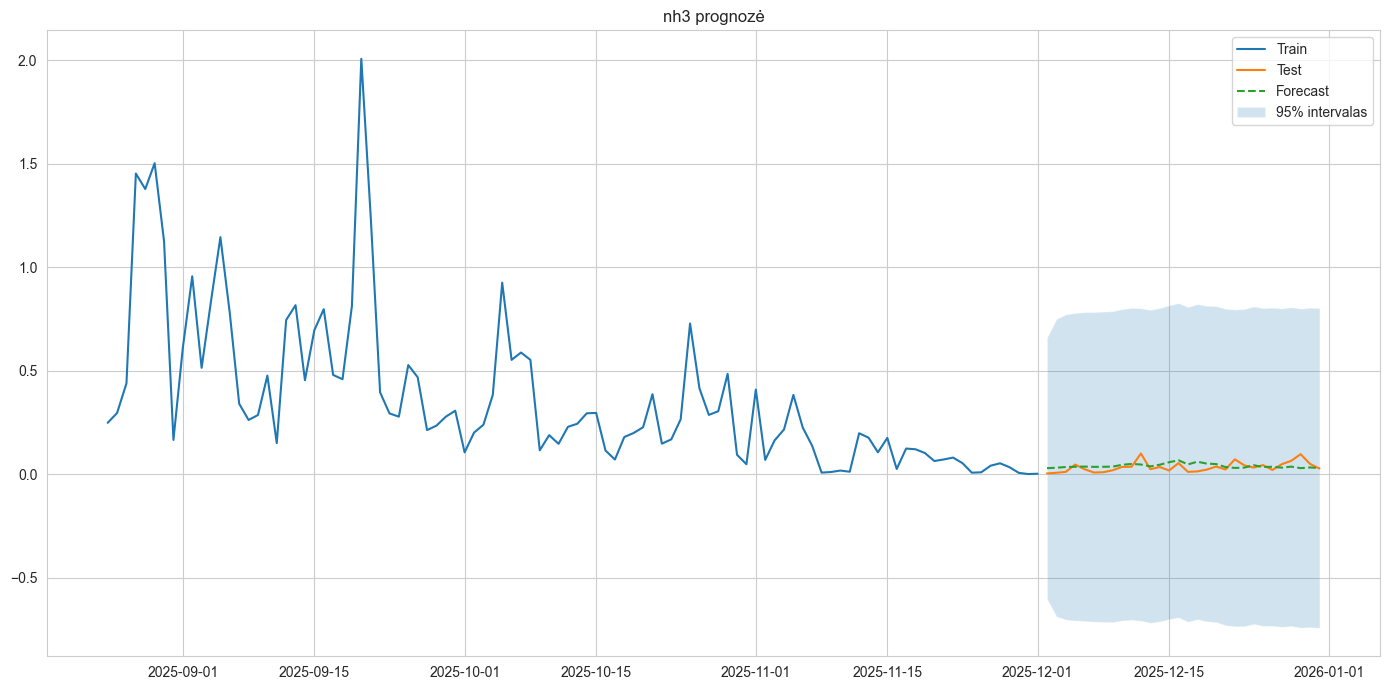

In [1022]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 7))

plt.plot(nh3_train.tail(100).index, nh3_train.tail(100)['nh3'], label='Train')
plt.plot(nh3_test.index, nh3_test['nh3'], label='Test')
plt.plot(forecast_series.index, forecast_series, linestyle='--', label='Forecast')

plt.fill_between(nh3_test.index,
                 conf_int_real[:, 0],
                 conf_int_real[:, 1],
                 alpha=0.2,
                 label='95% intervalas')

plt.title('nh3 prognozė')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## NMVOC

In [1023]:
nmvoc = pd.DataFrame(data_for_forecasting['nmvoc'].dropna())
nmvoc_train = nmvoc.iloc[:-30]
nmvoc_test = nmvoc.iloc[-30:]

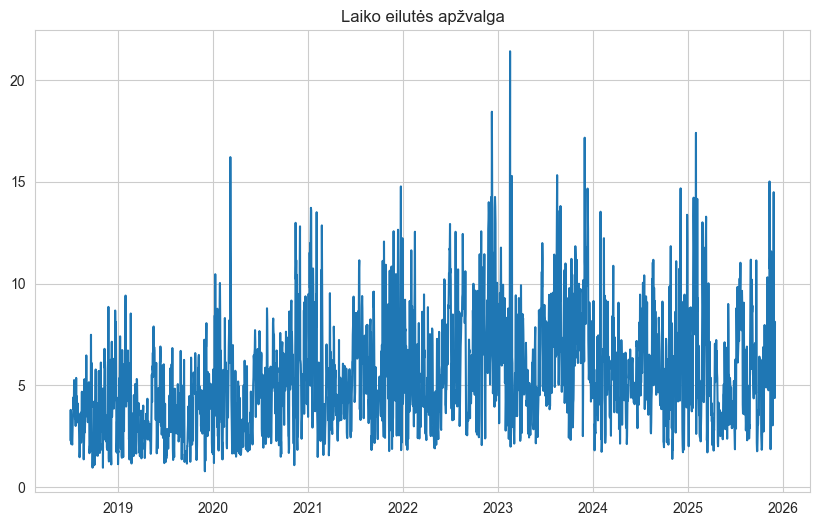

ADF Statistika: -6.316712739151542
p-reikšmė: 3.137534289270228e-08


In [1024]:
from statsmodels.tsa.stattools import adfuller

plt.figure(figsize=(10, 6))
plt.plot(nmvoc_train)
plt.title('Laiko eilutės apžvalga')
plt.show()

# ADF Testas
result = adfuller(nmvoc_train)
print(f'ADF Statistika: {result[0]}')
print(f'p-reikšmė: {result[1]}')

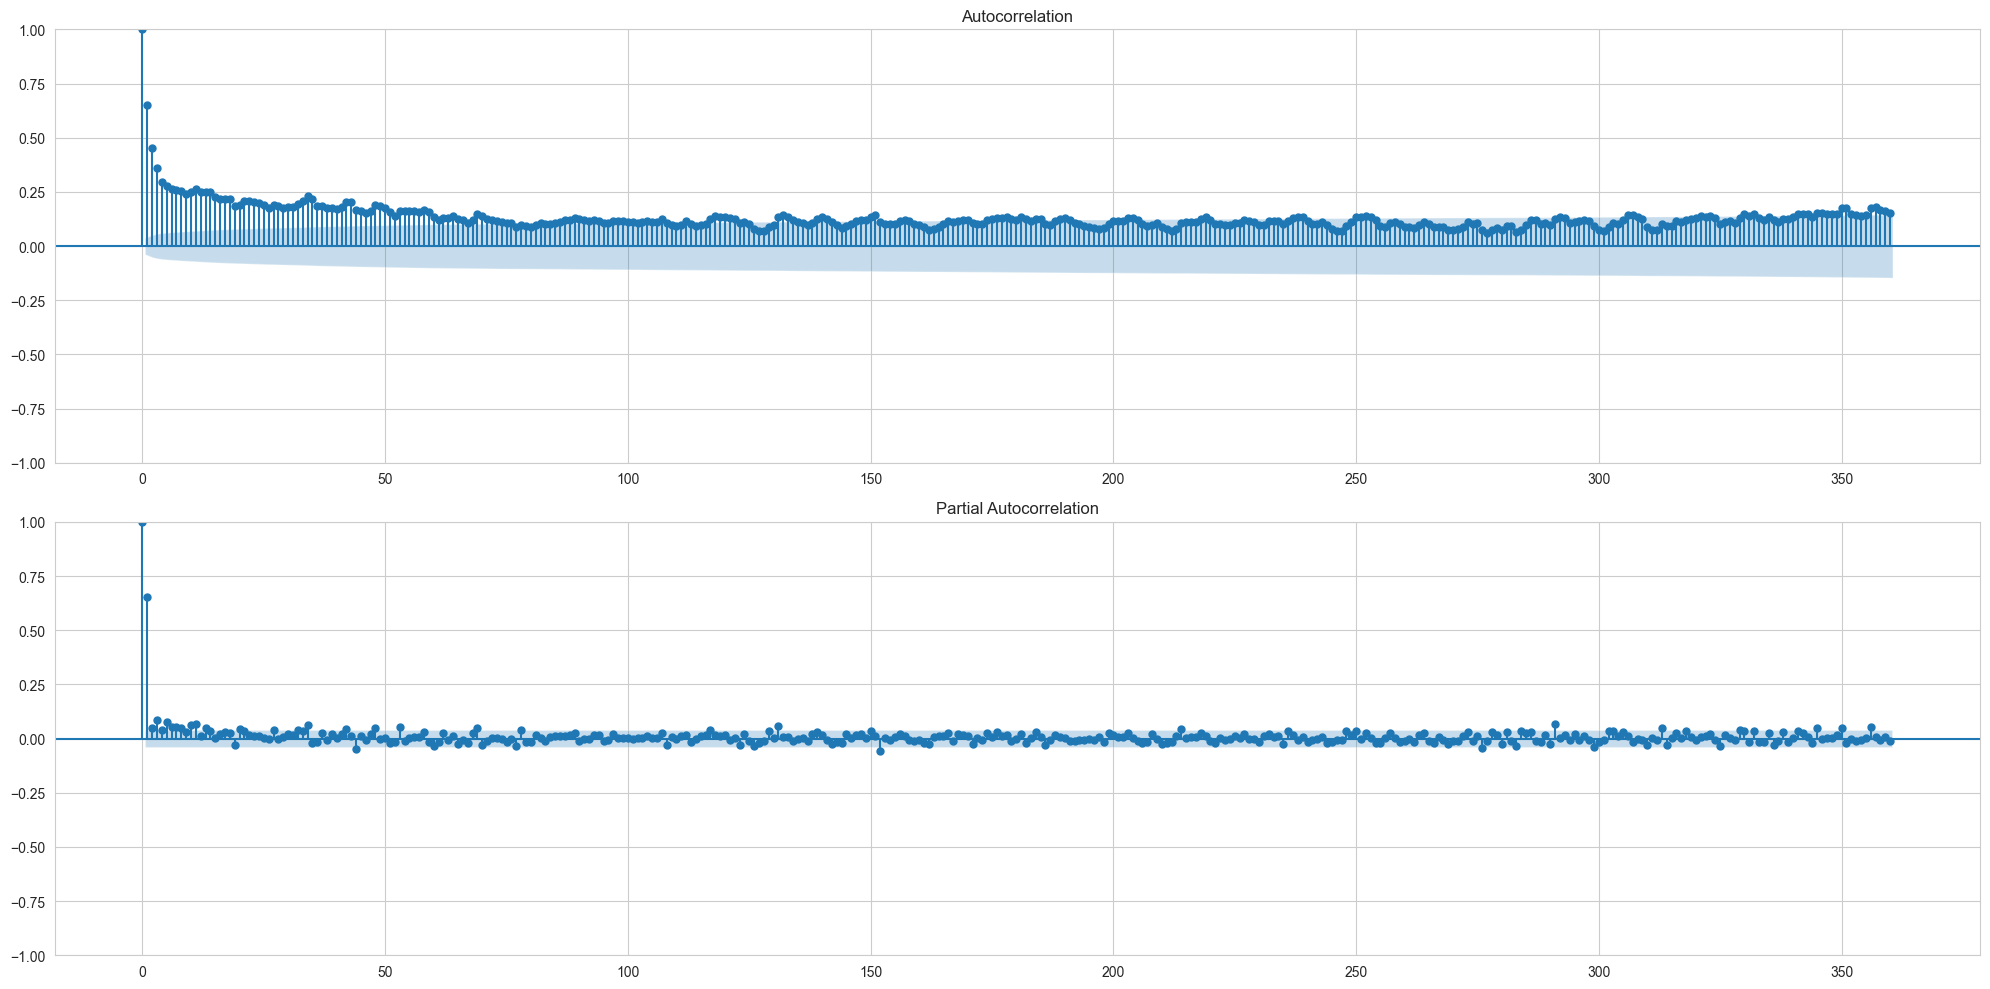

In [1025]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(20, 10))
plot_acf(nmvoc_train, lags=360, ax=ax1)
plot_pacf(nmvoc_train, lags=360, ax=ax2)
plt.tight_layout()
plt.show()

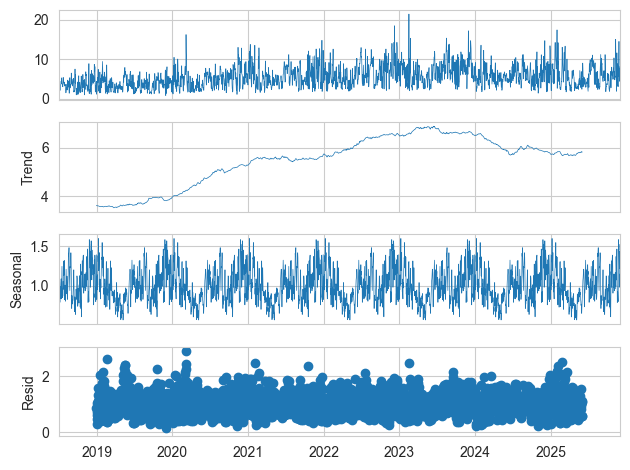

In [1026]:
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.pyplot as plt

decomposition = seasonal_decompose(nmvoc_train, model='multiplicative', period=365)

fig = decomposition.plot()

for ax in fig.axes:
    for line in ax.get_lines():
        line.set_linewidth(0.5)

plt.show()

In [1027]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(nmvoc_train)
print("ADF Statistic:", result[0])
print("p-value:", result[1])
for key, value in result[4].items():
    print(f'Critical Value ({key}): {value}')

ADF Statistic: -6.316712739151542
p-value: 3.137534289270228e-08
Critical Value (1%): -3.4327832903814204
Critical Value (5%): -2.8626150481453765
Critical Value (10%): -2.567342284103315


C:\Users\rugil\AppData\Local\Temp\ipykernel_31892\512341864.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  nmvoc_train['nmvoc_Seasonal_Diff'] = nmvoc_train['nmvoc'] - nmvoc_train['nmvoc'].shift(365)


ADF Statistic after Differencing: -8.3155
p-value after Seasonal Differencing: 3.689756789312279e-13


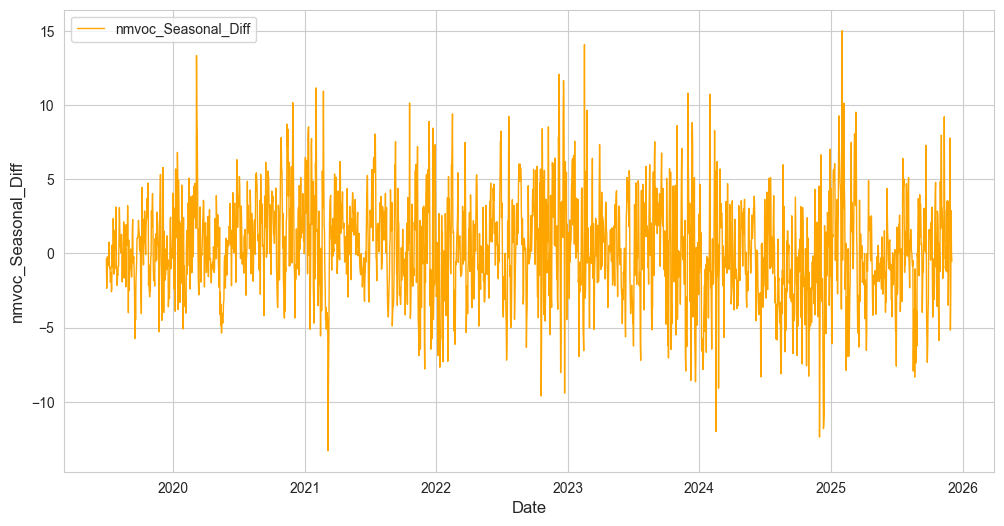

In [1028]:
nmvoc_train['nmvoc_Seasonal_Diff'] = nmvoc_train['nmvoc'] - nmvoc_train['nmvoc'].shift(365) 

result_diff_seasonal = adfuller(nmvoc_train['nmvoc_Seasonal_Diff'].dropna())
print("ADF Statistic after Differencing:", result_diff_seasonal[0].round(4))
print("p-value after Seasonal Differencing:", result_diff_seasonal[1])


plt.figure(figsize=(12, 6))
plt.plot(nmvoc_train.index, nmvoc_train['nmvoc_Seasonal_Diff'], label='nmvoc_Seasonal_Diff', linewidth=1, color='orange')
plt.title('', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('nmvoc_Seasonal_Diff', fontsize=12)
plt.grid(True)
plt.legend()
plt.show()

In [1029]:
from pmdarima import auto_arima

model = auto_arima(nmvoc_train['nmvoc_Seasonal_Diff'].dropna(), 
                   stepwise=True, 
                   suppress_warnings=True, 
                   error_action="ignore", 
                   trace=True)

print(model.summary())

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=inf, Time=3.53 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=12046.061, Time=0.13 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=11942.038, Time=0.27 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=11852.968, Time=0.35 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=12044.061, Time=0.10 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=inf, Time=1.44 sec
 ARIMA(0,1,2)(0,0,0)[0] intercept   : AIC=11573.952, Time=1.08 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=inf, Time=3.07 sec
 ARIMA(0,1,3)(0,0,0)[0] intercept   : AIC=11497.224, Time=2.23 sec
 ARIMA(1,1,3)(0,0,0)[0] intercept   : AIC=inf, Time=4.00 sec
 ARIMA(0,1,4)(0,0,0)[0] intercept   : AIC=11455.180, Time=2.83 sec
 ARIMA(1,1,4)(0,0,0)[0] intercept   : AIC=inf, Time=4.58 sec
 ARIMA(0,1,5)(0,0,0)[0] intercept   : AIC=inf, Time=4.16 sec
 ARIMA(1,1,5)(0,0,0)[0] intercept   : AIC=11456.251, Time=7.38 sec
 ARIMA(0,1,4)(0,0,0)[0]             : AIC=11453.182, Ti

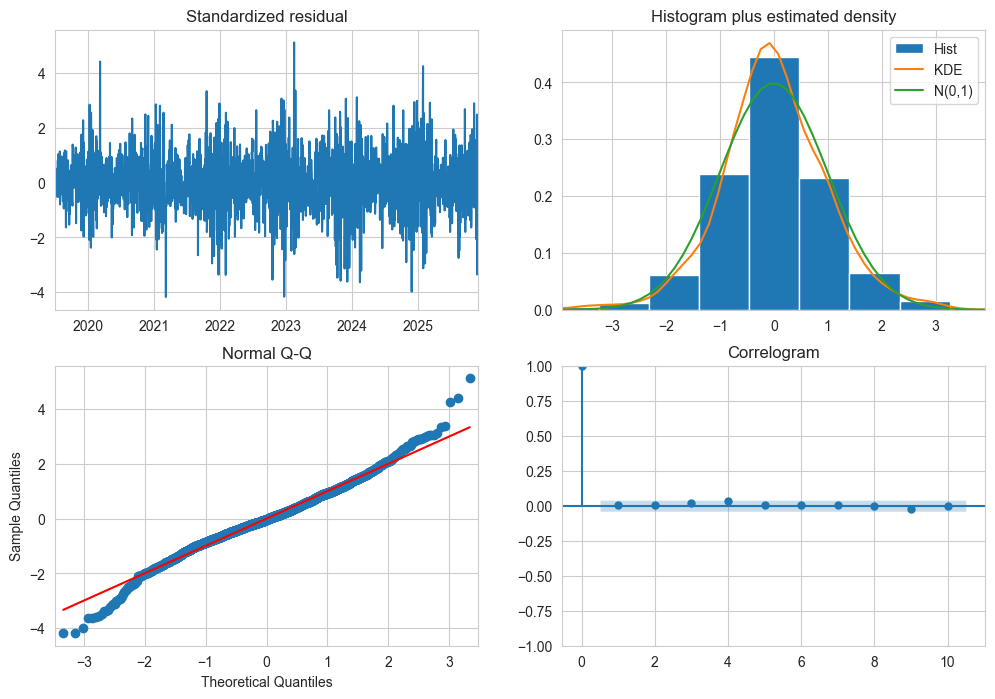

In [1030]:
model.plot_diagnostics(figsize=(12, 8))
plt.show()

In [1031]:
n = len(nmvoc_test)

# forecastingam diff erdveje
forecast_diff, conf_int = model.predict(n_periods=n, return_conf_int=True)

# atstatom tai ka pasalinom (y_t - y_{t-365}) + y_{t-365} = y_t
# base = nmvoc_train['nmvoc'].shift(365).iloc[-n:].values
base = nmvoc['nmvoc'].iloc[-365 - n : -365].values
forecast_real = forecast_diff + base

forecast_series = pd.Series(forecast_real, index=nmvoc_test.index)
conf_int_real = conf_int + base.reshape(-1, 1)

In [1032]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

y_true = nmvoc_test['nmvoc']
y_pred = forecast_series

mse = mean_squared_error(y_true, y_pred)
mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_true, y_pred)

print(f"MSE: {mse:.2f}")
print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²: {r2:.4f}")

MSE: 25.47
MAE: 4.11
RMSE: 5.05
R²: -1.2933


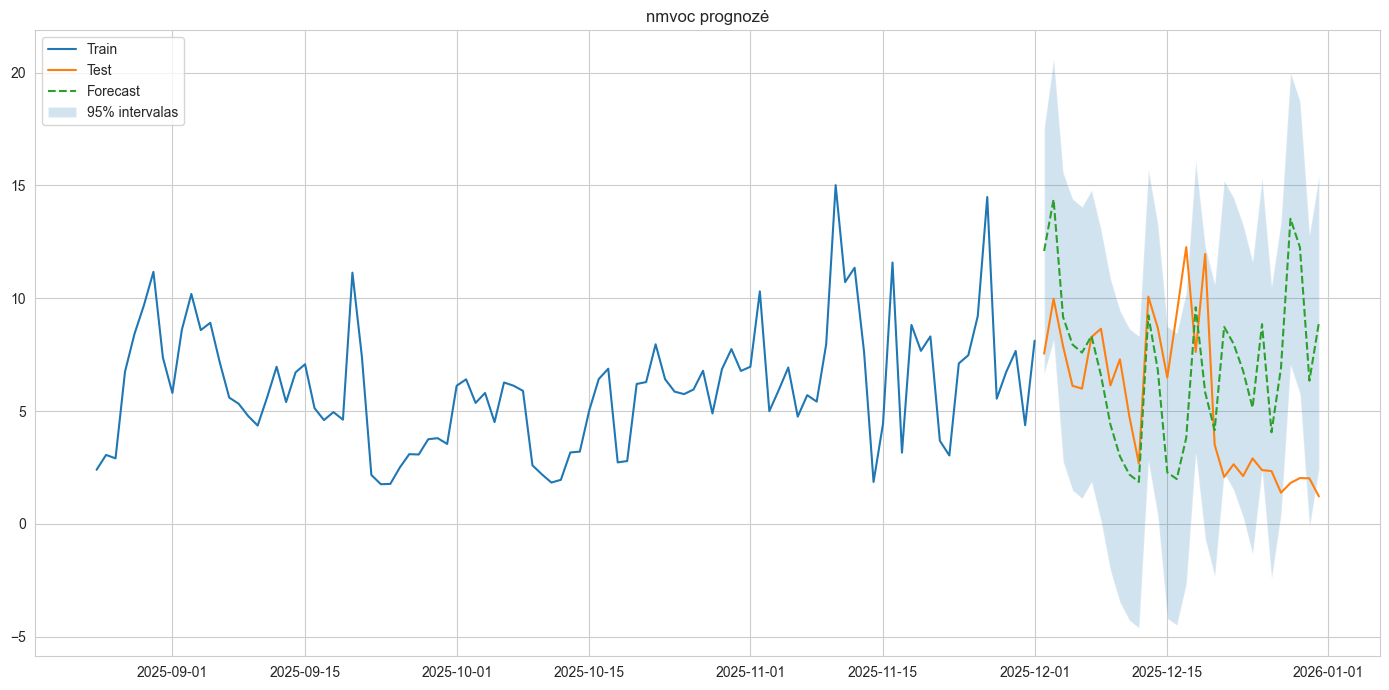

In [1033]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 7))

plt.plot(nmvoc_train.tail(100).index, nmvoc_train.tail(100)['nmvoc'], label='Train')
plt.plot(nmvoc_test.index, nmvoc_test['nmvoc'], label='Test')
plt.plot(forecast_series.index, forecast_series, linestyle='--', label='Forecast')

plt.fill_between(nmvoc_test.index,
                 conf_int_real[:, 0],
                 conf_int_real[:, 1],
                 alpha=0.2,
                 label='95% intervalas')

plt.title('nmvoc prognozė')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## PANS

In [1034]:
pans = pd.DataFrame(data_for_forecasting['pans'].dropna())
pans_train = pans.iloc[:-30]
pans_test = pans.iloc[-30:]

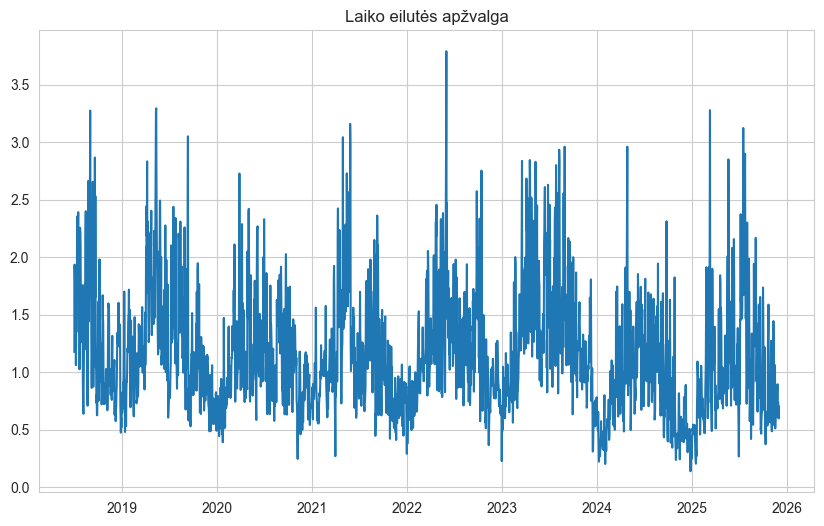

ADF Statistika: -5.295907457161035
p-reikšmė: 5.583554724042609e-06


In [1035]:
from statsmodels.tsa.stattools import adfuller

plt.figure(figsize=(10, 6))
plt.plot(pans_train)
plt.title('Laiko eilutės apžvalga')
plt.show()

# ADF Testas
result = adfuller(pans_train)
print(f'ADF Statistika: {result[0]}')
print(f'p-reikšmė: {result[1]}')

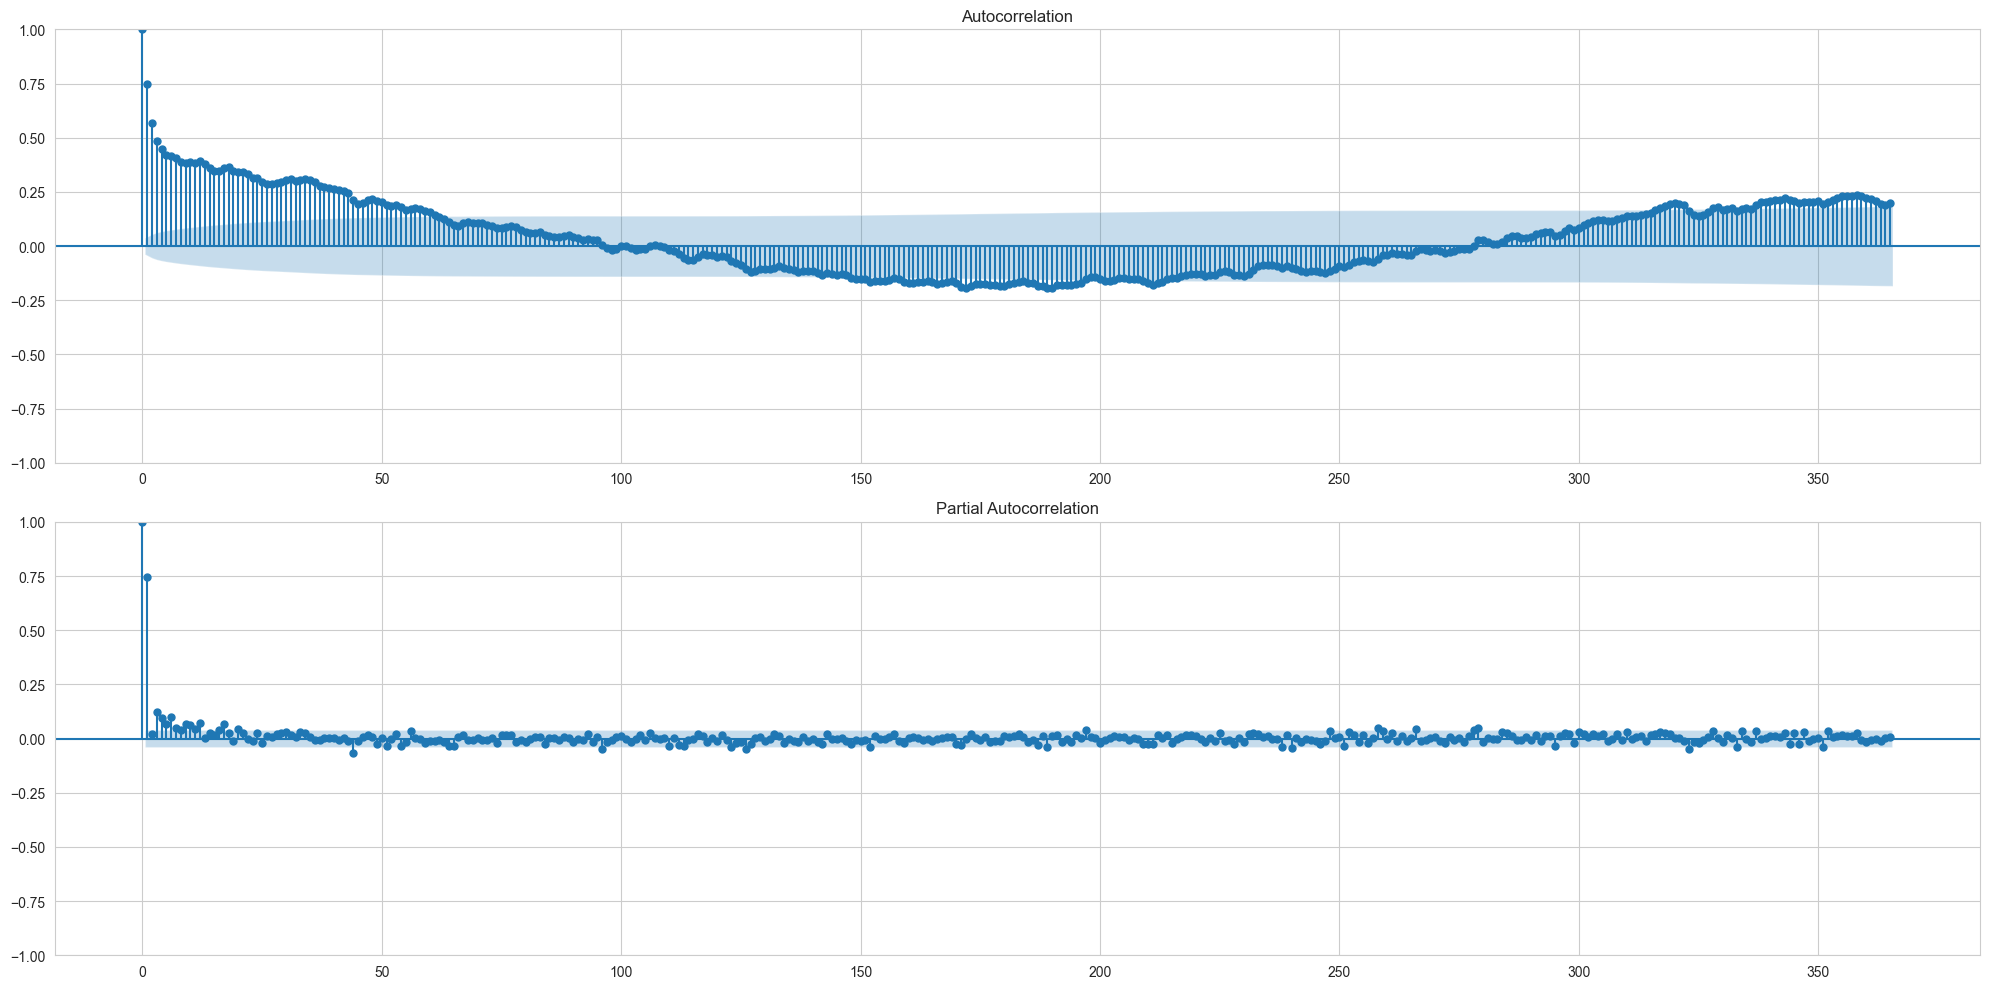

In [1036]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(20, 10))
plot_acf(pans_train, lags=365, ax=ax1)
plot_pacf(pans_train, lags=365, ax=ax2)
plt.tight_layout()
plt.show()

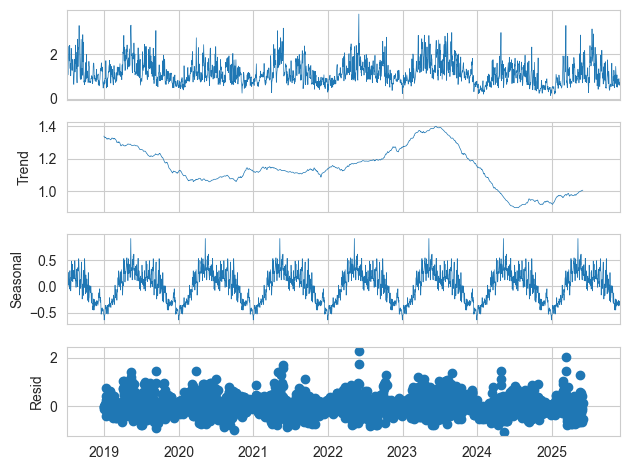

In [938]:
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.pyplot as plt

decomposition = seasonal_decompose(pans_train, model='additive', period=365)

fig = decomposition.plot()

for ax in fig.axes:
    for line in ax.get_lines():
        line.set_linewidth(0.5)

plt.show()

In [1037]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(pans_train)
print("ADF Statistic:", result[0])
print("p-value:", result[1])
for key, value in result[4].items():
    print(f'Critical Value ({key}): {value}')

ADF Statistic: -5.295907457161035
p-value: 5.583554724042609e-06
Critical Value (1%): -3.4327823852838972
Critical Value (5%): -2.8626146484288544
Critical Value (10%): -2.5673420712931514


C:\Users\rugil\AppData\Local\Temp\ipykernel_31892\2631425637.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  pans_train['pans_Seasonal_Diff'] = pans_train['pans'] - pans_train['pans'].shift(365)


ADF Statistic after Differencing: -7.4638
p-value after Seasonal Differencing: 0.0


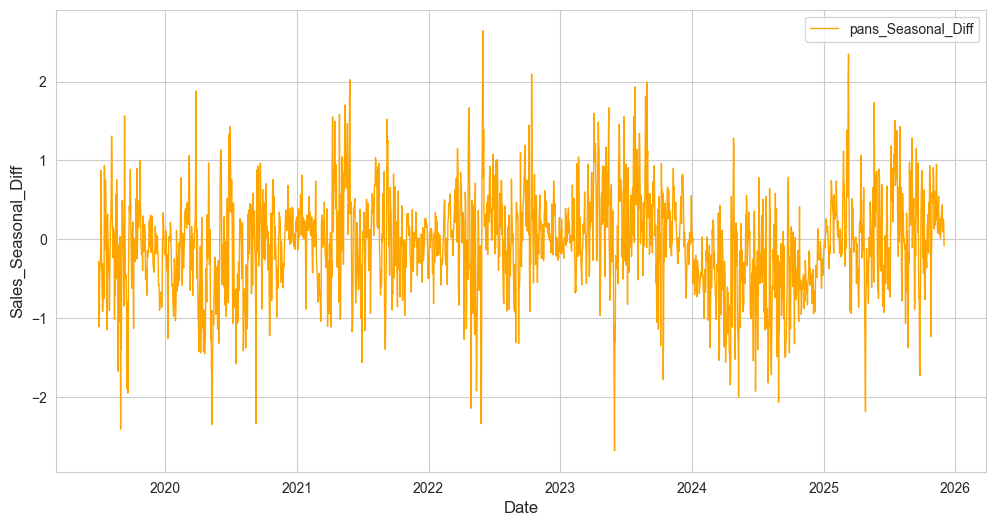

In [1038]:
pans_train['pans_Seasonal_Diff'] = pans_train['pans'] - pans_train['pans'].shift(365) 

result_diff_seasonal = adfuller(pans_train['pans_Seasonal_Diff'].dropna())
print("ADF Statistic after Differencing:", result_diff_seasonal[0].round(4))
print("p-value after Seasonal Differencing:", result_diff_seasonal[1].round(4))


plt.figure(figsize=(12, 6))
plt.plot(pans_train.index, pans_train['pans_Seasonal_Diff'], label='pans_Seasonal_Diff', linewidth=1, color='orange')
plt.title('', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Sales_Seasonal_Diff', fontsize=12)
plt.grid(True)
plt.legend()
plt.show()

In [1039]:
from pmdarima import auto_arima

model = auto_arima(pans_train['pans_Seasonal_Diff'].dropna(), 
                   stepwise=True, 
                   suppress_warnings=True, 
                   error_action="ignore", 
                   trace=True)

print(model.summary())

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=2996.992, Time=4.07 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=3461.155, Time=0.34 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=3414.497, Time=0.35 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=3375.595, Time=0.69 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=3459.155, Time=0.13 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=2986.997, Time=3.16 sec
 ARIMA(0,1,2)(0,0,0)[0] intercept   : AIC=3137.388, Time=1.04 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=2995.668, Time=2.14 sec
 ARIMA(1,1,3)(0,0,0)[0] intercept   : AIC=2988.901, Time=4.77 sec
 ARIMA(0,1,3)(0,0,0)[0] intercept   : AIC=3025.772, Time=1.65 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=2987.434, Time=3.62 sec
 ARIMA(2,1,3)(0,0,0)[0] intercept   : AIC=2988.597, Time=4.16 sec
 ARIMA(1,1,2)(0,0,0)[0]             : AIC=2985.118, Time=0.67 sec
 ARIMA(0,1,2)(0,0,0)[0]             : AIC=3135.402, Time=0.36 sec
 ARIMA(1,1,1)(0,0,0)[0]          

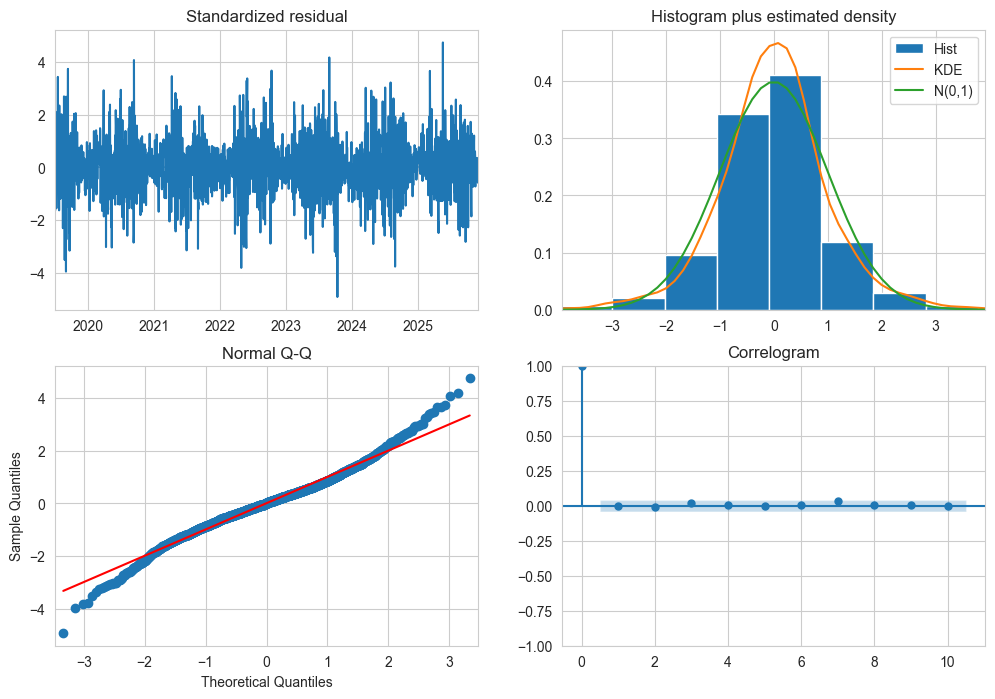

In [1040]:
model.plot_diagnostics(figsize=(12, 8))
plt.show()

In [1041]:
n = len(pans_test)

# forecastingam diff erdveje
forecast_diff, conf_int = model.predict(n_periods=n, return_conf_int=True)

# atstatom tai ka pasalinom (y_t - y_{t-365}) + y_{t-365} = y_t
# base = pans_train['pans'].shift(365).iloc[-n:].values
base = pans['pans'].iloc[-365 - n : -365].values
forecast_real = forecast_diff + base

forecast_series = pd.Series(forecast_real, index=pans_test.index)
conf_int_real = conf_int + base.reshape(-1, 1)

In [1042]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

y_true = pans_test['pans']
y_pred = forecast_series

mse = mean_squared_error(y_true, y_pred)
mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_true, y_pred)

print(f"MSE: {mse:.2f}")
print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²: {r2:.4f}")

MSE: 0.05
MAE: 0.18
RMSE: 0.23
R²: -0.2986


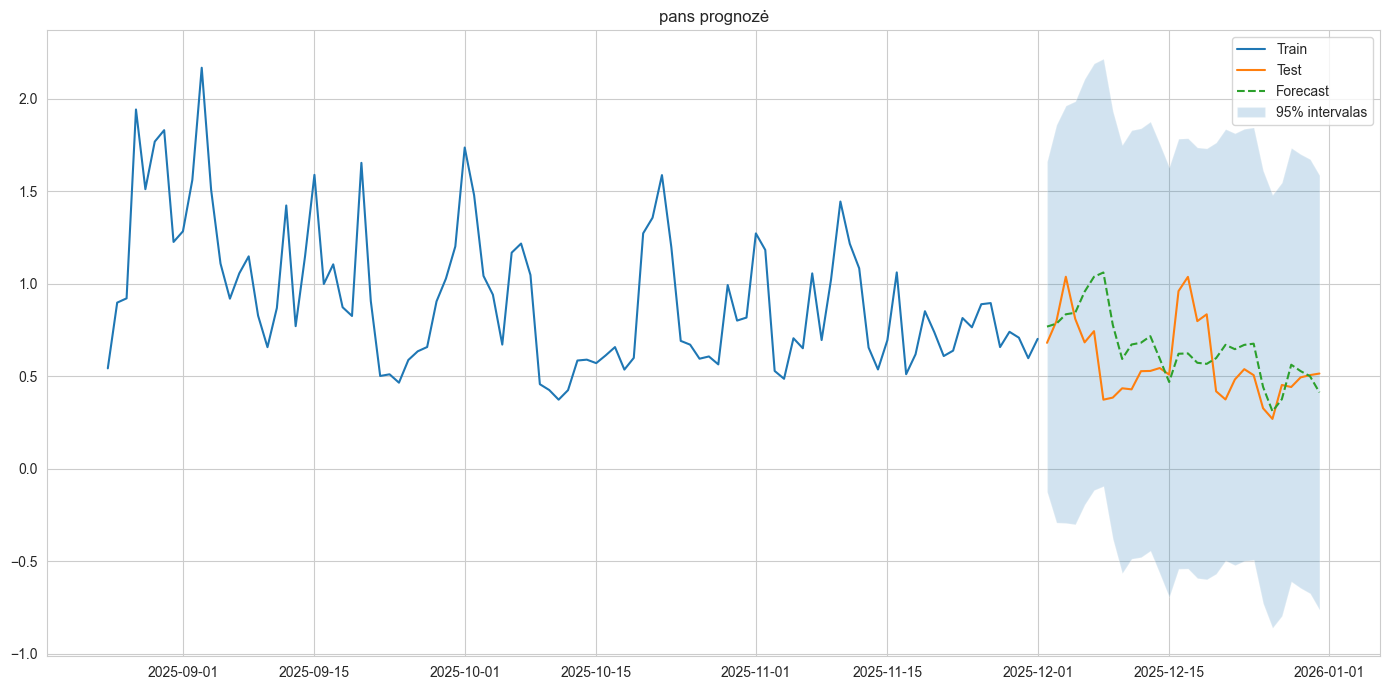

In [1043]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 7))

plt.plot(pans_train.tail(100).index, pans_train.tail(100)['pans'], label='Train')
plt.plot(pans_test.index, pans_test['pans'], label='Test')
plt.plot(forecast_series.index, forecast_series, linestyle='--', label='Forecast')

plt.fill_between(pans_test.index,
                 conf_int_real[:, 0],
                 conf_int_real[:, 1],
                 alpha=0.2,
                 label='95% intervalas')

plt.title('pans prognozė')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## PM2P5

In [948]:
pm2p5 = pd.DataFrame(data_for_forecasting['pm2p5'].dropna())
pm2p5_train = pm2p5.iloc[:-30]
pm2p5_test = pm2p5.iloc[-30:]

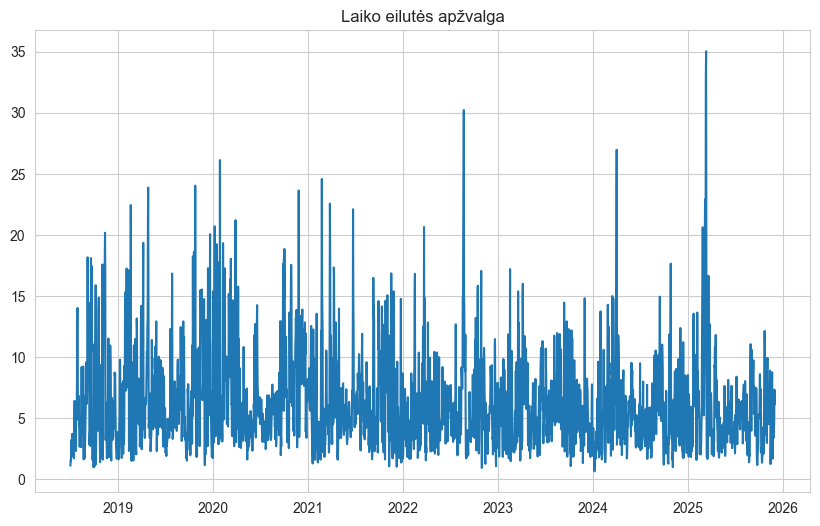

ADF Statistika: -11.800390560700688
p-reikšmė: 9.36106001021958e-22


In [949]:
from statsmodels.tsa.stattools import adfuller

plt.figure(figsize=(10, 6))
plt.plot(pm2p5_train)
plt.title('Laiko eilutės apžvalga')
plt.show()

# ADF Testas
result = adfuller(pm2p5_train)
print(f'ADF Statistika: {result[0]}')
print(f'p-reikšmė: {result[1]}')

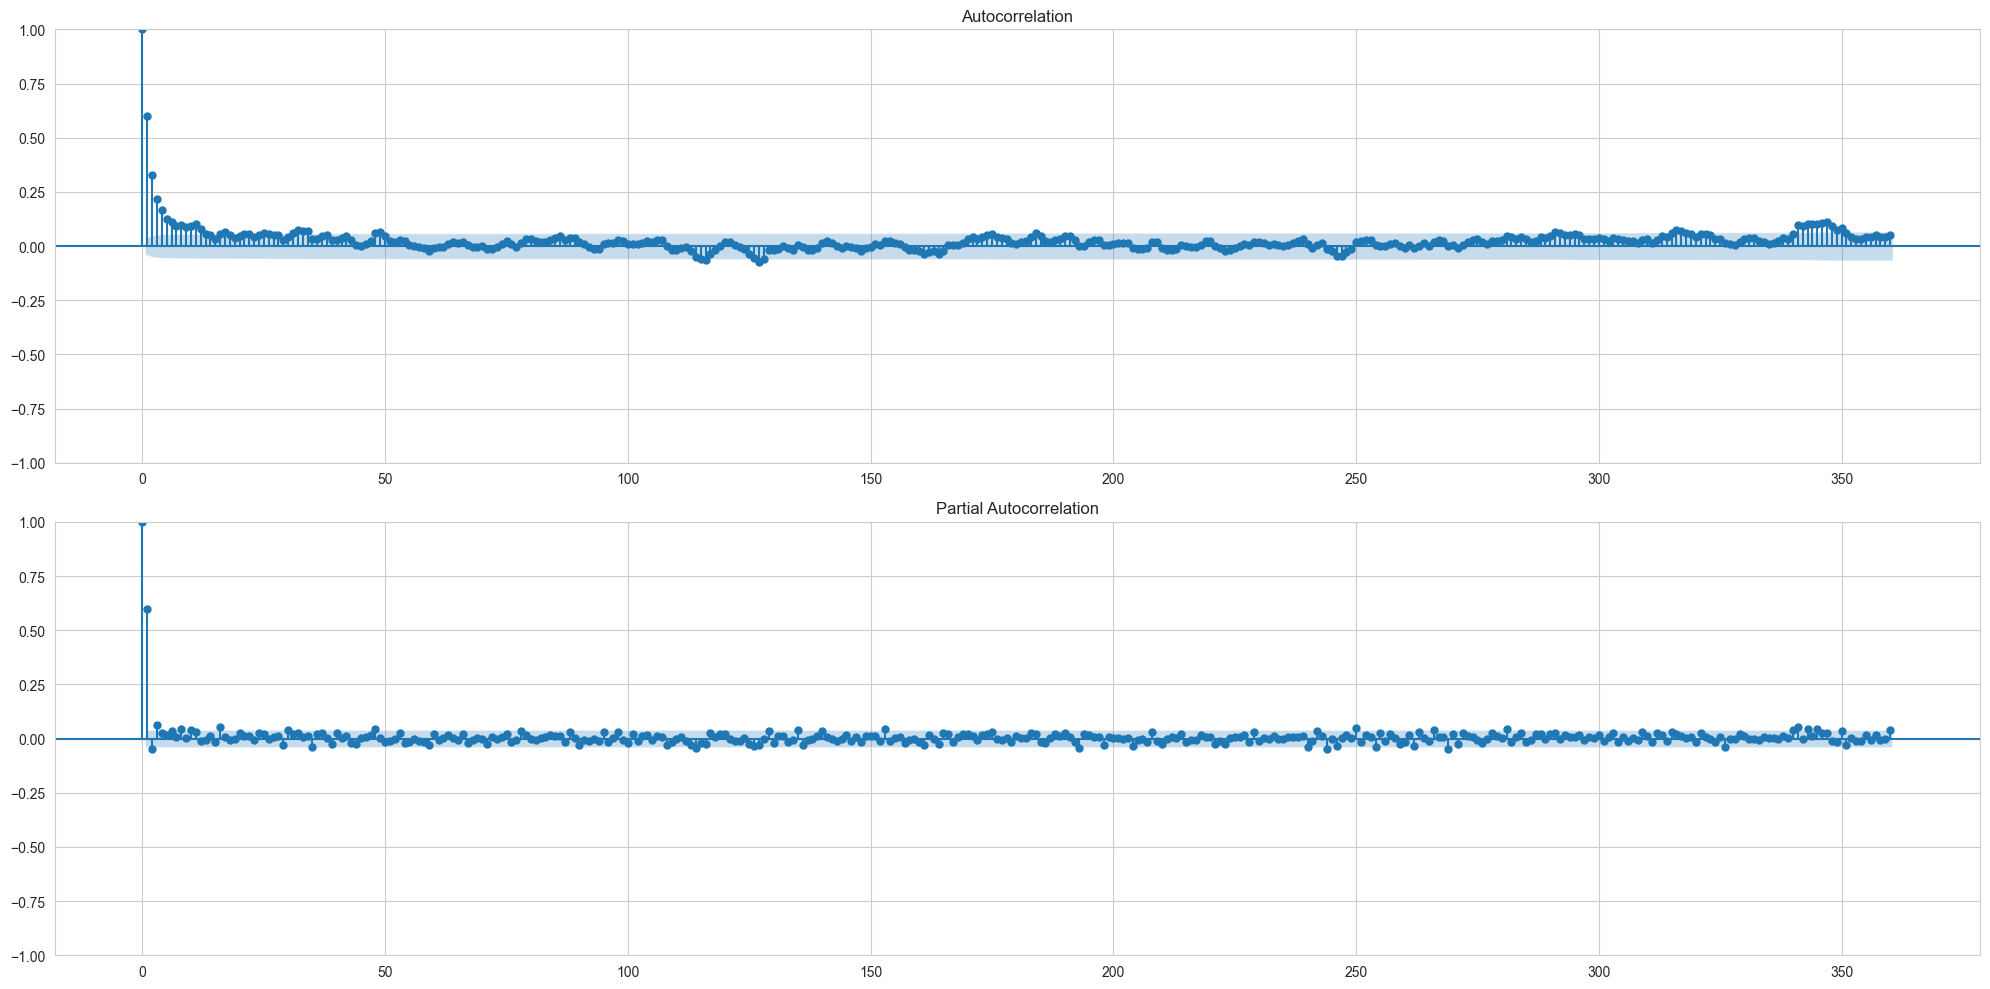

In [950]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(20, 10))
plot_acf(pm2p5_train, lags=360, ax=ax1)
plot_pacf(pm2p5_train, lags=360, ax=ax2)
plt.tight_layout()
plt.show()

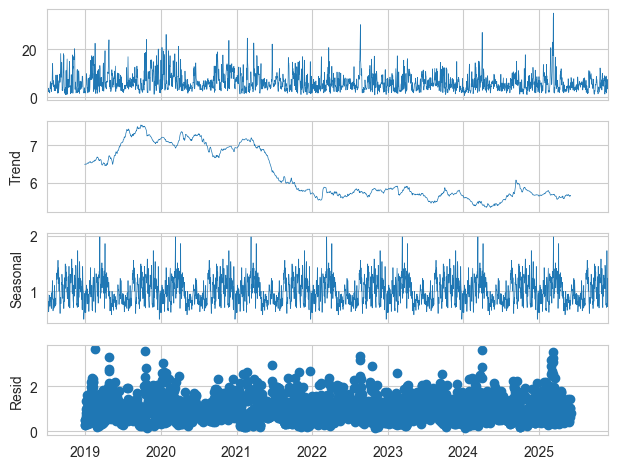

In [955]:
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.pyplot as plt

decomposition = seasonal_decompose(pm2p5_train, model='multiplicative', period=365)

fig = decomposition.plot()

for ax in fig.axes:
    for line in ax.get_lines():
        line.set_linewidth(0.5)

plt.show()

In [956]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(pm2p5_train)
print("ADF Statistic:", result[0])
print("p-value:", result[1])
for key, value in result[4].items():
    print(f'Critical Value ({key}): {value}')

ADF Statistic: -11.800390560700688
p-value: 9.36106001021958e-22
Critical Value (1%): -3.432774269604887
Critical Value (5%): -2.8626110643113347
Critical Value (10%): -2.567340163100137


C:\Users\rugil\AppData\Local\Temp\ipykernel_31892\383545422.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  pm2p5_train['pm2p5_Seasonal_Diff'] = pm2p5_train['pm2p5'] - pm2p5_train['pm2p5'].shift(365)


ADF Statistic after Differencing: -20.9649
p-value after Seasonal Differencing: 0.0


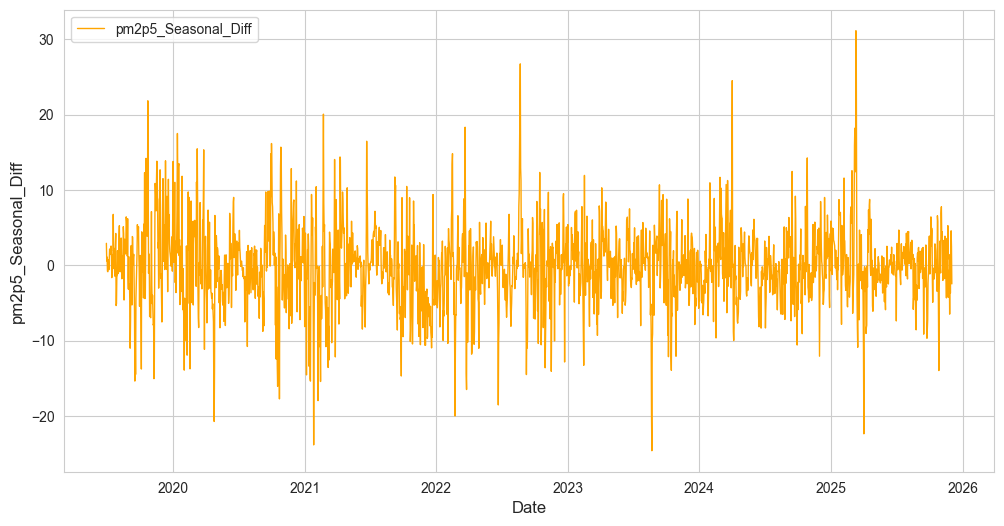

In [959]:
pm2p5_train['pm2p5_Seasonal_Diff'] = pm2p5_train['pm2p5'] - pm2p5_train['pm2p5'].shift(365) 

result_diff_seasonal = adfuller(pm2p5_train['pm2p5_Seasonal_Diff'].dropna())
print("ADF Statistic after Differencing:", result_diff_seasonal[0].round(4))
print("p-value after Seasonal Differencing:", result_diff_seasonal[1])


plt.figure(figsize=(12, 6))
plt.plot(pm2p5_train.index, pm2p5_train['pm2p5_Seasonal_Diff'], label='pm2p5_Seasonal_Diff', linewidth=1, color='orange')
plt.title('', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('pm2p5_Seasonal_Diff', fontsize=12)
plt.grid(True)
plt.legend()
plt.show()

In [960]:
from pmdarima import auto_arima

model = auto_arima(pm2p5_train['pm2p5_Seasonal_Diff'].dropna(), 
                   stepwise=True, 
                   suppress_warnings=True, 
                   error_action="ignore", 
                   trace=True)

print(model.summary())

Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0] intercept   : AIC=13450.717, Time=3.11 sec
 ARIMA(0,0,0)(0,0,0)[0] intercept   : AIC=14390.510, Time=0.15 sec
 ARIMA(1,0,0)(0,0,0)[0] intercept   : AIC=13471.767, Time=0.33 sec
 ARIMA(0,0,1)(0,0,0)[0] intercept   : AIC=13594.087, Time=0.69 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=14389.959, Time=0.10 sec
 ARIMA(1,0,2)(0,0,0)[0] intercept   : AIC=13450.507, Time=1.40 sec
 ARIMA(0,0,2)(0,0,0)[0] intercept   : AIC=13481.603, Time=1.41 sec
 ARIMA(1,0,1)(0,0,0)[0] intercept   : AIC=13450.087, Time=0.91 sec
 ARIMA(2,0,1)(0,0,0)[0] intercept   : AIC=13451.066, Time=1.34 sec
 ARIMA(2,0,0)(0,0,0)[0] intercept   : AIC=13453.050, Time=0.61 sec
 ARIMA(1,0,1)(0,0,0)[0]             : AIC=13448.561, Time=0.32 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=13592.963, Time=0.34 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=13470.163, Time=0.20 sec
 ARIMA(2,0,1)(0,0,0)[0]             : AIC=13449.524, Time=0.48 sec
 ARIMA(1,0,2)(0,0,0

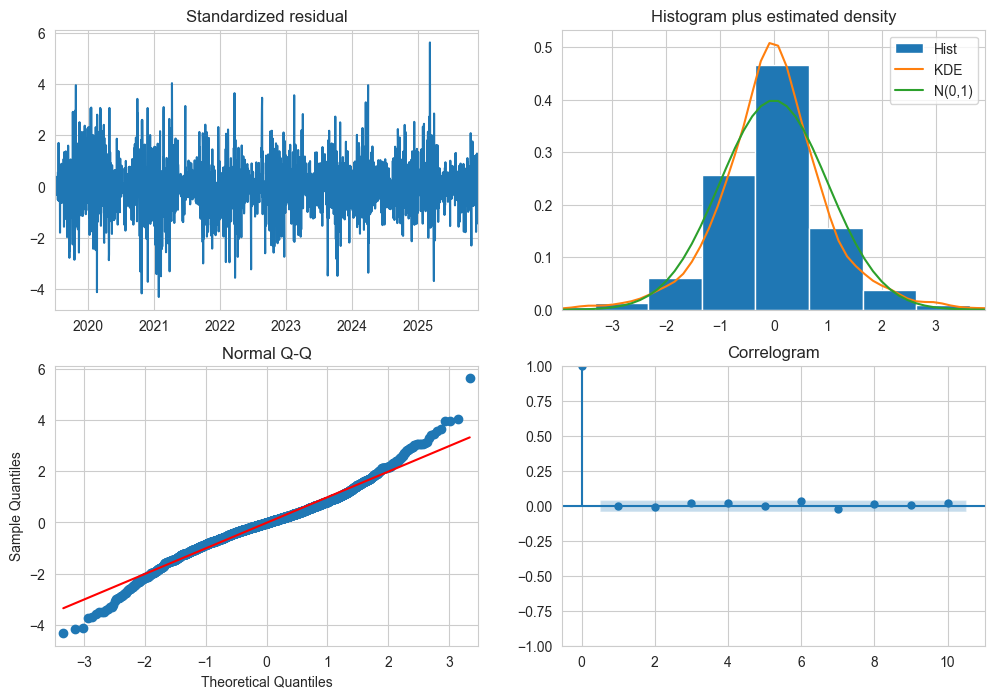

In [961]:
model.plot_diagnostics(figsize=(12, 8))
plt.show()

In [965]:
n = len(pm2p5_test)

# forecastingam diff erdveje
forecast_diff, conf_int = model.predict(n_periods=n, return_conf_int=True)

# atstatom tai ka pasalinom (y_t - y_{t-365}) + y_{t-365} = y_t
# base = pm2p5_train['pm2p5'].shift(365).iloc[-n:].values
base = pm2p5['pm2p5'].iloc[-365 - n : -365].values
forecast_real = forecast_diff + base

forecast_series = pd.Series(forecast_real, index=pm2p5_test.index)
conf_int_real = conf_int + base.reshape(-1, 1)

In [966]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

y_true = pm2p5_test['pm2p5']
y_pred = forecast_series

mse = mean_squared_error(y_true, y_pred)
mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_true, y_pred)

print(f"MSE: {mse:.2f}")
print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²: {r2:.4f}")

MSE: 17.89
MAE: 3.29
RMSE: 4.23
R²: -0.7287


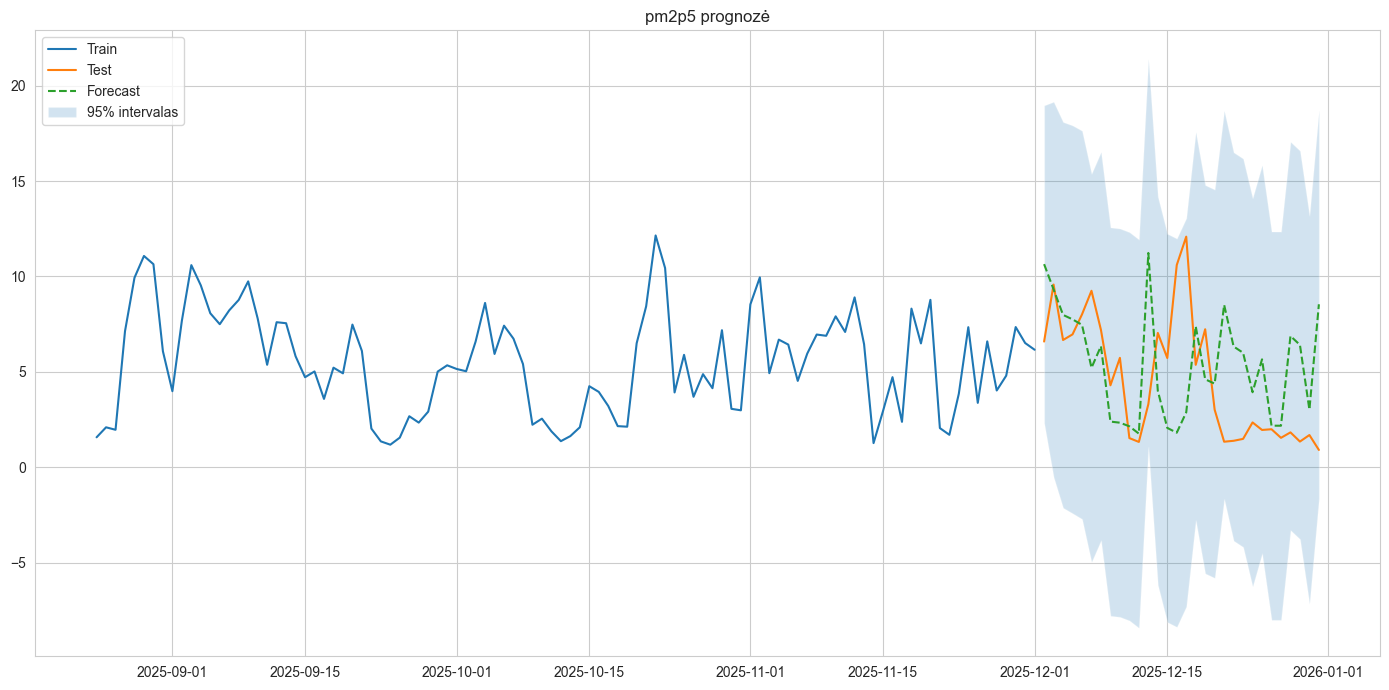

In [967]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 7))

plt.plot(pm2p5_train.tail(100).index, pm2p5_train.tail(100)['pm2p5'], label='Train')
plt.plot(pm2p5_test.index, pm2p5_test['pm2p5'], label='Test')
plt.plot(forecast_series.index, forecast_series, linestyle='--', label='Forecast')

plt.fill_between(pm2p5_test.index,
                 conf_int_real[:, 0],
                 conf_int_real[:, 1],
                 alpha=0.2,
                 label='95% intervalas')

plt.title('pm2p5 prognozė')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## SIA

In [968]:
sia = pd.DataFrame(data_for_forecasting['sia'].dropna())
sia_train = sia.iloc[:-30]
sia_test = sia.iloc[-30:]

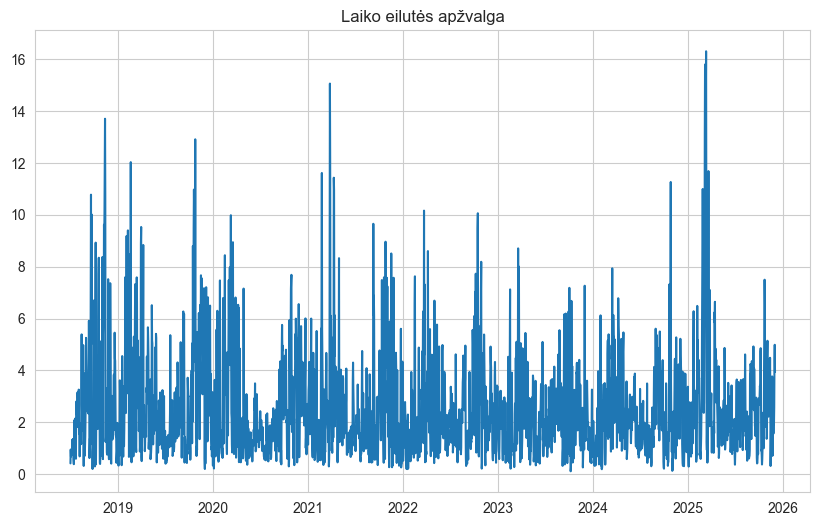

ADF Statistika: -8.994230500653087
p-reikšmė: 6.7624899729989225e-15


In [969]:
from statsmodels.tsa.stattools import adfuller

plt.figure(figsize=(10, 6))
plt.plot(sia_train)
plt.title('Laiko eilutės apžvalga')
plt.show()

# ADF Testas
result = adfuller(sia_train)
print(f'ADF Statistika: {result[0]}')
print(f'p-reikšmė: {result[1]}')

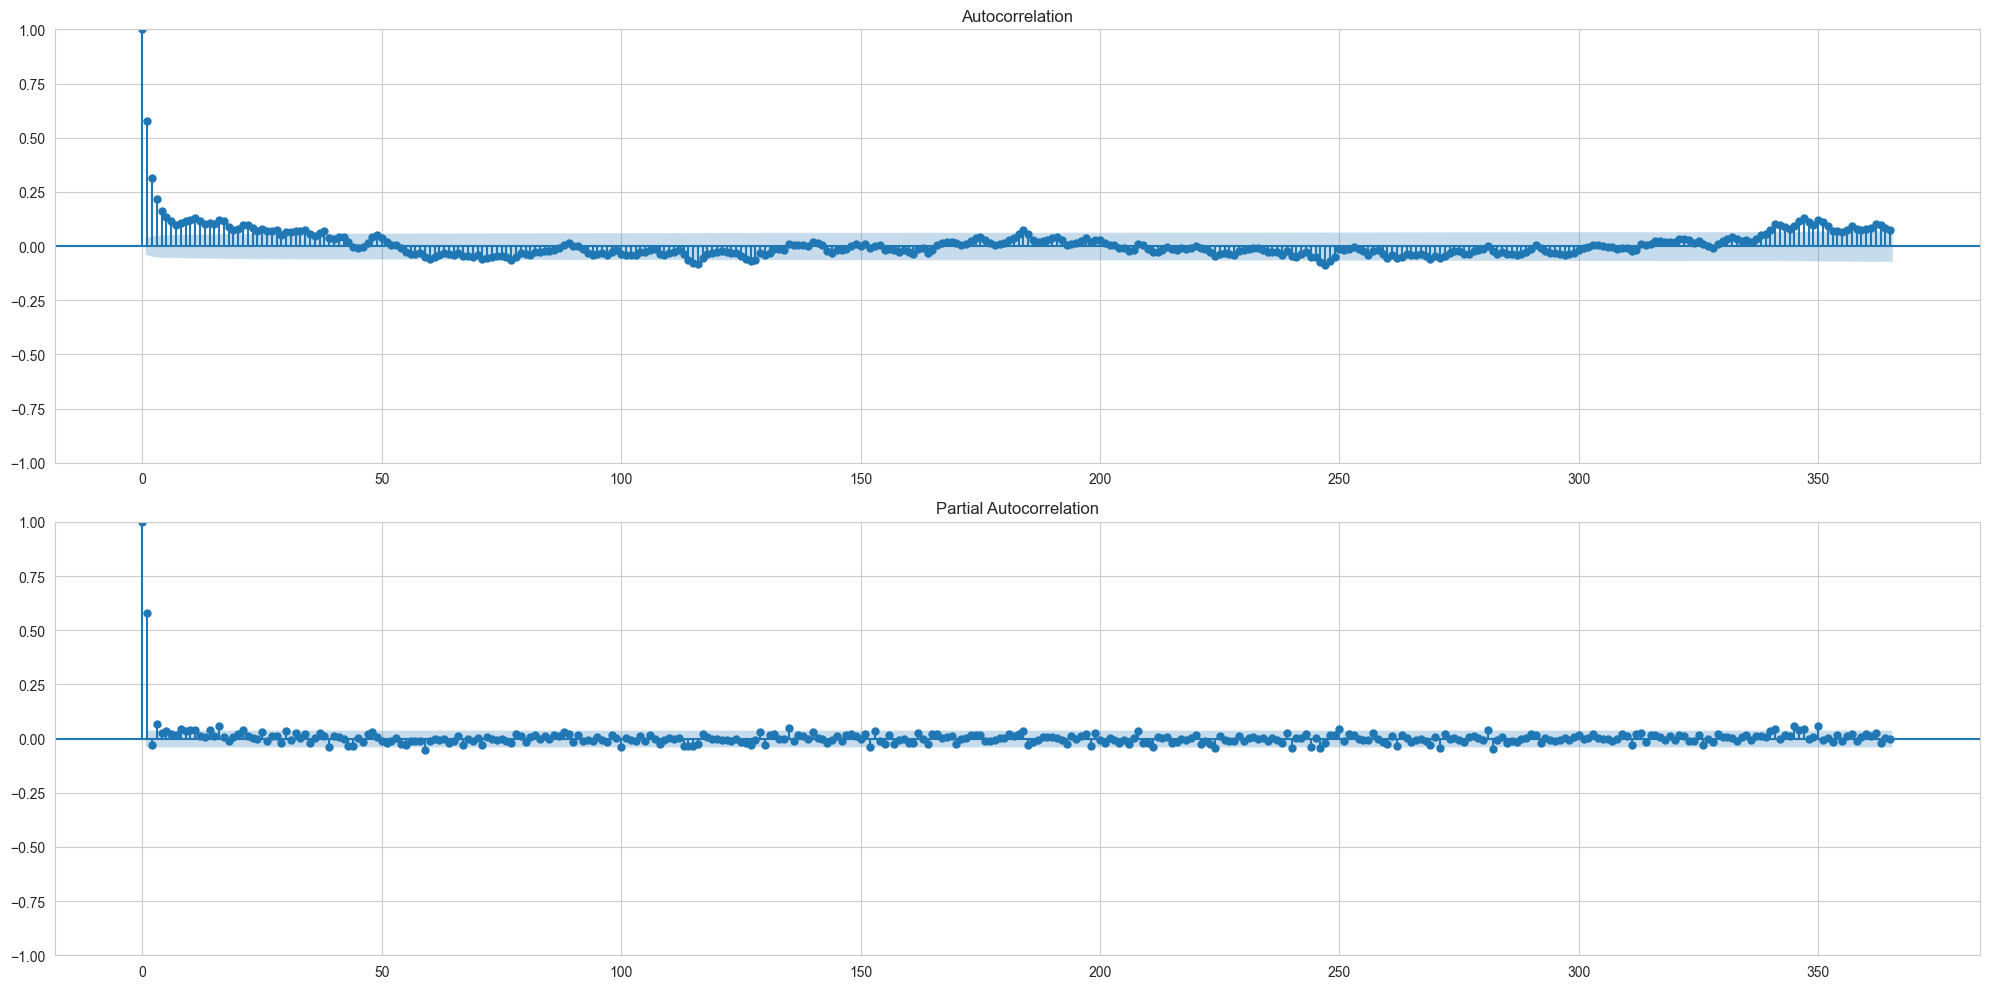

In [970]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(20, 10))
plot_acf(sia_train, lags=365, ax=ax1)
plot_pacf(sia_train, lags=365, ax=ax2)
plt.tight_layout()
plt.show()

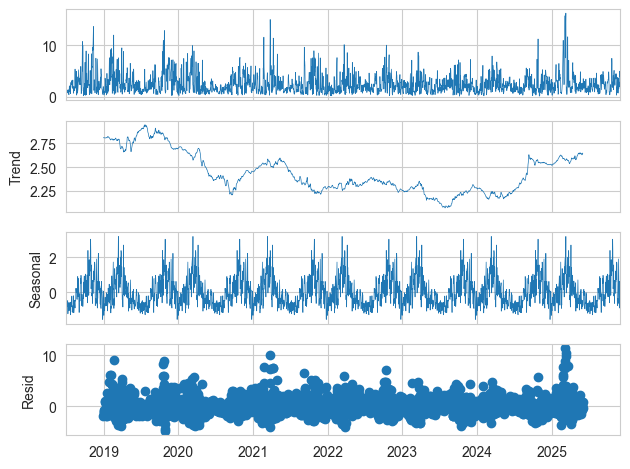

In [971]:
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.pyplot as plt

decomposition = seasonal_decompose(sia_train, model='additive', period=365)

fig = decomposition.plot()

for ax in fig.axes:
    for line in ax.get_lines():
        line.set_linewidth(0.5)

plt.show()

In [972]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(sia_train)
print("ADF Statistic:", result[0])
print("p-value:", result[1])
for key, value in result[4].items():
    print(f'Critical Value ({key}): {value}')

ADF Statistic: -8.994230500653087
p-value: 6.7624899729989225e-15
Critical Value (1%): -3.432778771617089
Critical Value (5%): -2.862613052530749
Critical Value (10%): -2.5673412216328595


C:\Users\rugil\AppData\Local\Temp\ipykernel_31892\2150229463.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sia_train['sia_Seasonal_Diff'] = sia_train['sia'] - sia_train['sia'].shift(365)


ADF Statistic after Differencing: -26.0312
p-value after Seasonal Differencing: 0.0


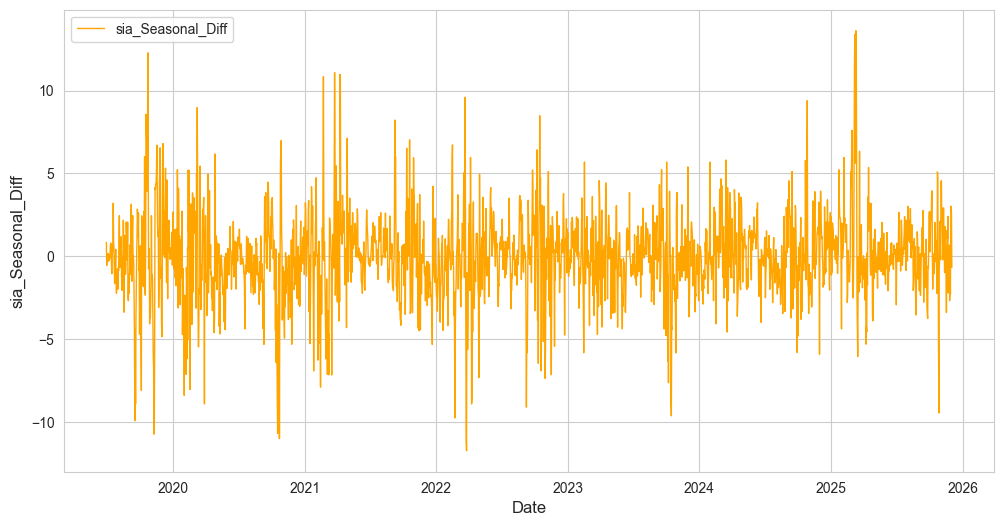

In [974]:
sia_train['sia_Seasonal_Diff'] = sia_train['sia'] - sia_train['sia'].shift(365) 

result_diff_seasonal = adfuller(sia_train['sia_Seasonal_Diff'].dropna())
print("ADF Statistic after Differencing:", result_diff_seasonal[0].round(4))
print("p-value after Seasonal Differencing:", result_diff_seasonal[1])


plt.figure(figsize=(12, 6))
plt.plot(sia_train.index, sia_train['sia_Seasonal_Diff'], label='sia_Seasonal_Diff', linewidth=1, color='orange')
plt.title('', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('sia_Seasonal_Diff', fontsize=12)
plt.grid(True)
plt.legend()
plt.show()

In [975]:
from pmdarima import auto_arima

model = auto_arima(sia_train['sia_Seasonal_Diff'].dropna(), 
                   stepwise=True, 
                   suppress_warnings=True, 
                   error_action="ignore", 
                   trace=True)

print(model.summary())

Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0] intercept   : AIC=10260.700, Time=1.20 sec
 ARIMA(0,0,0)(0,0,0)[0] intercept   : AIC=11020.527, Time=0.16 sec
 ARIMA(1,0,0)(0,0,0)[0] intercept   : AIC=10278.027, Time=0.40 sec
 ARIMA(0,0,1)(0,0,0)[0] intercept   : AIC=10345.983, Time=0.50 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=11018.759, Time=0.08 sec
 ARIMA(1,0,2)(0,0,0)[0] intercept   : AIC=10258.700, Time=0.84 sec
 ARIMA(0,0,2)(0,0,0)[0] intercept   : AIC=10272.253, Time=0.71 sec
 ARIMA(1,0,1)(0,0,0)[0] intercept   : AIC=10256.978, Time=0.55 sec
 ARIMA(2,0,1)(0,0,0)[0] intercept   : AIC=10258.711, Time=0.98 sec
 ARIMA(2,0,0)(0,0,0)[0] intercept   : AIC=10258.729, Time=0.52 sec
 ARIMA(1,0,1)(0,0,0)[0]             : AIC=10255.064, Time=0.28 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=10344.123, Time=0.23 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=10276.099, Time=0.15 sec
 ARIMA(2,0,1)(0,0,0)[0]             : AIC=10256.795, Time=0.49 sec
 ARIMA(1,0,2)(0,0,0

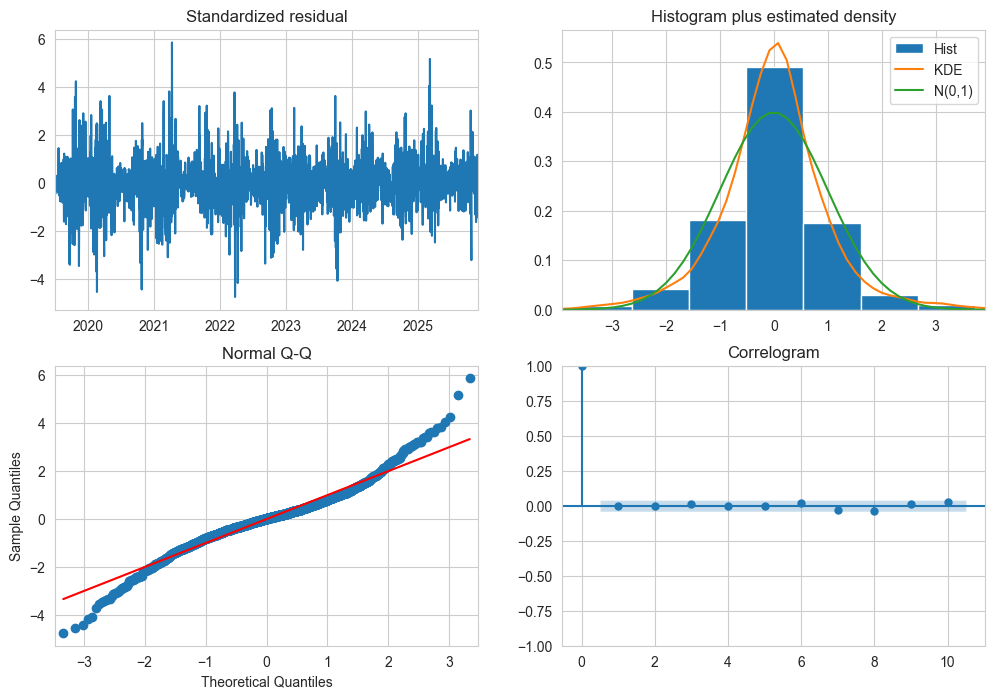

In [976]:
model.plot_diagnostics(figsize=(12, 8))
plt.show()

In [977]:
n = len(sia_test)

# forecastingam diff erdveje
forecast_diff, conf_int = model.predict(n_periods=n, return_conf_int=True)

# atstatom tai ka pasalinom (y_t - y_{t-365}) + y_{t-365} = y_t
# base = pans_train['pans'].shift(365).iloc[-n:].values
base = sia['sia'].iloc[-365 - n : -365].values
forecast_real = forecast_diff + base

forecast_series = pd.Series(forecast_real, index=sia_test.index)
conf_int_real = conf_int + base.reshape(-1, 1)

In [978]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

y_true = sia_test['sia']
y_pred = forecast_series

mse = mean_squared_error(y_true, y_pred)
mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_true, y_pred)

print(f"MSE: {mse:.2f}")
print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²: {r2:.4f}")

MSE: 3.69
MAE: 1.47
RMSE: 1.92
R²: -0.2776


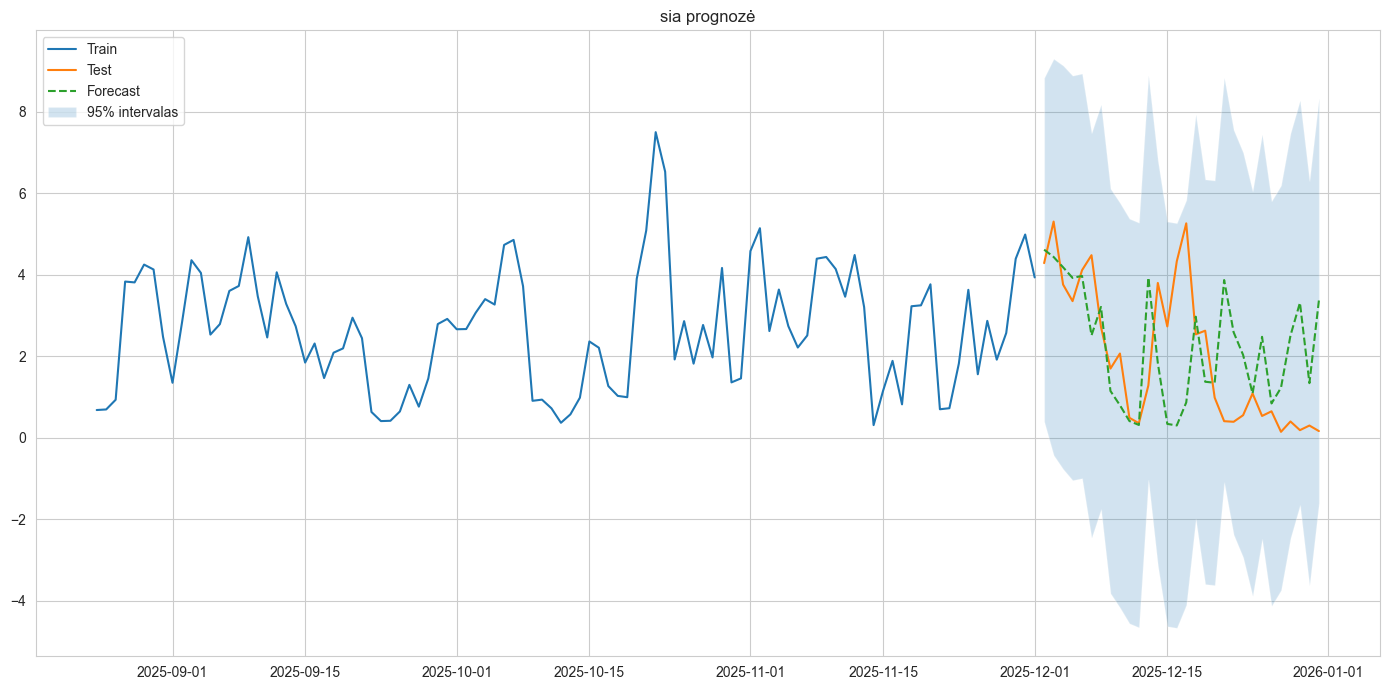

In [979]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 7))

plt.plot(sia_train.tail(100).index, sia_train.tail(100)['sia'], label='Train')
plt.plot(sia_test.index, sia_test['sia'], label='Test')
plt.plot(forecast_series.index, forecast_series, linestyle='--', label='Forecast')

plt.fill_between(sia_test.index,
                 conf_int_real[:, 0],
                 conf_int_real[:, 1],
                 alpha=0.2,
                 label='95% intervalas')

plt.title('sia prognozė')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## DUST

In [980]:
dust = pd.DataFrame(data_for_forecasting['dust'].dropna())
dust_train = dust.iloc[:-30]
dust_test = dust.iloc[-30:]

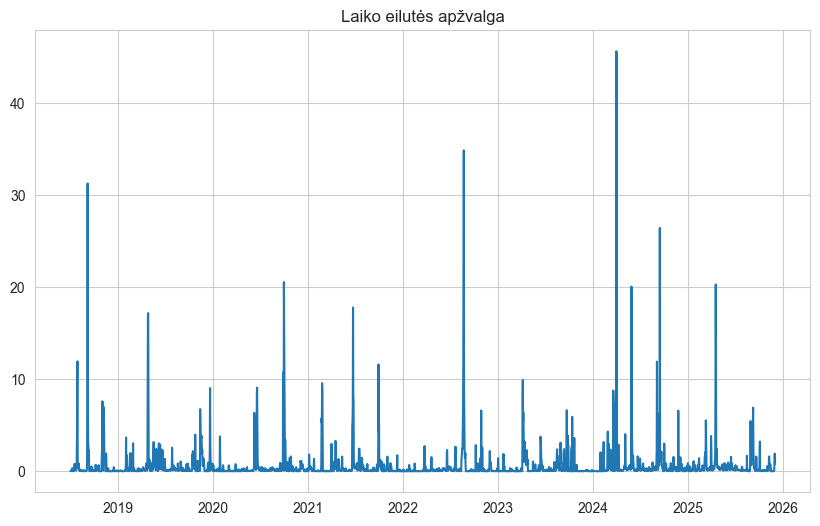

ADF Statistika: -22.005660217540342
p-reikšmė: 0.0


In [981]:
from statsmodels.tsa.stattools import adfuller

plt.figure(figsize=(10, 6))
plt.plot(dust_train)
plt.title('Laiko eilutės apžvalga')
plt.show()

# ADF Testas
result = adfuller(dust_train)
print(f'ADF Statistika: {result[0]}')
print(f'p-reikšmė: {result[1]}')

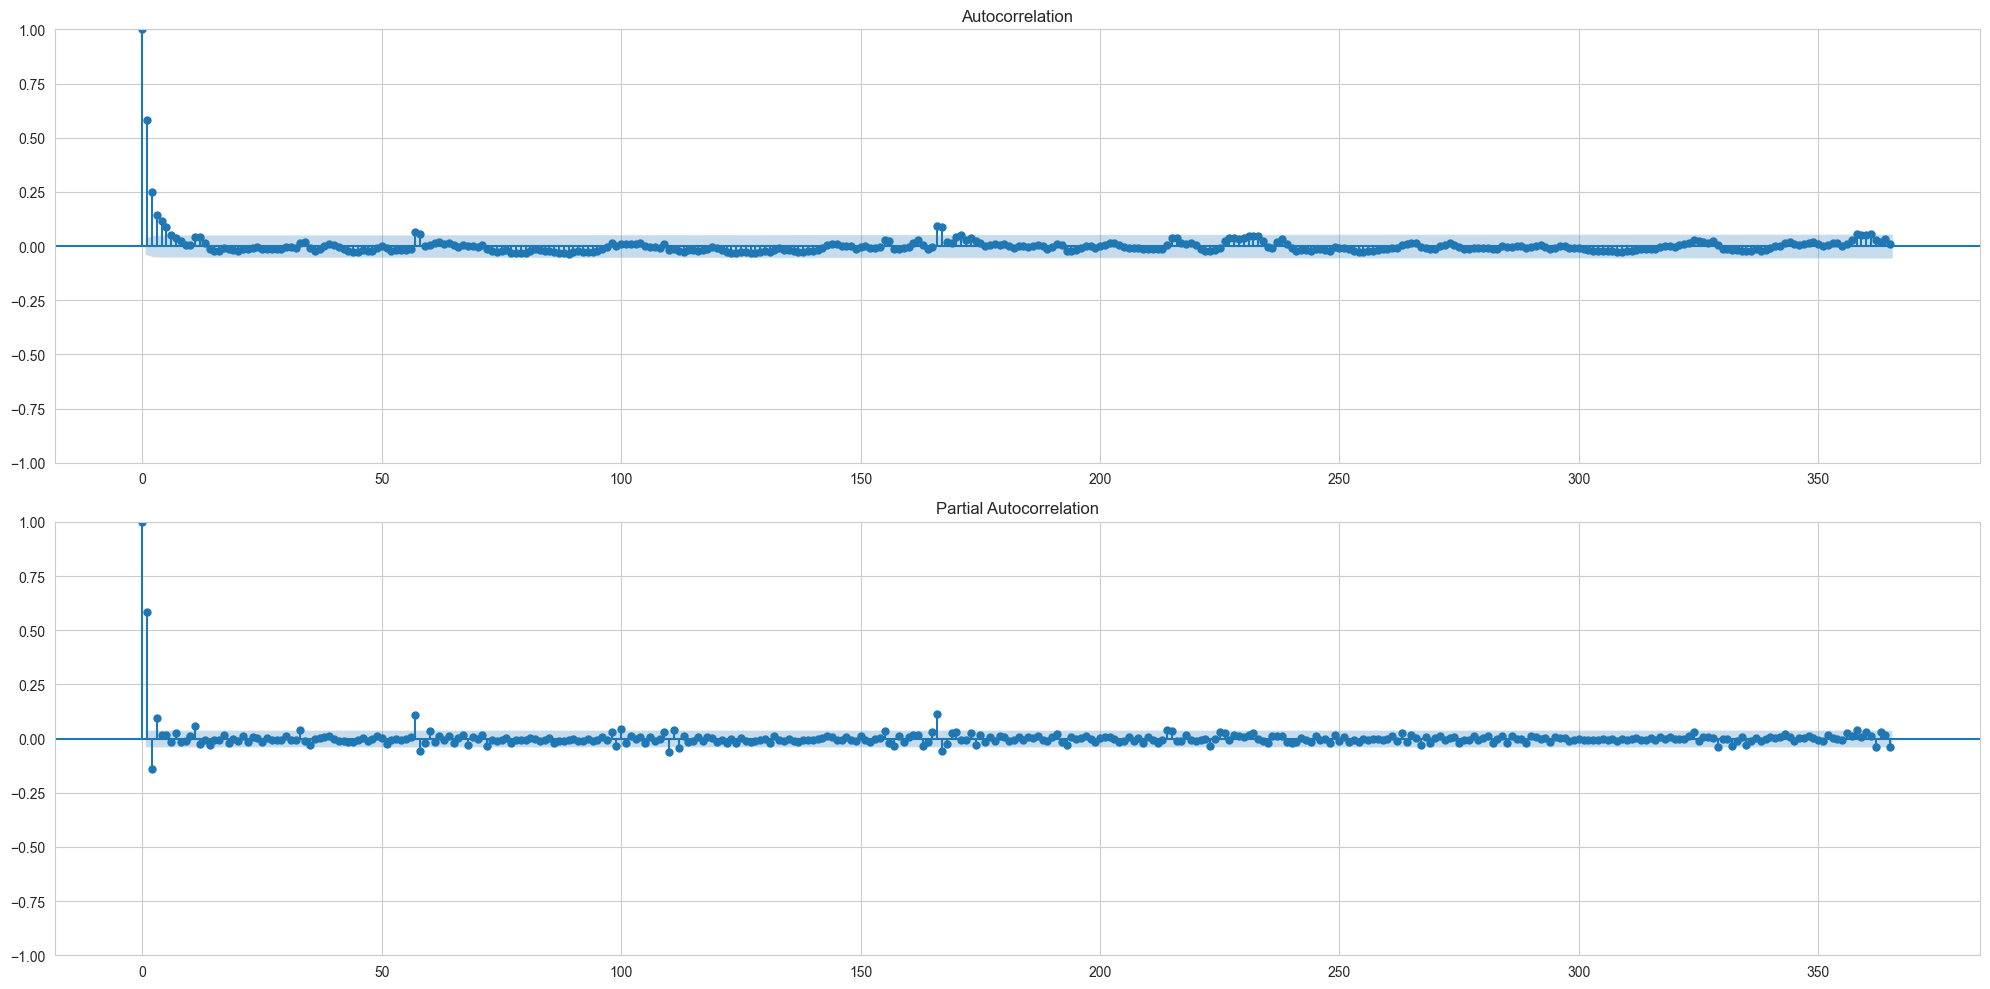

In [982]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(20, 10))
plot_acf(dust_train, lags=365, ax=ax1)
plot_pacf(dust_train, lags=365, ax=ax2)
plt.tight_layout()
plt.show()

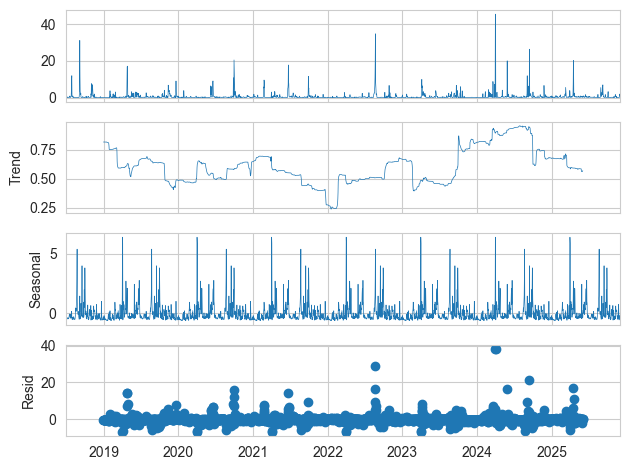

In [986]:
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.pyplot as plt

decomposition = seasonal_decompose(dust_train, model='additive', period=365)

fig = decomposition.plot()

for ax in fig.axes:
    for line in ax.get_lines():
        line.set_linewidth(0.5)

plt.show()

In [987]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(dust_train)
print("ADF Statistic:", result[0])
print("p-value:", result[1])
for key, value in result[4].items():
    print(f'Critical Value ({key}): {value}')

ADF Statistic: -22.005660217540342
p-value: 0.0
Critical Value (1%): -3.4327671009979617
Critical Value (5%): -2.8626078984400154
Critical Value (10%): -2.567338477583788


C:\Users\rugil\AppData\Local\Temp\ipykernel_31892\4080210242.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dust_train['dust_Seasonal_Diff'] = dust_train['dust'] - dust_train['dust'].shift(365)


ADF Statistic after Differencing: -21.1216
p-value after Seasonal Differencing: 0.0


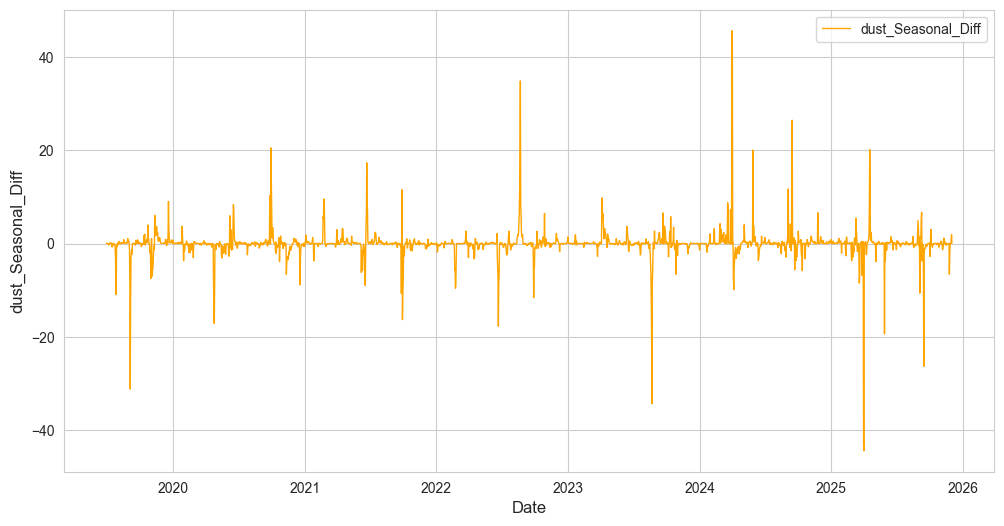

In [989]:
dust_train['dust_Seasonal_Diff'] = dust_train['dust'] - dust_train['dust'].shift(365) 

result_diff_seasonal = adfuller(dust_train['dust_Seasonal_Diff'].dropna())
print("ADF Statistic after Differencing:", result_diff_seasonal[0].round(4))
print("p-value after Seasonal Differencing:", result_diff_seasonal[1])


plt.figure(figsize=(12, 6))
plt.plot(dust_train.index, dust_train['dust_Seasonal_Diff'], label='dust_Seasonal_Diff', linewidth=1, color='orange')
plt.title('', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('dust_Seasonal_Diff', fontsize=12)
plt.grid(True)
plt.legend()
plt.show()

In [990]:
from pmdarima import auto_arima

model = auto_arima(dust_train['dust_Seasonal_Diff'].dropna(), 
                   stepwise=True, 
                   suppress_warnings=True, 
                   error_action="ignore", 
                   trace=True)

print(model.summary())

Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0] intercept   : AIC=11190.109, Time=4.69 sec
 ARIMA(0,0,0)(0,0,0)[0] intercept   : AIC=12106.285, Time=0.11 sec
 ARIMA(1,0,0)(0,0,0)[0] intercept   : AIC=11230.245, Time=0.21 sec
 ARIMA(0,0,1)(0,0,0)[0] intercept   : AIC=11291.632, Time=0.46 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=12104.629, Time=0.07 sec
 ARIMA(1,0,2)(0,0,0)[0] intercept   : AIC=11188.789, Time=0.75 sec
 ARIMA(0,0,2)(0,0,0)[0] intercept   : AIC=11216.448, Time=0.64 sec
 ARIMA(1,0,1)(0,0,0)[0] intercept   : AIC=11191.094, Time=0.63 sec
 ARIMA(1,0,3)(0,0,0)[0] intercept   : AIC=11190.774, Time=1.33 sec
 ARIMA(0,0,3)(0,0,0)[0] intercept   : AIC=11194.540, Time=1.03 sec
 ARIMA(2,0,1)(0,0,0)[0] intercept   : AIC=11188.616, Time=1.07 sec
 ARIMA(2,0,0)(0,0,0)[0] intercept   : AIC=11199.078, Time=0.52 sec
 ARIMA(3,0,1)(0,0,0)[0] intercept   : AIC=11190.571, Time=1.76 sec
 ARIMA(3,0,0)(0,0,0)[0] intercept   : AIC=11190.140, Time=0.61 sec
 ARIMA(3,0,2)(0,0,0

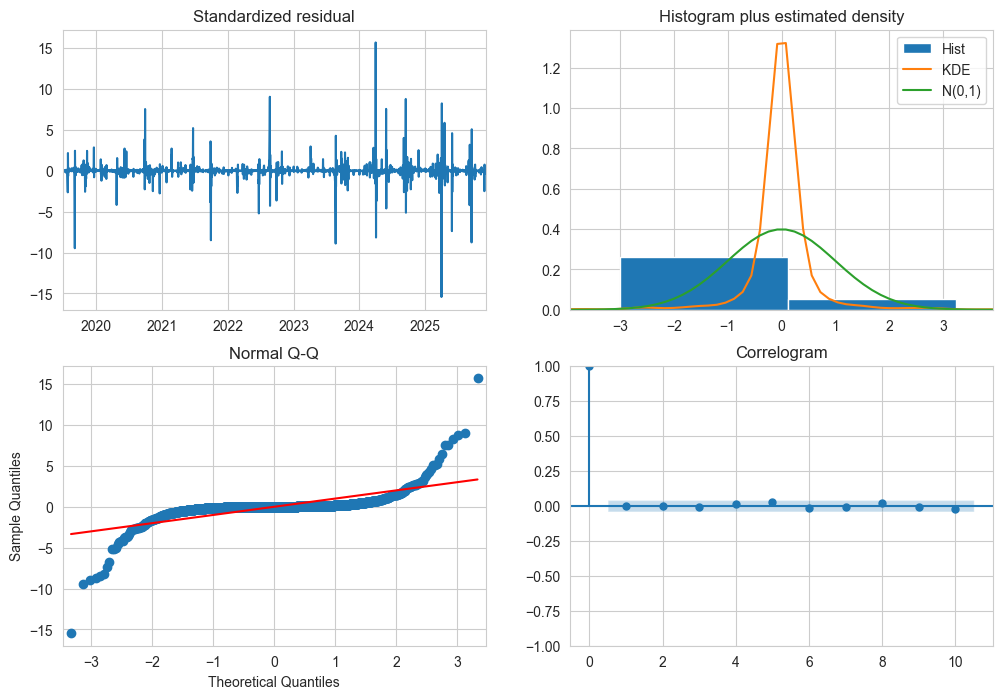

In [991]:
model.plot_diagnostics(figsize=(12, 8))
plt.show()

In [992]:
n = len(dust_test)

# forecastingam diff erdveje
forecast_diff, conf_int = model.predict(n_periods=n, return_conf_int=True)

# atstatom tai ka pasalinom (y_t - y_{t-365}) + y_{t-365} = y_t
# base = pans_train['pans'].shift(365).iloc[-n:].values
base = dust['dust'].iloc[-365 - n : -365].values
forecast_real = forecast_diff + base

forecast_series = pd.Series(forecast_real, index=dust_test.index)
conf_int_real = conf_int + base.reshape(-1, 1)

In [993]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

y_true = dust_test['dust']
y_pred = forecast_series

mse = mean_squared_error(y_true, y_pred)
mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_true, y_pred)

print(f"MSE: {mse:.2f}")
print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²: {r2:.4f}")

MSE: 0.79
MAE: 0.55
RMSE: 0.89
R²: -0.0721


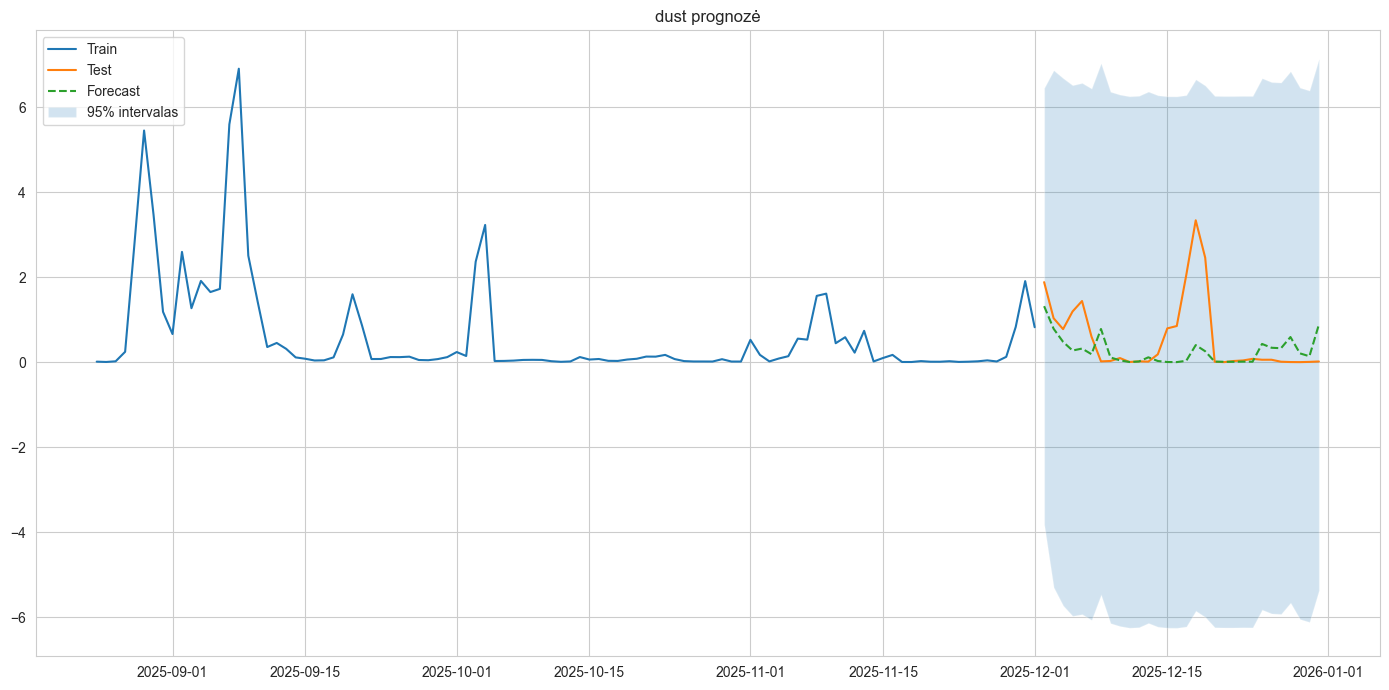

In [994]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 7))

plt.plot(dust_train.tail(100).index, dust_train.tail(100)['dust'], label='Train')
plt.plot(dust_test.index, dust_test['dust'], label='Test')
plt.plot(forecast_series.index, forecast_series, linestyle='--', label='Forecast')

plt.fill_between(dust_test.index,
                 conf_int_real[:, 0],
                 conf_int_real[:, 1],
                 alpha=0.2,
                 label='95% intervalas')

plt.title('dust prognozė')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Galutinis apjungimas

In [142]:
final_filled_data = filled_data[[
    'airTemperature',
    'seaLevelPressure',
    'relativeHumidity',
    'xgb_precipitation',
    'xgb_cloudCover',
    'feelsLikeTemperature_fixed',
    'windSpeed_fixed',
    'windGust_fixed',
    'windDirection_fixed',
    'absorbing_aerosol_index', 
    'NO2_column_number_density', 
    'stratospheric_NO2_column_number_density',
    'NO2_slant_column_number_density',
    'tropopause_pressure',
    'H2O_column_number_density',
    'BrO',
    'BrO_Error',
    'NO2',
    'NO2_Error',
    'O3',
    'O3_Error'
    ]]

In [143]:
data_for_forecasting = final_filled_data.join(data_to_forecast)
data_for_forecasting

,airTemperature,seaLevelPressure,relativeHumidity,xgb_precipitation,xgb_cloudCover,feelsLikeTemperature_fixed,windSpeed_fixed,windGust_fixed,windDirection_fixed,absorbing_aerosol_index,...,NO2_Error,O3,O3_Error,dust,sia,pm2p5,pans,nmvoc,nh3,pm10
observationTime,,,,,,,,,,,,,,,,,,,,,
2018-07-01,11.295833,1010.637500,72.791667,9.100000e+00,89.375000,10.933333,3.762500,13.9,356.0,-0.780346,...,2.984735e+14,332.670633,0.823016,0.011452,0.412340,1.127883,1.174715,2.292138,0.105974,1.338105
2018-07-02,10.866667,1006.662500,94.000000,1.190000e+01,91.500000,10.429167,2.516667,7.0,327.0,-0.807210,...,2.865718e+14,339.679410,0.756530,0.011515,0.946260,1.609913,1.935448,3.792921,0.198428,1.752331
2018-07-03,13.387500,1008.454167,90.041667,1.000000e+01,89.375000,13.387500,2.537500,8.3,271.0,-0.621235,...,3.356409e+14,361.533268,1.624589,0.044194,0.676988,1.534471,1.787800,2.332084,0.118859,1.789138
2018-07-04,13.591667,1009.237500,88.291667,1.390000e+01,88.333333,13.591667,2.358333,8.7,288.0,-0.659180,...,3.289718e+14,343.308865,0.759276,0.128728,0.833161,3.229130,1.201320,2.113538,0.361157,4.323638
2018-07-05,16.291667,1008.079167,70.208333,2.220446e-16,66.000000,16.291667,1.283333,6.1,293.0,-1.010234,...,3.421961e+14,311.500626,0.892097,0.097650,0.737482,2.768797,1.206750,2.267631,0.316533,3.718909
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-01-27,-2.200000,1005.416667,95.625000,3.800000e+00,100.000000,-4.162500,1.600000,4.6,70.0,-0.386410,...,1.689397e+14,395.745543,1.899760,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-01-28,-5.012500,1002.875000,91.916667,6.000000e+00,100.000000,-8.941667,2.495833,7.5,33.0,-0.301222,...,1.969204e+14,450.404488,1.528003,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-01-29,-9.604167,1009.787500,87.000000,2.220446e-16,81.291667,-14.795833,2.812500,8.3,35.0,-0.406181,...,2.968148e+14,353.699717,1.822900,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [144]:
ecmwf_data = pd.read_csv("Vilnius_ecmwf_data_2017_2026.csv")
ecmwf_data.head()
ecmwf_data = ecmwf_data.drop_duplicates(subset=['time'], keep='first')

ecmwf_data['time'] = pd.to_datetime(ecmwf_data['time'])
ecmwf_data.set_index('time', inplace=True)

In [145]:
final_data = data_for_forecasting.merge(
    ecmwf_data, 
    left_index=True, 
    right_on='time', 
    how='left'
)
final_data

,airTemperature,seaLevelPressure,relativeHumidity,xgb_precipitation,xgb_cloudCover,feelsLikeTemperature_fixed,windSpeed_fixed,windGust_fixed,windDirection_fixed,absorbing_aerosol_index,...,O3_Error,dust,sia,pm2p5,pans,nmvoc,nh3,pm10,tp,t2m
time,,,,,,,,,,,,,,,,,,,,,
2018-07-01,11.295833,1010.637500,72.791667,9.100000e+00,89.375000,10.933333,3.762500,13.9,356.0,-0.780346,...,0.823016,0.011452,0.412340,1.127883,1.174715,2.292138,0.105974,1.338105,14.653358,12.970276
2018-07-02,10.866667,1006.662500,94.000000,1.190000e+01,91.500000,10.429167,2.516667,7.0,327.0,-0.807210,...,0.756530,0.011515,0.946260,1.609913,1.935448,3.792921,0.198428,1.752331,6.475957,14.779846
2018-07-03,13.387500,1008.454167,90.041667,1.000000e+01,89.375000,13.387500,2.537500,8.3,271.0,-0.621235,...,1.624589,0.044194,0.676988,1.534471,1.787800,2.332084,0.118859,1.789138,9.607317,15.965973
2018-07-04,13.591667,1009.237500,88.291667,1.390000e+01,88.333333,13.591667,2.358333,8.7,288.0,-0.659180,...,0.759276,0.128728,0.833161,3.229130,1.201320,2.113538,0.361157,4.323638,0.013308,18.015717
2018-07-05,16.291667,1008.079167,70.208333,2.220446e-16,66.000000,16.291667,1.283333,6.1,293.0,-1.010234,...,0.892097,0.097650,0.737482,2.768797,1.206750,2.267631,0.316533,3.718909,-0.000741,19.040314
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-01-27,-2.200000,1005.416667,95.625000,3.800000e+00,100.000000,-4.162500,1.600000,4.6,70.0,-0.386410,...,1.899760,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.703954,-1.980194
2026-01-28,-5.012500,1002.875000,91.916667,6.000000e+00,100.000000,-8.941667,2.495833,7.5,33.0,-0.301222,...,1.528003,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.669112,-8.068604
2026-01-29,-9.604167,1009.787500,87.000000,2.220446e-16,81.291667,-14.795833,2.812500,8.3,35.0,-0.406181,...,1.822900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.035326,-14.267487


In [233]:
final_data.min()

airTemperature                            -2.022500e+01
seaLevelPressure                           9.733250e+02
relativeHumidity                           2.958333e+01
xgb_precipitation                          2.220446e-16
xgb_cloudCover                             0.000000e+00
feelsLikeTemperature_fixed                -2.374583e+01
windSpeed_fixed                            2.125000e-01
windGust_fixed                             2.400000e+00
windDirection_fixed                        0.000000e+00
absorbing_aerosol_index                   -2.990588e+00
NO2_column_number_density                 -3.985064e-05
stratospheric_NO2_column_number_density    7.723584e-06
NO2_slant_column_number_density            6.039153e-05
tropopause_pressure                        9.582507e+03
H2O_column_number_density                 -2.218127e+01
BrO                                       -1.447654e+13
BrO_Error                                  9.870329e+12
NO2                                        1.867

In [898]:
(final_data < 0).sum()

airTemperature                              496
seaLevelPressure                              0
relativeHumidity                              0
xgb_precipitation                             0
xgb_cloudCover                                0
feelsLikeTemperature_fixed                  868
windSpeed_fixed                               0
windGust_fixed                                0
windDirection_fixed                           0
absorbing_aerosol_index                    2493
NO2_column_number_density                    10
stratospheric_NO2_column_number_density       0
NO2_slant_column_number_density               0
tropopause_pressure                           0
H2O_column_number_density                     1
BrO                                           2
BrO_Error                                     0
NO2                                           0
NO2_Error                                     0
O3                                            0
O3_Error                                

In [146]:
final_data.to_csv('dm_project_dataset_alpha.csv', index=True, sep=',', encoding='utf-8')